# Mistral 7B vLLM Performance Analysis
This notebook analyzes and compares performance metrics across different Gaudi configurations:
- **Configurations**: gaudi2, gaudi2m, gaudi2s, gaudi3, gaudi3m, gaudi3s
- **Metrics**: Throughput, TTFT (Time to First Token), ITL (Inter-Token Latency), Power Consumption
- **Workloads**: Standard benchmark, Alpaca benchmark (8 & 16 multiproc)

In [241]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [242]:
# Define base path
base_path = Path('mistral_logs')

# Configuration names mapping
config_names = {
    'g2': 'Gaudi2',
    'g2m': 'Gaudi2M',
    'g2s': 'Gaudi2S',
    'g3': 'Gaudi3',
    'g3m': 'Gaudi3M',
    'g3s': 'Gaudi3S',
    '2m': 'Gaudi2M'
}

# Color palette for configurations
config_colors = {
    'Gaudi2': '#1f77b4',
    'Gaudi2M': '#ff7f0e',
    'Gaudi2S': '#2ca02c',
    'Gaudi3': '#d62728',
    'Gaudi3M': '#9467bd',
    'Gaudi3S': '#8c564b'
}

## 1. Load Benchmark Data

In [243]:
def load_benchmark_data(folder_name, file_pattern='benchmark_results_*.csv'):
    """Load all benchmark CSV files from a folder"""
    data_dict = {}
    folder_path = base_path / folder_name
    
    if not folder_path.exists():
        print(f"Warning: {folder_path} does not exist")
        return data_dict
    
    for file in folder_path.glob(file_pattern):
        # Extract config name from filename
        config_key = file.stem.split('_')[-1]
        config_name = config_names.get(config_key, config_key)
        
        df = pd.read_csv(file)
        df['config'] = config_name
        data_dict[config_name] = df
        print(f"Loaded {len(df)} rows from {file.name}")
    
    return data_dict

In [244]:
# Load standard benchmark results
print("Loading standard benchmark results...")
benchmark_data = load_benchmark_data('mistral_benchmark_results')

# Load Alpaca benchmark results (8 proc)
print("\nLoading Alpaca benchmark results (8 proc)...")
alpaca_8_data = load_benchmark_data('mistral_alpaca_benchmark_8', 'alpaca_benchmark_results_*.csv')

# Load Alpaca benchmark results (16 proc)
print("\nLoading Alpaca benchmark results (16 proc)...")
alpaca_16_data = load_benchmark_data('mistral_alpaca_benchmark_16', 'alpaca_benchmark_results_*.csv')

Loading standard benchmark results...
Loaded 200 rows from benchmark_results_2m.csv
Loaded 200 rows from benchmark_results_g2.csv
Loaded 200 rows from benchmark_results_g2s.csv
Loaded 200 rows from benchmark_results_g3.csv
Loaded 200 rows from benchmark_results_g3m.csv
Loaded 200 rows from benchmark_results_g3s.csv

Loading Alpaca benchmark results (8 proc)...
Loaded 520 rows from alpaca_benchmark_results_g2.csv
Loaded 520 rows from alpaca_benchmark_results_g2m_8.csv
Loaded 520 rows from alpaca_benchmark_results_g2s.csv
Loaded 520 rows from alpaca_benchmark_results_g3.csv
Loaded 520 rows from alpaca_benchmark_results_g3m.csv
Loaded 520 rows from alpaca_benchmark_results_g3s.csv

Loading Alpaca benchmark results (16 proc)...
Loaded 520 rows from alpaca_benchmark_results_g2.csv
Loaded 520 rows from alpaca_benchmark_results_g2s.csv
Loaded 520 rows from alpaca_benchmark_results_g3.csv
Loaded 520 rows from alpaca_benchmark_results_g3m.csv
Loaded 520 rows from alpaca_benchmark_results_g3s.cs

In [245]:
# Combine all benchmark data
if benchmark_data:
    benchmark_df = pd.concat(benchmark_data.values(), ignore_index=True)
    print(f"\nCombined benchmark data: {len(benchmark_df)} rows, {len(benchmark_data)} configurations")
    print(benchmark_df.head())

if alpaca_8_data:
    alpaca_8_df = pd.concat(alpaca_8_data.values(), ignore_index=True)
    alpaca_8_df['multiproc'] = 8
    print(f"\nCombined Alpaca 8-proc data: {len(alpaca_8_df)} rows")

if alpaca_16_data:
    alpaca_16_df = pd.concat(alpaca_16_data.values(), ignore_index=True)
    alpaca_16_df['multiproc'] = 16
    print(f"\nCombined Alpaca 16-proc data: {len(alpaca_16_df)} rows")


Combined benchmark data: 1200 rows, 6 configurations
                                              prompt  tokens_generated  \
0              What is LLaMA 2 and how does it work?               235   
1   Explain the architecture of a transformer model.               646   
2  What are the core differences between CNN and ...               616   
3  Describe how attention mechanism improves tran...               527   
4  What is the role of positional encoding in tra...               387   

     ttft  mean_itl  median_itl  throughput   config  
0  0.0486    0.0132      0.0122       75.03  Gaudi2M  
1  0.0402    0.0123      0.0122       81.25  Gaudi2M  
2  0.0395    0.0126      0.0124       79.30  Gaudi2M  
3  0.0397    0.0124      0.0123       80.51  Gaudi2M  
4  0.0392    0.0123      0.0121       80.54  Gaudi2M  

Combined Alpaca 8-proc data: 3120 rows

Combined Alpaca 16-proc data: 2600 rows


## 2. Load Power Consumption Data

In [246]:
def load_power_data(folder_name):
    """Load all power log CSV files from a folder"""
    data_dict = {}
    folder_path = base_path / folder_name
    
    if not folder_path.exists():
        print(f"Warning: {folder_path} does not exist")
        return data_dict
    
    for file in folder_path.glob('power_log_*.csv'):
        # Extract config name from filename
        config_key = file.stem.replace('power_log_', '').replace('_8', '')
        config_name = config_names.get(config_key, config_key)
        
        df = pd.read_csv(file)
        # Clean column names
        df.columns = df.columns.str.strip()
        # Extract power value (remove 'W' suffix)
        if 'power.draw [W]' in df.columns:
            df['power_w'] = df['power.draw [W]'].str.replace(' W', '').astype(float)
        df['config'] = config_name
        data_dict[config_name] = df
        print(f"Loaded {len(df)} rows from {file.name}")
    
    return data_dict

In [247]:
# Load power data for different configurations
print("Loading power data (standard)...")
power_data = load_power_data('power_mistral')

print("\nLoading power data (8 proc)...")
power_8_data = load_power_data('power_mistral_7b_8')

print("\nLoading power data (16 proc)...")
power_16_data = load_power_data('mistral_power_16')

Loading power data (standard)...
Loaded 877 rows from power_log_g2.csv
Loaded 39687 rows from power_log_g2m.csv
Loaded 2104 rows from power_log_g2s.csv
Loaded 674 rows from power_log_g3.csv
Loaded 3256 rows from power_log_g3m.csv
Loaded 1754 rows from power_log_g3s.csv

Loading power data (8 proc)...
Loaded 3848 rows from power_log_g2m_8.csv
Loaded 1870 rows from power_log_g2s_8.csv
Loaded 736 rows from power_log_g2_8.csv
Loaded 2864 rows from power_log_g3m_8.csv
Loaded 1508 rows from power_log_g3s_8.csv
Loaded 670 rows from power_log_g3_8.csv

Loading power data (16 proc)...
Loaded 493 rows from power_log_g2.csv
Loaded 11928 rows from power_log_g2m_16.csv
Loaded 1870 rows from power_log_g2s.csv
Loaded 415 rows from power_log_g3.csv
Loaded 2864 rows from power_log_g3m.csv
Loaded 962 rows from power_log_g3s.csv


In [248]:
# Combine power data
if power_data:
    power_df = pd.concat(power_data.values(), ignore_index=True)
    print(f"\nCombined power data: {len(power_df)} rows")
    print(power_df.head())


Combined power data: 48352 rows
                      timestamp power.draw [W]  power_w  config
0  Mon Jan  5 19:53:38 IST 2026           97 W     97.0  Gaudi2
1  Mon Jan  5 19:53:39 IST 2026           89 W     89.0  Gaudi2
2  Mon Jan  5 19:53:40 IST 2026           94 W     94.0  Gaudi2
3  Mon Jan  5 19:53:41 IST 2026           91 W     91.0  Gaudi2
4  Mon Jan  5 19:53:42 IST 2026           86 W     86.0  Gaudi2


## 3. Statistical Summary

In [249]:
# Calculate summary statistics for benchmarks
if 'benchmark_df' in locals():
    summary_stats = benchmark_df.groupby('config').agg({
        'throughput': ['mean', 'std', 'min', 'max'],
        'ttft': ['mean', 'std', 'min', 'max'],
        'mean_itl': ['mean', 'std'],
        'median_itl': ['mean', 'std'],
        'tokens_generated': ['mean', 'sum']
    }).round(3)
    
    print("\n" + "="*80)
    print("BENCHMARK SUMMARY STATISTICS")
    print("="*80)
    print(summary_stats)


BENCHMARK SUMMARY STATISTICS
        throughput                         ttft                      mean_itl  \
              mean    std    min     max   mean    std    min    max     mean   
config                                                                          
Gaudi2     109.367  3.335  64.61  110.21  0.038  0.176  0.024  2.521    0.009   
Gaudi2M     77.505  3.482  66.92   83.39  0.042  0.008  0.038  0.117    0.013   
Gaudi2S     85.860  5.208  43.80   94.91  0.052  0.228  0.032  3.253    0.012   
Gaudi3     133.678  4.452  73.39  134.79  0.038  0.169  0.024  2.414    0.007   
Gaudi3M    109.174  8.129  47.12  121.63  0.047  0.214  0.028  3.061    0.009   
Gaudi3S    105.402  7.930  58.75  116.08  0.047  0.195  0.029  2.786    0.009   

               median_itl        tokens_generated         
           std       mean    std             mean    sum  
config                                                    
Gaudi2   0.000      0.009  0.000          478.380  95676  
Gaud

In [250]:
# Calculate summary statistics for power consumption
if 'power_df' in locals():
    power_summary = power_df.groupby('config').agg({
        'power_w': ['mean', 'std', 'min', 'max', 'median']
    }).round(2)
    
    print("\n" + "="*80)
    print("POWER CONSUMPTION SUMMARY (Watts)")
    print("="*80)
    print(power_summary)


POWER CONSUMPTION SUMMARY (Watts)
        power_w                            
           mean    std    min    max median
config                                     
Gaudi2   249.78  13.95   86.0  287.0  251.0
Gaudi2M  104.12  25.11    0.0  424.0   99.0
Gaudi2S  151.56   9.64   78.0  180.0  152.0
Gaudi3   588.01  32.74  223.0  597.0  592.0
Gaudi3M  349.84  18.30  227.0  400.0  350.0
Gaudi3S  397.30  24.22  222.0  439.0  404.0


## 4. Throughput Comparison

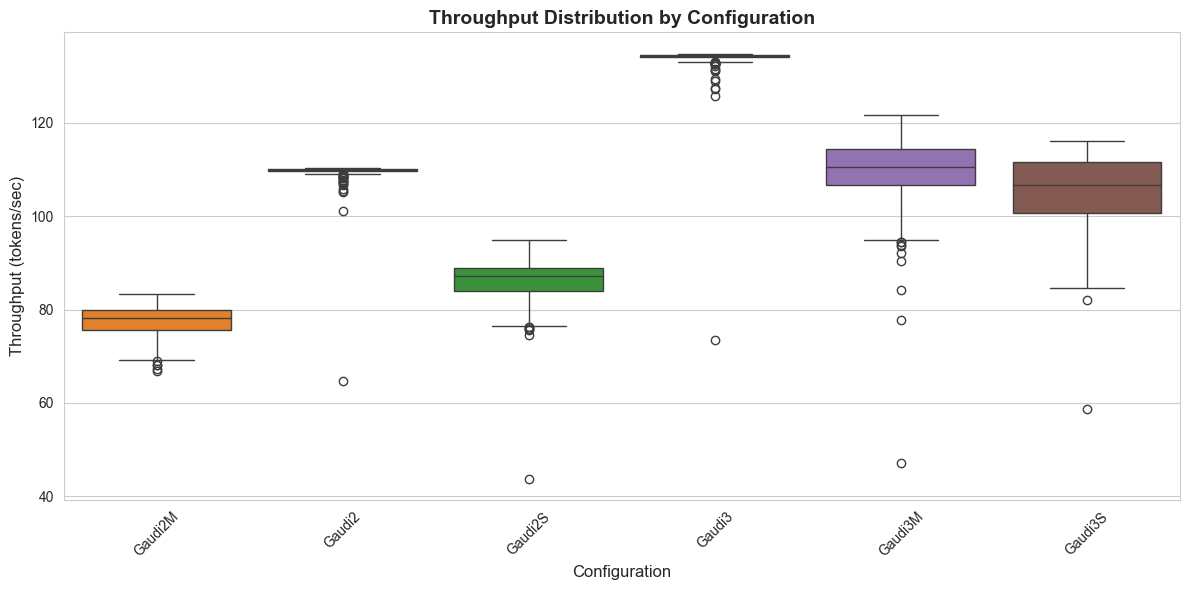

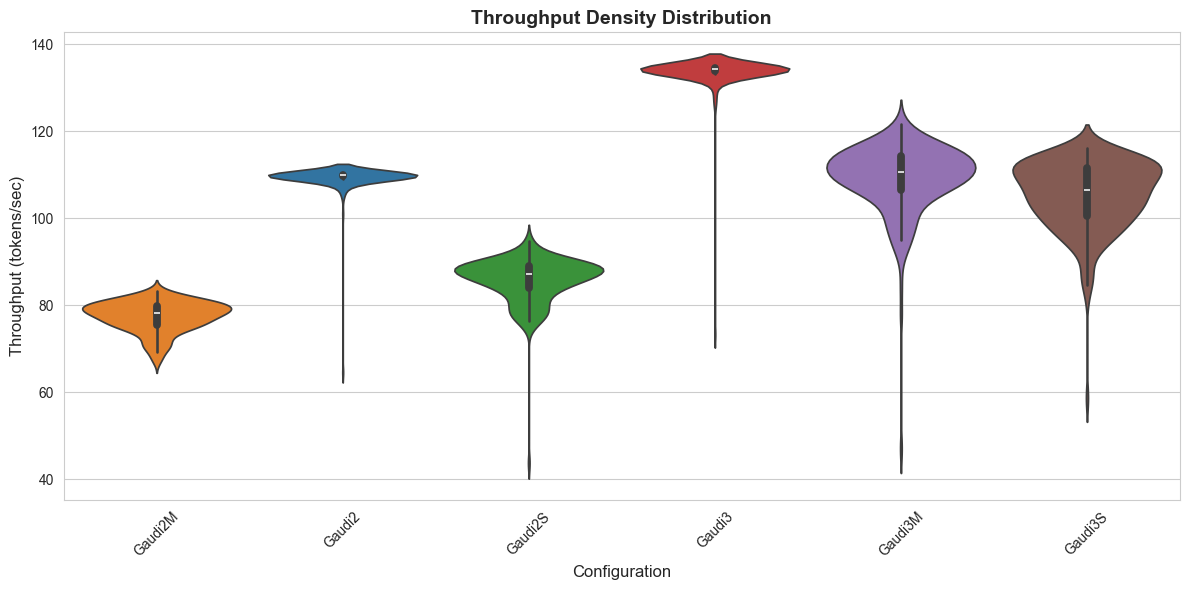

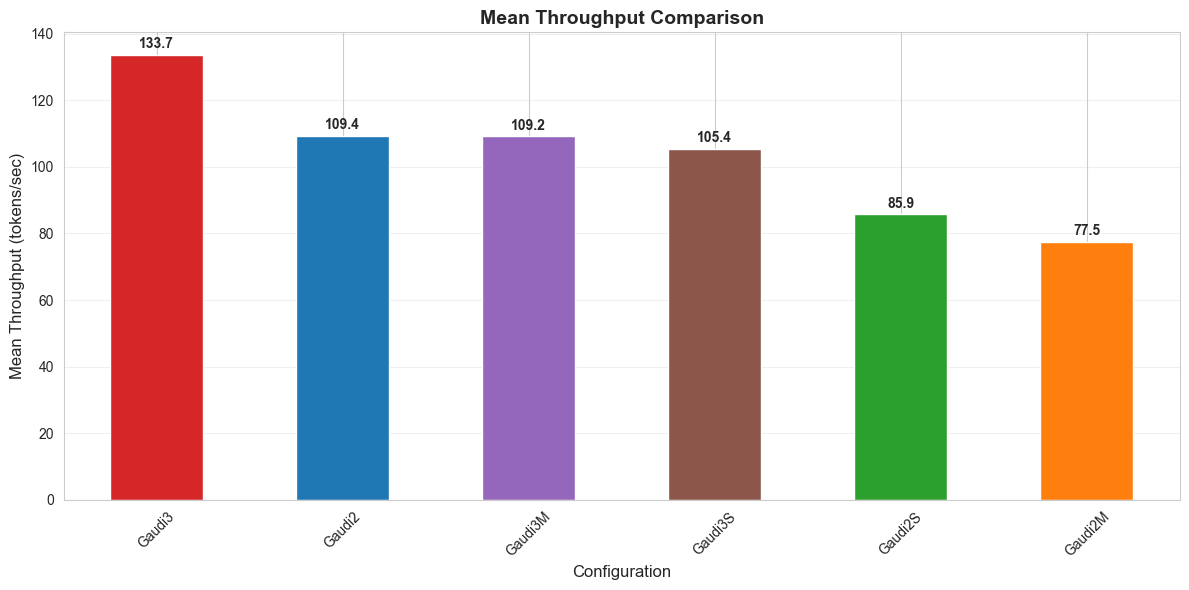

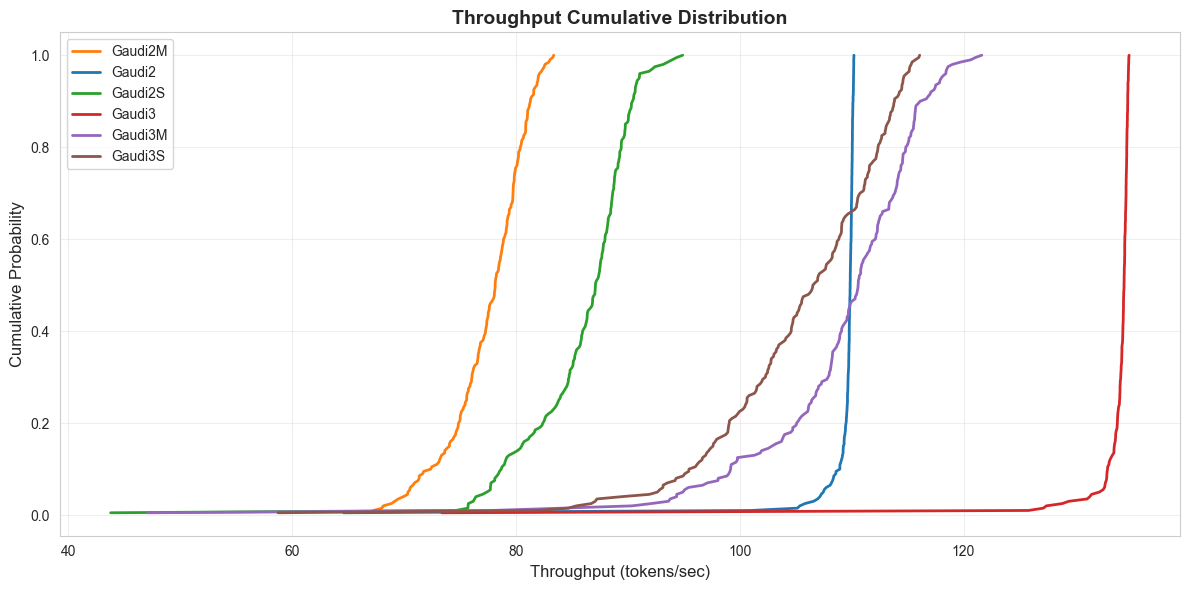

In [251]:
if 'benchmark_df' in locals():
    # 1. Box plot of throughput by configuration
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=benchmark_df, x='config', y='throughput', palette=config_colors)
    plt.title('Throughput Distribution by Configuration', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Throughput (tokens/sec)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 2. Violin plot for throughput
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=benchmark_df, x='config', y='throughput', palette=config_colors)
    plt.title('Throughput Density Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Throughput (tokens/sec)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 3. Bar plot of mean throughput
    plt.figure(figsize=(12, 6))
    mean_throughput = benchmark_df.groupby('config')['throughput'].mean().sort_values(ascending=False)
    colors = [config_colors.get(cfg, '#888888') for cfg in mean_throughput.index]
    mean_throughput.plot(kind='bar', color=colors)
    plt.title('Mean Throughput Comparison', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Mean Throughput (tokens/sec)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(mean_throughput.values):
        plt.text(i, v + 1, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 4. CDF plot
    plt.figure(figsize=(12, 6))
    for config in benchmark_df['config'].unique():
        data = benchmark_df[benchmark_df['config'] == config]['throughput'].sort_values()
        cdf = np.arange(1, len(data) + 1) / len(data)
        plt.plot(data, cdf, label=config, linewidth=2, color=config_colors.get(config, '#888888'))
    plt.title('Throughput Cumulative Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Throughput (tokens/sec)', fontsize=12)
    plt.ylabel('Cumulative Probability', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Latency Analysis (TTFT & ITL)

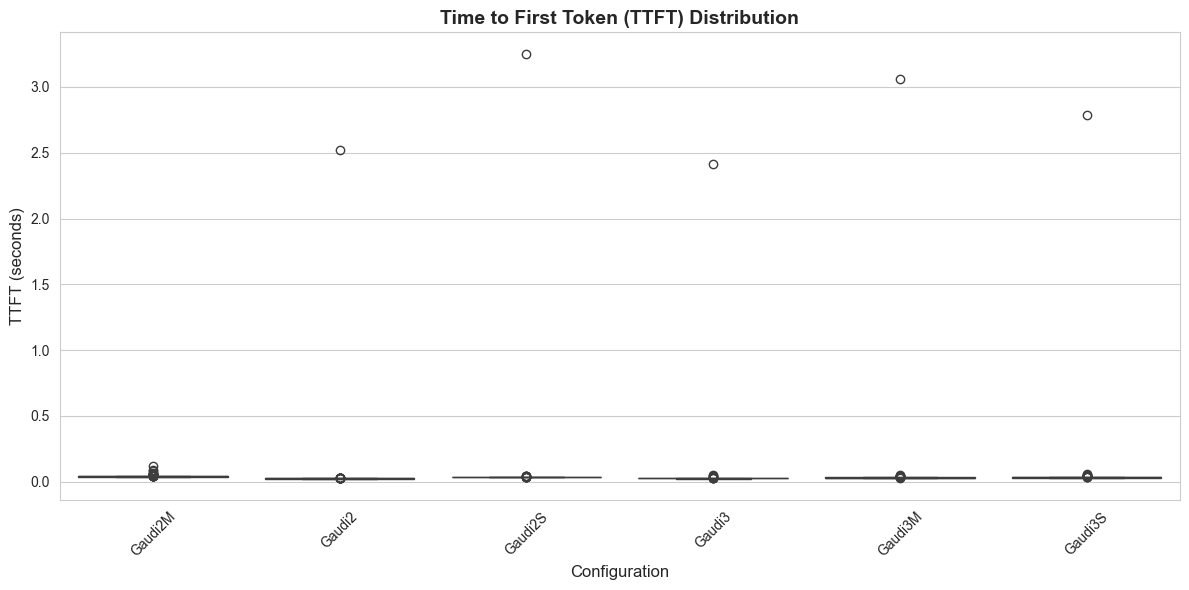

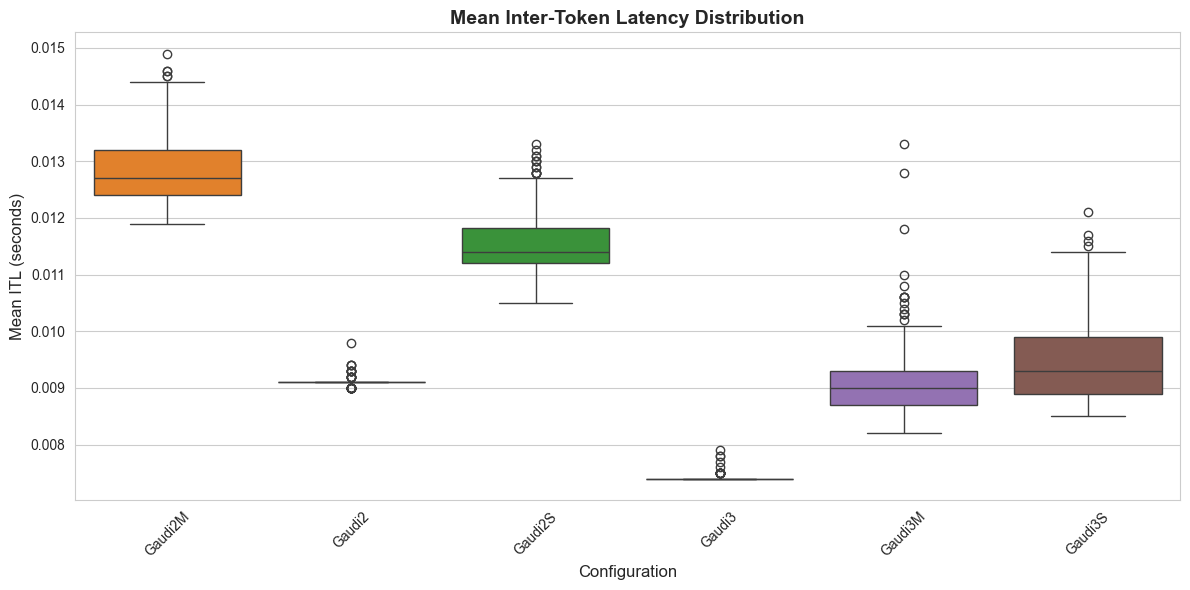

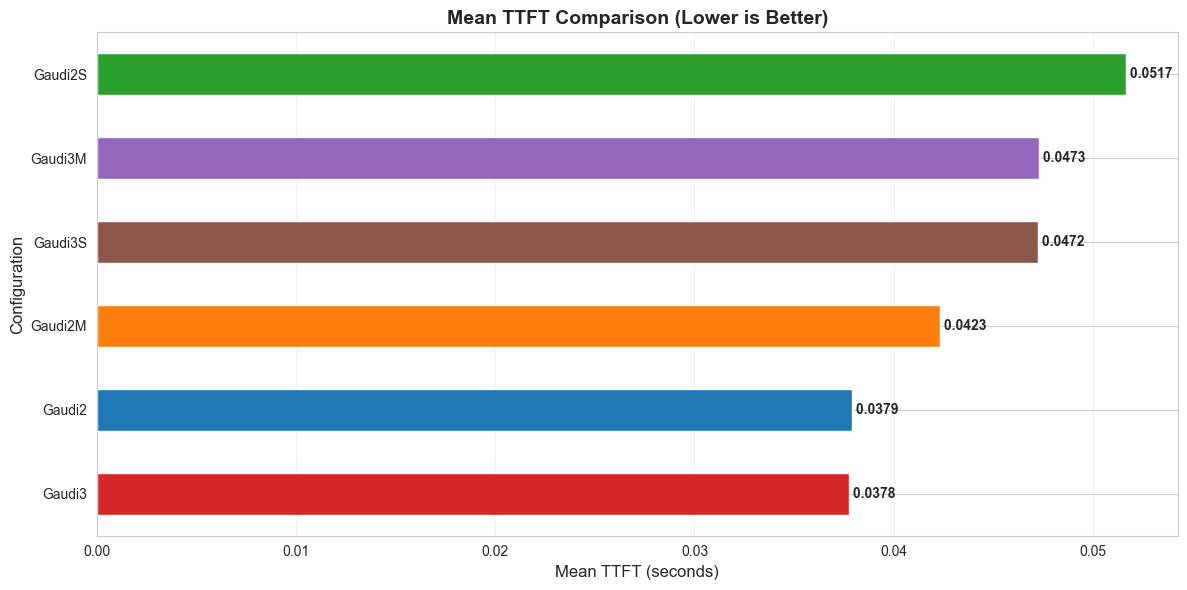

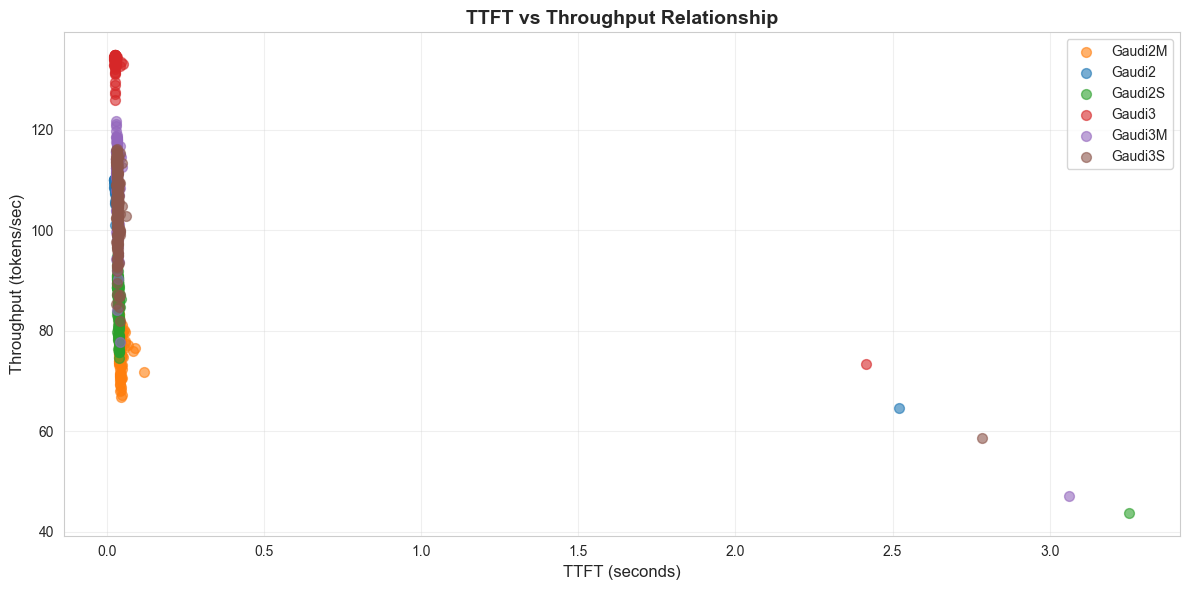

In [252]:
if 'benchmark_df' in locals():
    # 1. TTFT comparison
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=benchmark_df, x='config', y='ttft', palette=config_colors)
    plt.title('Time to First Token (TTFT) Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('TTFT (seconds)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 2. Mean ITL comparison
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=benchmark_df, x='config', y='mean_itl', palette=config_colors)
    plt.title('Mean Inter-Token Latency Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Mean ITL (seconds)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 3. Mean TTFT bar chart
    plt.figure(figsize=(12, 6))
    mean_ttft = benchmark_df.groupby('config')['ttft'].mean().sort_values()
    colors = [config_colors.get(cfg, '#888888') for cfg in mean_ttft.index]
    mean_ttft.plot(kind='barh', color=colors)
    plt.title('Mean TTFT Comparison (Lower is Better)', fontsize=14, fontweight='bold')
    plt.xlabel('Mean TTFT (seconds)', fontsize=12)
    plt.ylabel('Configuration', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(mean_ttft.values):
        plt.text(v, i, f' {v:.4f}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 4. Scatter plot: TTFT vs Throughput
    plt.figure(figsize=(12, 6))
    for config in benchmark_df['config'].unique():
        data = benchmark_df[benchmark_df['config'] == config]
        plt.scatter(data['ttft'], data['throughput'], label=config, 
                   alpha=0.6, s=50, color=config_colors.get(config, '#888888'))
    plt.title('TTFT vs Throughput Relationship', fontsize=14, fontweight='bold')
    plt.xlabel('TTFT (seconds)', fontsize=12)
    plt.ylabel('Throughput (tokens/sec)', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Multiprocessing Comparison (8 vs 16)

<Figure size 1400x600 with 0 Axes>

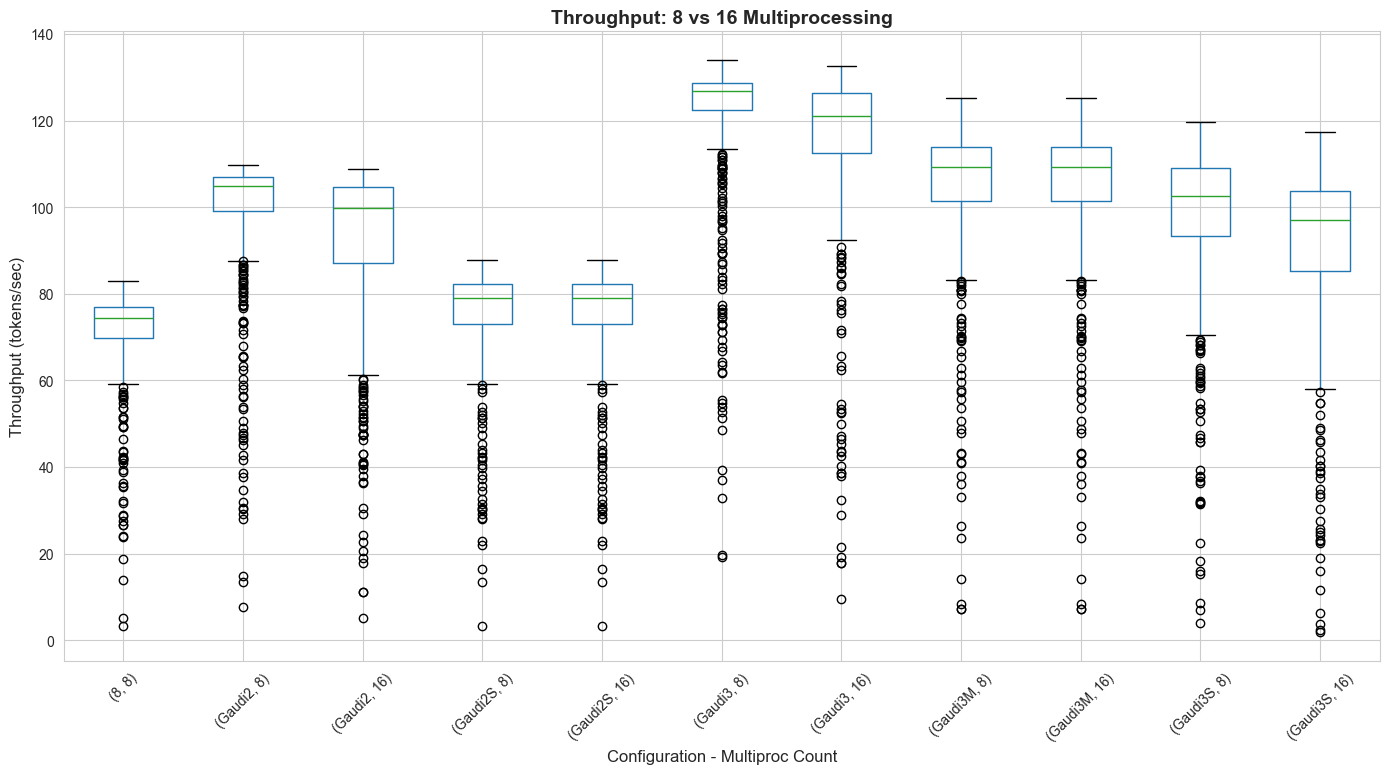

<Figure size 1200x600 with 0 Axes>

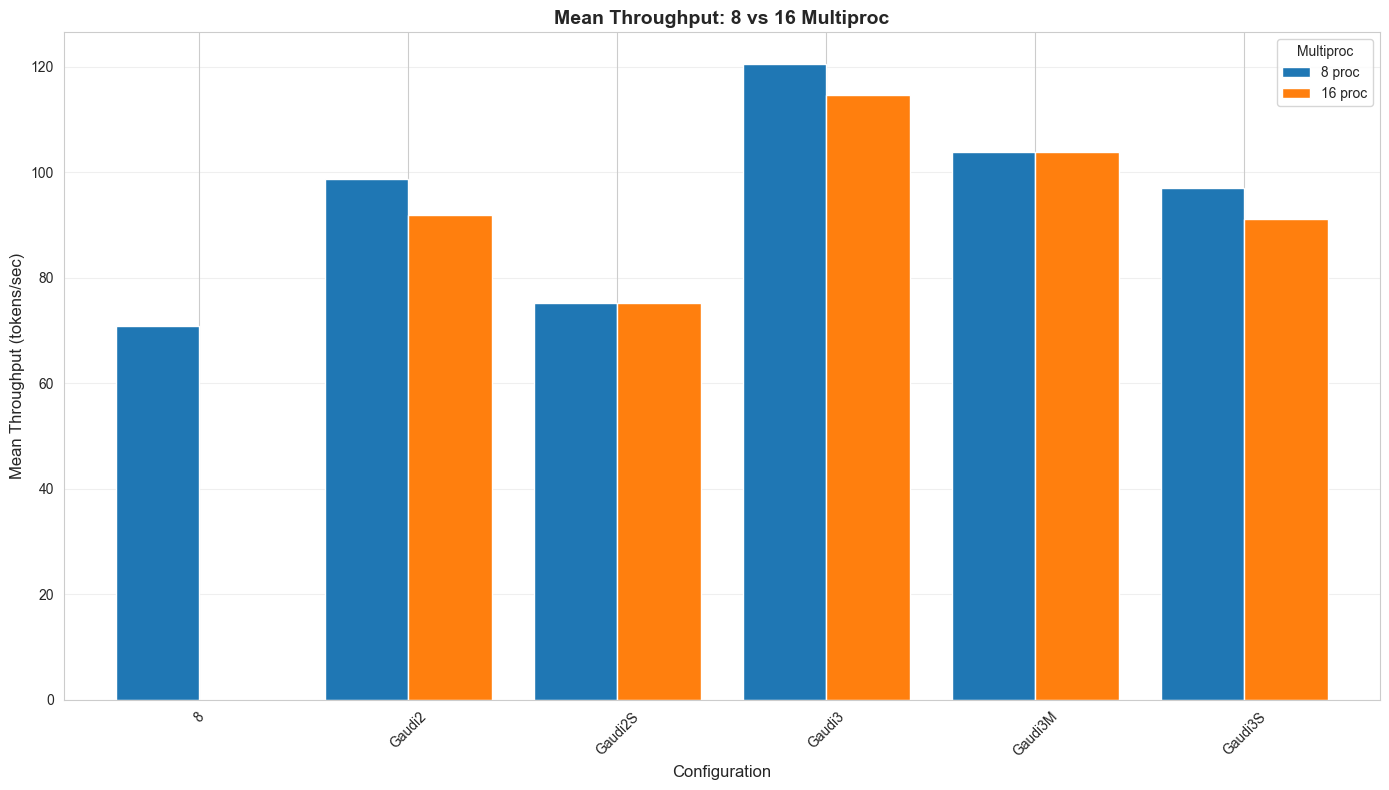

<Figure size 1200x600 with 0 Axes>

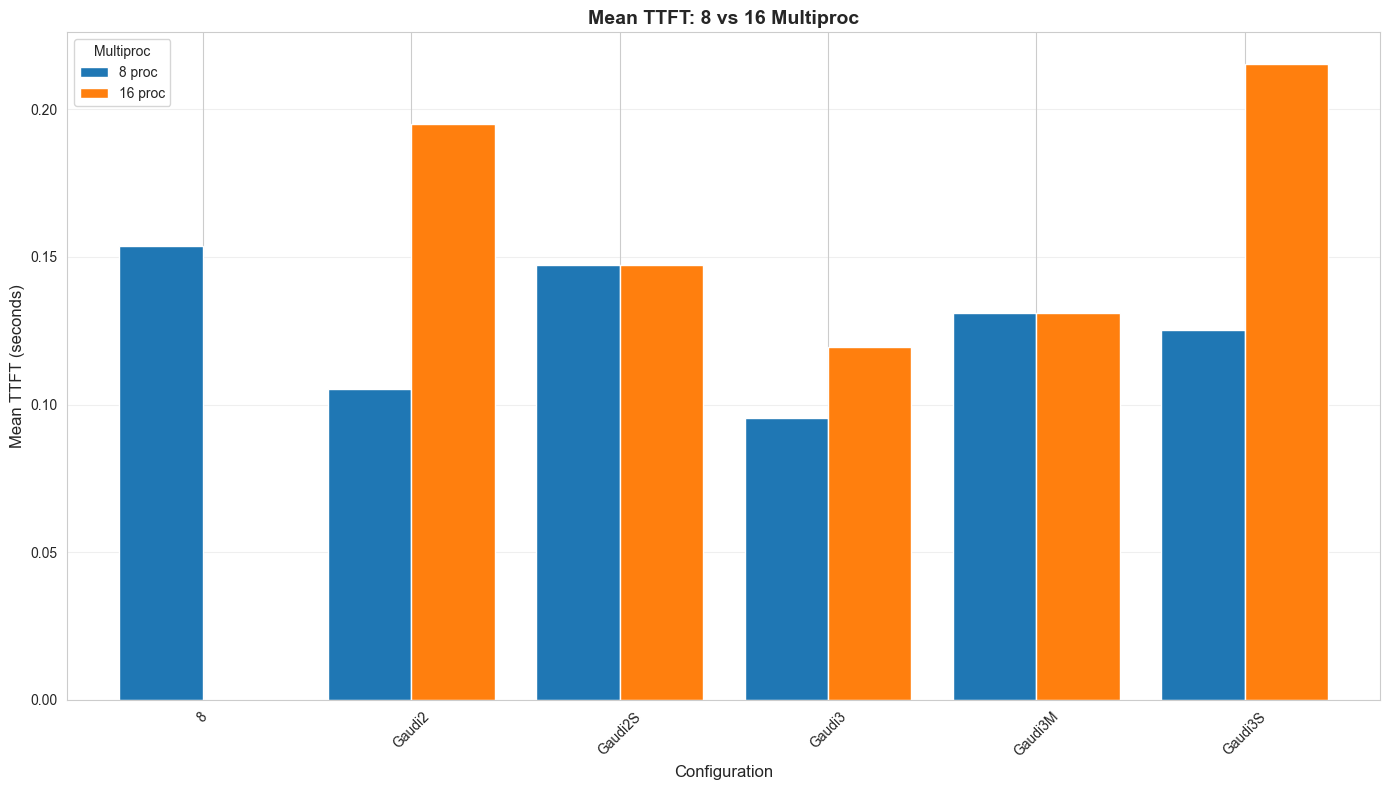

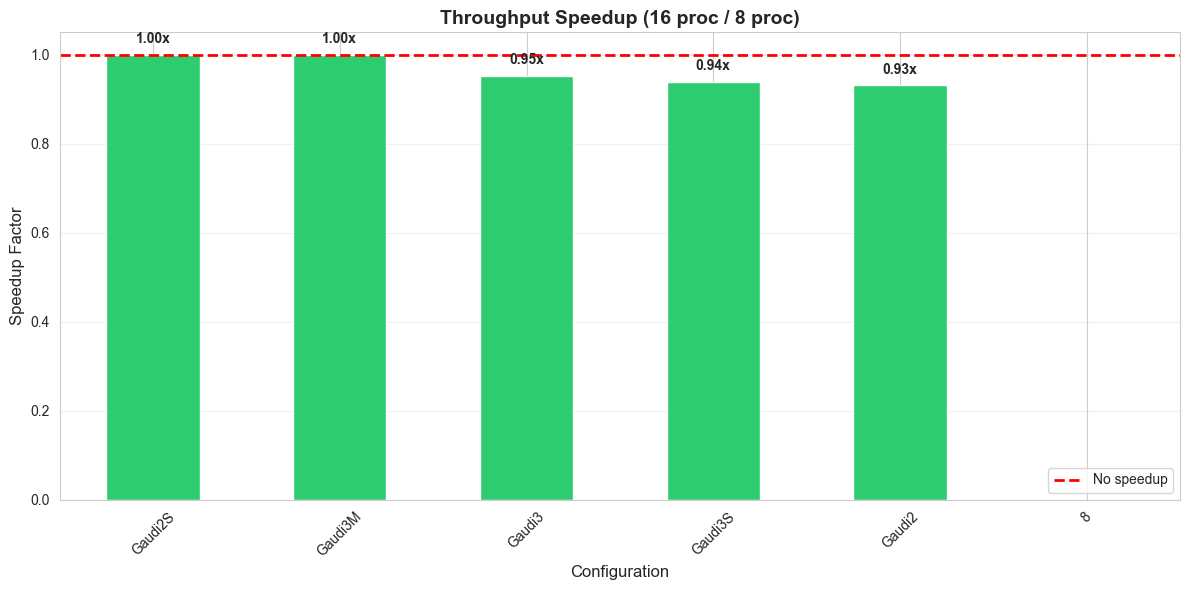


SPEEDUP ANALYSIS (16 proc vs 8 proc)
Average speedup: 0.96x
Best configuration: Gaudi2S (1.00x)
Worst configuration: Gaudi2 (0.93x)


In [253]:
# Combine alpaca benchmark data for comparison
if 'alpaca_8_df' in locals() and 'alpaca_16_df' in locals():
    alpaca_combined = pd.concat([alpaca_8_df, alpaca_16_df], ignore_index=True)
    
    # 1. Throughput comparison by multiproc
    plt.figure(figsize=(14, 6))
    alpaca_combined.boxplot(column='throughput', by=['config', 'multiproc'])
    plt.title('Throughput: 8 vs 16 Multiprocessing', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration - Multiproc Count', fontsize=12)
    plt.ylabel('Throughput (tokens/sec)', fontsize=12)
    plt.xticks(rotation=45)
    plt.suptitle('')  # Remove default title
    plt.tight_layout()
    plt.show()
    
    # 2. Mean throughput grouped bar chart
    plt.figure(figsize=(12, 6))
    throughput_pivot = alpaca_combined.groupby(['config', 'multiproc'])['throughput'].mean().unstack()
    throughput_pivot.plot(kind='bar', width=0.8)
    plt.title('Mean Throughput: 8 vs 16 Multiproc', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Mean Throughput (tokens/sec)', fontsize=12)
    plt.legend(title='Multiproc', labels=['8 proc', '16 proc'])
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 3. TTFT comparison
    plt.figure(figsize=(12, 6))
    ttft_pivot = alpaca_combined.groupby(['config', 'multiproc'])['ttft'].mean().unstack()
    ttft_pivot.plot(kind='bar', width=0.8)
    plt.title('Mean TTFT: 8 vs 16 Multiproc', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Mean TTFT (seconds)', fontsize=12)
    plt.legend(title='Multiproc', labels=['8 proc', '16 proc'])
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 4. Speedup calculation
    if 8 in throughput_pivot.columns and 16 in throughput_pivot.columns:
        plt.figure(figsize=(12, 6))
        speedup = (throughput_pivot[16] / throughput_pivot[8]).sort_values(ascending=False)
        speedup.plot(kind='bar', color='#2ecc71')
        plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='No speedup')
        plt.title('Throughput Speedup (16 proc / 8 proc)', fontsize=14, fontweight='bold')
        plt.xlabel('Configuration', fontsize=12)
        plt.ylabel('Speedup Factor', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.legend()
        
        # Add value labels
        for i, v in enumerate(speedup.values):
            plt.text(i, v + 0.02, f'{v:.2f}x', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Print speedup summary
        print("\n" + "="*80)
        print("SPEEDUP ANALYSIS (16 proc vs 8 proc)")
        print("="*80)
        print(f"Average speedup: {speedup.mean():.2f}x")
        print(f"Best configuration: {speedup.idxmax()} ({speedup.max():.2f}x)")
        print(f"Worst configuration: {speedup.idxmin()} ({speedup.min():.2f}x)")

## 7. Power Consumption Analysis

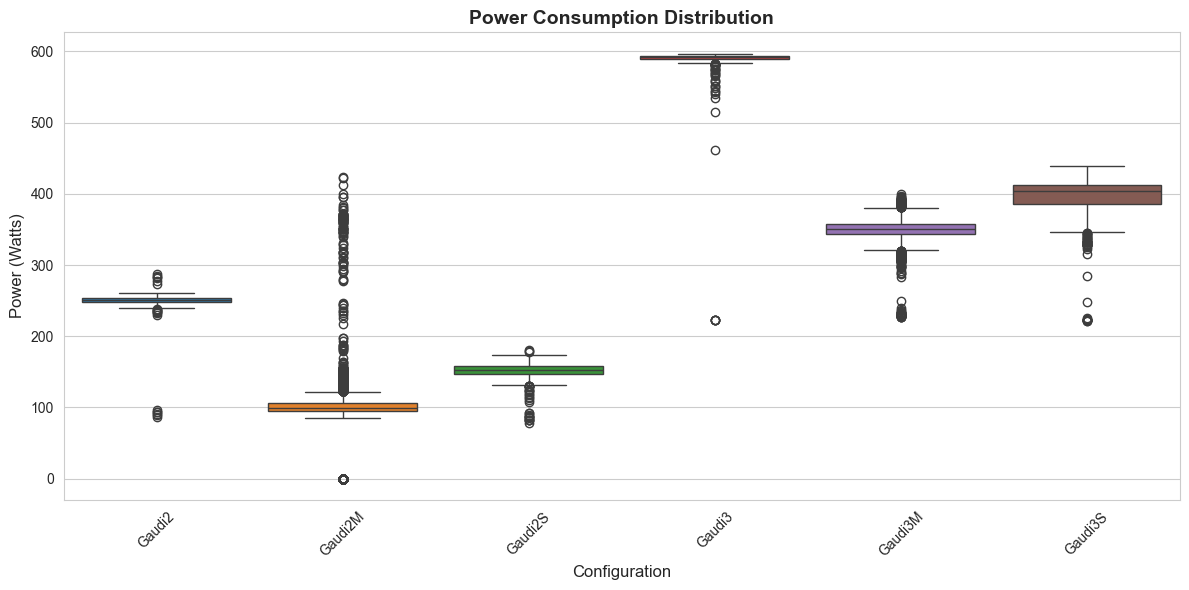

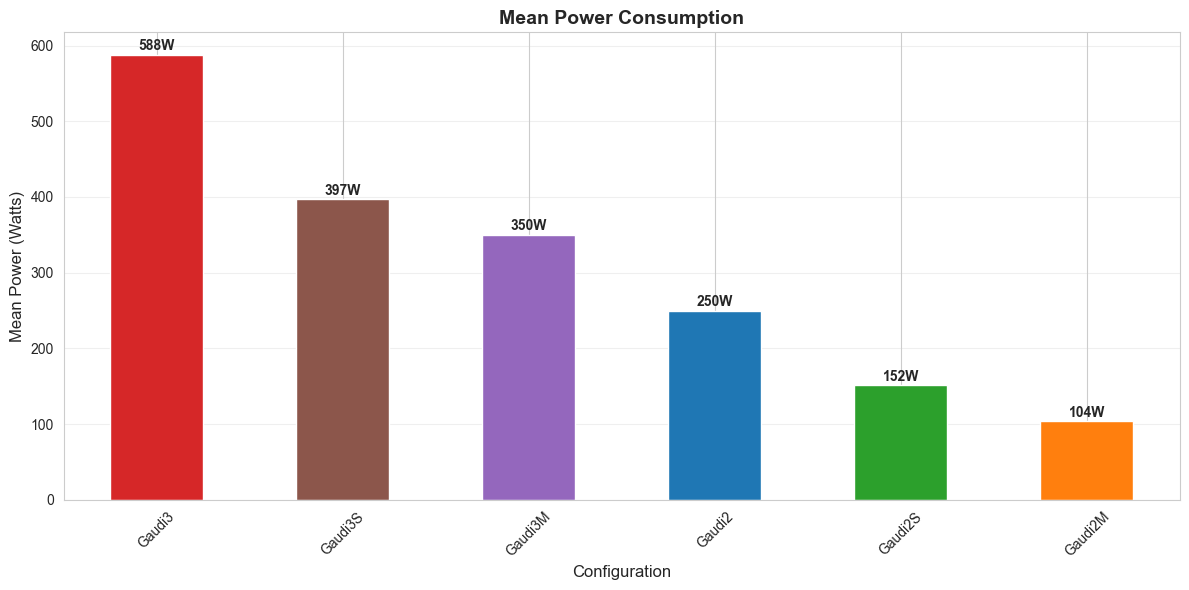

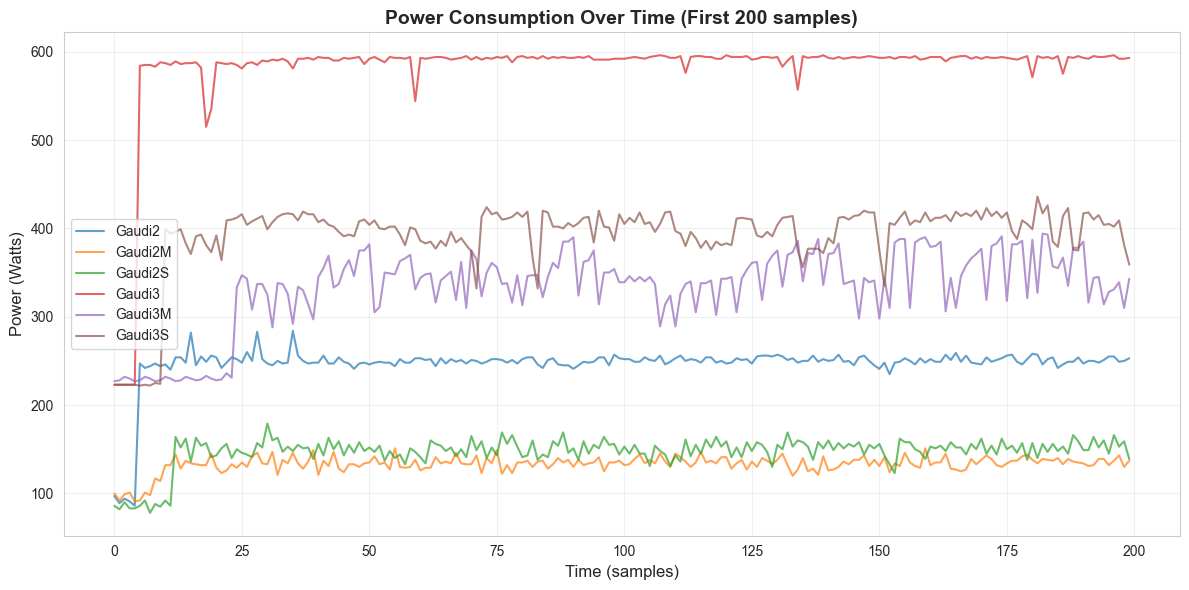

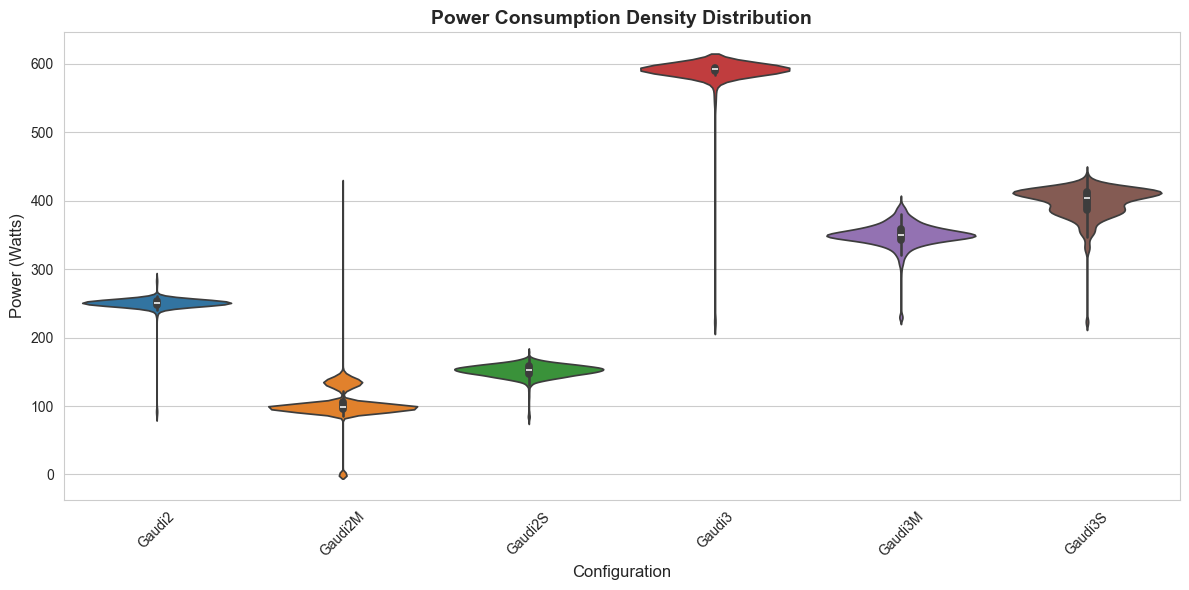

In [254]:
if 'power_df' in locals():
    # 1. Power distribution box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=power_df, x='config', y='power_w', palette=config_colors)
    plt.title('Power Consumption Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Power (Watts)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 2. Mean power consumption
    plt.figure(figsize=(12, 6))
    mean_power = power_df.groupby('config')['power_w'].mean().sort_values(ascending=False)
    colors = [config_colors.get(cfg, '#888888') for cfg in mean_power.index]
    mean_power.plot(kind='bar', color=colors)
    plt.title('Mean Power Consumption', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Mean Power (Watts)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(mean_power.values):
        plt.text(i, v + 2, f'{v:.0f}W', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 3. Power over time (sample)
    plt.figure(figsize=(12, 6))
    for config in power_df['config'].unique():
        data = power_df[power_df['config'] == config]['power_w'].head(200)
        plt.plot(data.values, label=config, alpha=0.7, color=config_colors.get(config, '#888888'))
    plt.title('Power Consumption Over Time (First 200 samples)', fontsize=14, fontweight='bold')
    plt.xlabel('Time (samples)', fontsize=12)
    plt.ylabel('Power (Watts)', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 4. Violin plot
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=power_df, x='config', y='power_w', palette=config_colors)
    plt.title('Power Consumption Density Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Power (Watts)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 8. Power Efficiency (Performance per Watt)

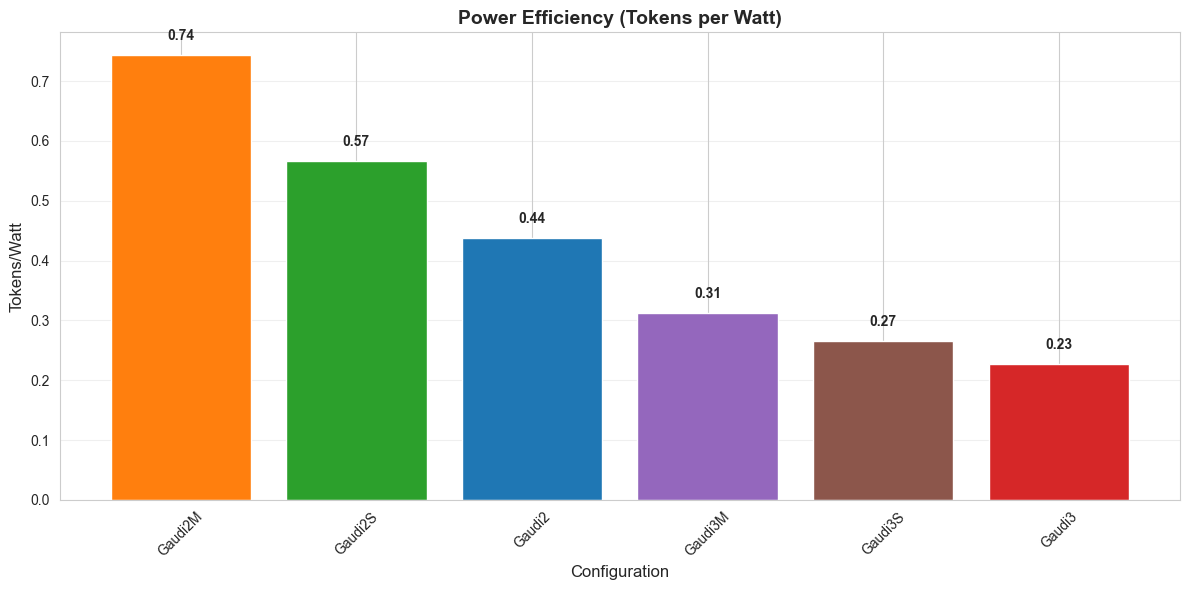

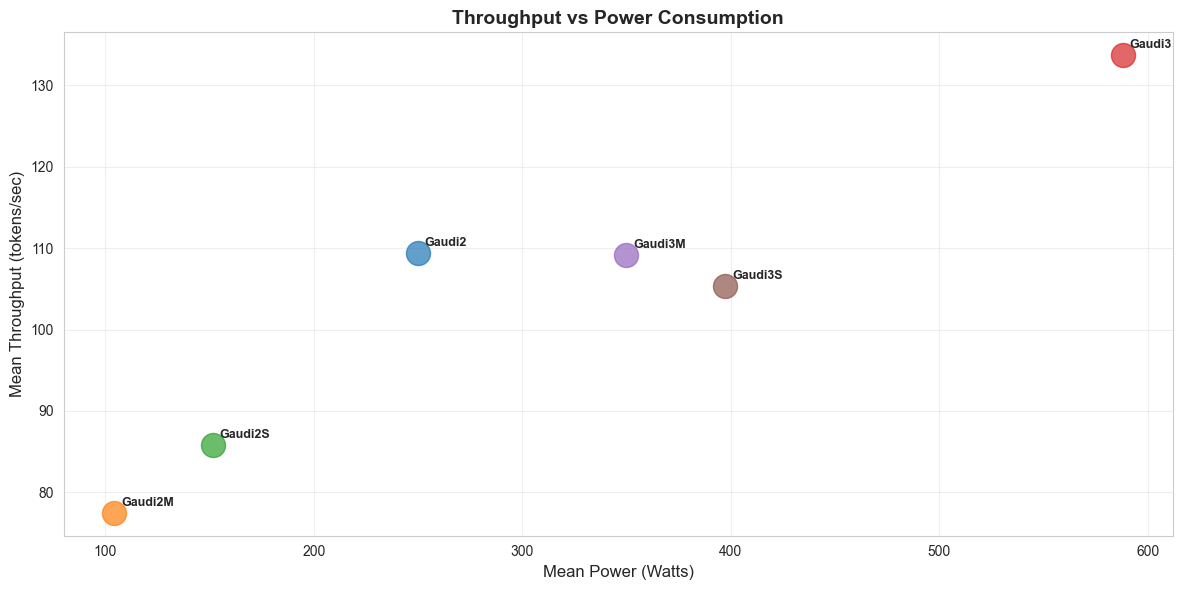


POWER EFFICIENCY SUMMARY
 config  throughput    power_w  tokens_per_watt
Gaudi2M    77.50465 104.123441         0.744354
Gaudi2S    85.86050 151.562738         0.566501
 Gaudi2   109.36665 249.784493         0.437844
Gaudi3M   109.17405 349.844902         0.312064
Gaudi3S   105.40210 397.297605         0.265298
 Gaudi3   133.67790 588.010386         0.227339

Most efficient: Gaudi2M
Least efficient: Gaudi3


In [255]:
# Calculate performance per watt
if 'benchmark_df' in locals() and 'power_df' in locals():
    # Calculate mean metrics per configuration
    perf_summary = benchmark_df.groupby('config').agg({
        'throughput': 'mean'
    }).reset_index()
    
    power_summary = power_df.groupby('config').agg({
        'power_w': 'mean'
    }).reset_index()
    
    # Merge and calculate efficiency
    efficiency_df = perf_summary.merge(power_summary, on='config')
    efficiency_df['tokens_per_watt'] = efficiency_df['throughput'] / efficiency_df['power_w']
    
    # 1. Tokens per watt
    plt.figure(figsize=(12, 6))
    efficiency_sorted = efficiency_df.sort_values('tokens_per_watt', ascending=False)
    colors = [config_colors.get(cfg, '#888888') for cfg in efficiency_sorted['config']]
    plt.bar(range(len(efficiency_sorted)), efficiency_sorted['tokens_per_watt'], color=colors)
    plt.xticks(range(len(efficiency_sorted)), efficiency_sorted['config'], rotation=45)
    plt.title('Power Efficiency (Tokens per Watt)', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Tokens/Watt', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(efficiency_sorted['tokens_per_watt'].values):
        plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 2. Scatter: Throughput vs Power
    plt.figure(figsize=(12, 6))
    for idx, row in efficiency_df.iterrows():
        plt.scatter(row['power_w'], row['throughput'], 
                   s=300, alpha=0.7, 
                   color=config_colors.get(row['config'], '#888888'),
                   label=row['config'])
        plt.annotate(row['config'], 
                    (row['power_w'], row['throughput']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold')
    
    plt.title('Throughput vs Power Consumption', fontsize=14, fontweight='bold')
    plt.xlabel('Mean Power (Watts)', fontsize=12)
    plt.ylabel('Mean Throughput (tokens/sec)', fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print efficiency summary
    print("\n" + "="*80)
    print("POWER EFFICIENCY SUMMARY")
    print("="*80)
    print(efficiency_df.sort_values('tokens_per_watt', ascending=False).to_string(index=False))
    print(f"\nMost efficient: {efficiency_df.loc[efficiency_df['tokens_per_watt'].idxmax(), 'config']}")
    print(f"Least efficient: {efficiency_df.loc[efficiency_df['tokens_per_watt'].idxmin(), 'config']}")

## 9. Overall Performance Comparison Dashboard

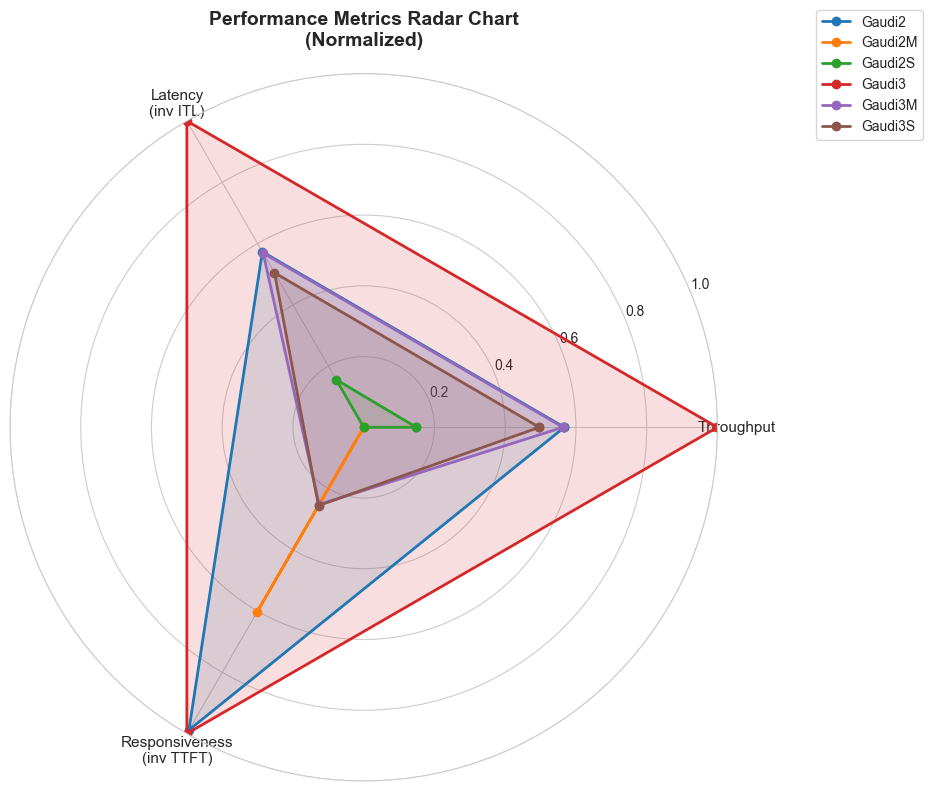

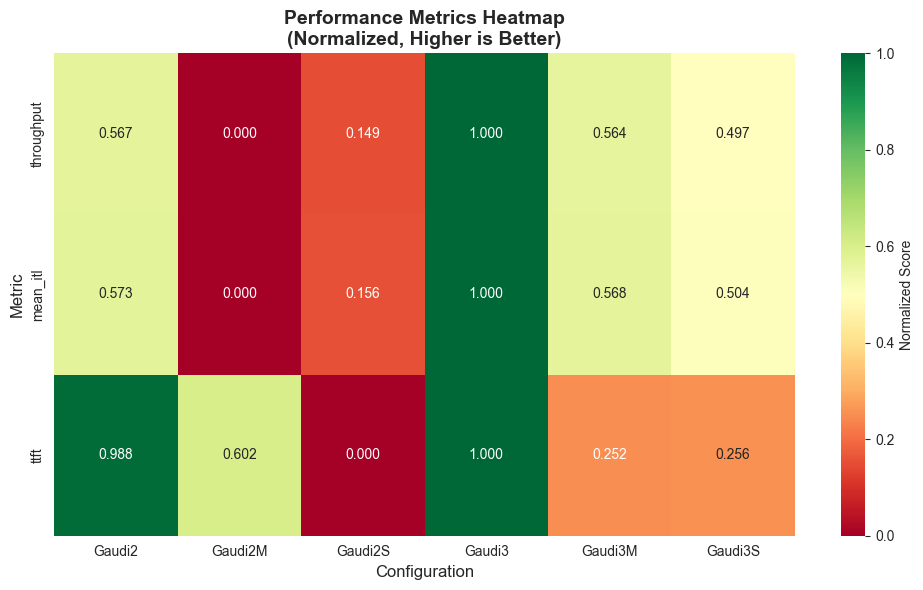

In [256]:
if 'benchmark_df' in locals():
    # Create comprehensive comparison
    metrics_summary = benchmark_df.groupby('config').agg({
        'throughput': ['mean', 'std'],
        'ttft': ['mean', 'std'],
        'mean_itl': 'mean',
        'tokens_generated': 'sum'
    }).round(3)
    
    # Normalize metrics for radar chart
    from sklearn.preprocessing import MinMaxScaler
    
    radar_data = benchmark_df.groupby('config').agg({
        'throughput': 'mean',
        'mean_itl': 'mean',
        'ttft': 'mean'
    })
    
    # Invert TTFT and ITL (lower is better)
    radar_data['ttft'] = 1 / (radar_data['ttft'] + 0.001)
    radar_data['mean_itl'] = 1 / (radar_data['mean_itl'] + 0.001)
    
    # Normalize to 0-1 scale
    scaler = MinMaxScaler()
    radar_normalized = pd.DataFrame(
        scaler.fit_transform(radar_data),
        index=radar_data.index,
        columns=radar_data.columns
    )
    
    # 1. Radar chart
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')
    
    categories = ['Throughput', 'Latency\n(inv ITL)', 'Responsiveness\n(inv TTFT)']
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    for config in radar_normalized.index:
        values = radar_normalized.loc[config].tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, 
                label=config, color=config_colors.get(config, '#888888'))
        ax.fill(angles, values, alpha=0.15, color=config_colors.get(config, '#888888'))
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title('Performance Metrics Radar Chart\n(Normalized)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Heatmap of normalized metrics
    plt.figure(figsize=(10, 6))
    sns.heatmap(radar_normalized.T, annot=True, fmt='.3f', cmap='RdYlGn', 
               cbar_kws={'label': 'Normalized Score'},
               vmin=0, vmax=1)
    plt.title('Performance Metrics Heatmap\n(Normalized, Higher is Better)', 
                 fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Metric', fontsize=12)
    plt.tight_layout()
    plt.show()

## 10. Generate Summary Report

In [257]:
# Generate a comprehensive text summary
print("\n" + "="*80)
print(" " * 20 + "MISTRAL 7B vLLM PERFORMANCE SUMMARY")
print("="*80)

if 'benchmark_df' in locals():
    print("\n📊 BENCHMARK STATISTICS:")
    print(f"  • Total prompts processed: {len(benchmark_df)}")
    print(f"  • Total tokens generated: {benchmark_df['tokens_generated'].sum():,.0f}")
    print(f"  • Configurations tested: {benchmark_df['config'].nunique()}")
    
    best_throughput_config = benchmark_df.groupby('config')['throughput'].mean().idxmax()
    best_throughput_value = benchmark_df.groupby('config')['throughput'].mean().max()
    
    best_ttft_config = benchmark_df.groupby('config')['ttft'].mean().idxmin()
    best_ttft_value = benchmark_df.groupby('config')['ttft'].mean().min()
    
    print(f"\n🏆 BEST PERFORMERS:")
    print(f"  • Highest throughput: {best_throughput_config} ({best_throughput_value:.2f} tokens/sec)")
    print(f"  • Lowest TTFT: {best_ttft_config} ({best_ttft_value:.4f} sec)")

if 'power_df' in locals():
    print(f"\n⚡ POWER CONSUMPTION:")
    lowest_power_config = power_df.groupby('config')['power_w'].mean().idxmin()
    lowest_power_value = power_df.groupby('config')['power_w'].mean().min()
    highest_power_config = power_df.groupby('config')['power_w'].mean().idxmax()
    highest_power_value = power_df.groupby('config')['power_w'].mean().max()
    
    print(f"  • Lowest power: {lowest_power_config} ({lowest_power_value:.0f}W)")
    print(f"  • Highest power: {highest_power_config} ({highest_power_value:.0f}W)")

if 'efficiency_df' in locals():
    print(f"\n💡 POWER EFFICIENCY:")
    most_efficient = efficiency_df.loc[efficiency_df['tokens_per_watt'].idxmax()]
    print(f"  • Most efficient: {most_efficient['config']} ({most_efficient['tokens_per_watt']:.2f} tokens/watt)")

if 'alpaca_combined' in locals():
    print(f"\n🔄 MULTIPROCESSING INSIGHTS:")
    avg_throughput_8 = alpaca_8_df['throughput'].mean()
    avg_throughput_16 = alpaca_16_df['throughput'].mean()
    print(f"  • Avg throughput (8 proc): {avg_throughput_8:.2f} tokens/sec")
    print(f"  • Avg throughput (16 proc): {avg_throughput_16:.2f} tokens/sec")
    print(f"  • Speedup: {avg_throughput_16/avg_throughput_8:.2f}x")

print("\n" + "="*80)
print(" " * 25 + "Analysis Complete!")
print("="*80)


                    MISTRAL 7B vLLM PERFORMANCE SUMMARY

📊 BENCHMARK STATISTICS:
  • Total prompts processed: 1200
  • Total tokens generated: 546,932
  • Configurations tested: 6

🏆 BEST PERFORMERS:
  • Highest throughput: Gaudi3 (133.68 tokens/sec)
  • Lowest TTFT: Gaudi3 (0.0378 sec)

⚡ POWER CONSUMPTION:
  • Lowest power: Gaudi2M (104W)
  • Highest power: Gaudi3 (588W)

💡 POWER EFFICIENCY:
  • Most efficient: Gaudi2M (0.74 tokens/watt)

🔄 MULTIPROCESSING INSIGHTS:
  • Avg throughput (8 proc): 94.39 tokens/sec
  • Avg throughput (16 proc): 95.36 tokens/sec
  • Speedup: 1.01x

                         Analysis Complete!


## 11. Export Summary Data

In [258]:
# Display summary statistics in notebook
if 'benchmark_df' in locals():
    summary_export = benchmark_df.groupby('config').agg({
        'throughput': ['mean', 'std', 'min', 'max', 'median'],
        'ttft': ['mean', 'std', 'min', 'max', 'median'],
        'mean_itl': ['mean', 'std'],
        'tokens_generated': ['sum', 'mean']
    }).round(4)
    
    print("\n" + "="*80)
    print("BENCHMARK SUMMARY TABLE")
    print("="*80)
    print(summary_export)

if 'power_df' in locals():
    power_export = power_df.groupby('config').agg({
        'power_w': ['mean', 'std', 'min', 'max', 'median']
    }).round(2)
    
    print("\n" + "="*80)
    print("POWER SUMMARY TABLE")
    print("="*80)
    print(power_export)

if 'efficiency_df' in locals():
    print("\n" + "="*80)
    print("EFFICIENCY SUMMARY TABLE")
    print("="*80)
    print(efficiency_df.sort_values('tokens_per_watt', ascending=False).to_string(index=False))


BENCHMARK SUMMARY TABLE
        throughput                                    ttft                  \
              mean     std    min     max   median    mean     std     min   
config                                                                       
Gaudi2    109.3666  3.3352  64.61  110.21  109.870  0.0379  0.1765  0.0237   
Gaudi2M    77.5046  3.4820  66.92   83.39   78.155  0.0423  0.0080  0.0379   
Gaudi2S    85.8605  5.2077  43.80   94.91   87.120  0.0517  0.2275  0.0323   
Gaudi3    133.6779  4.4517  73.39  134.79  134.340  0.0378  0.1689  0.0237   
Gaudi3M   109.1740  8.1291  47.12  121.63  110.590  0.0473  0.2142  0.0285   
Gaudi3S   105.4021  7.9303  58.75  116.08  106.630  0.0472  0.1947  0.0288   

                        mean_itl         tokens_generated           
            max  median     mean     std              sum     mean  
config                                                              
Gaudi2   2.5211  0.0249   0.0091  0.0001            95676  478.38

## 12. Performance Consistency Analysis

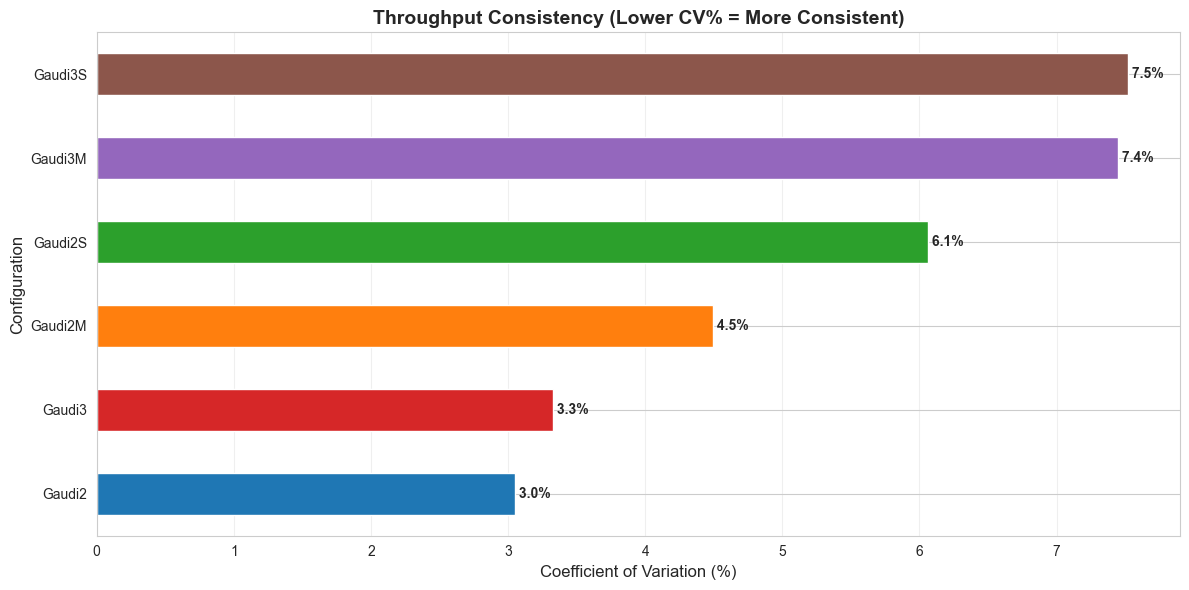

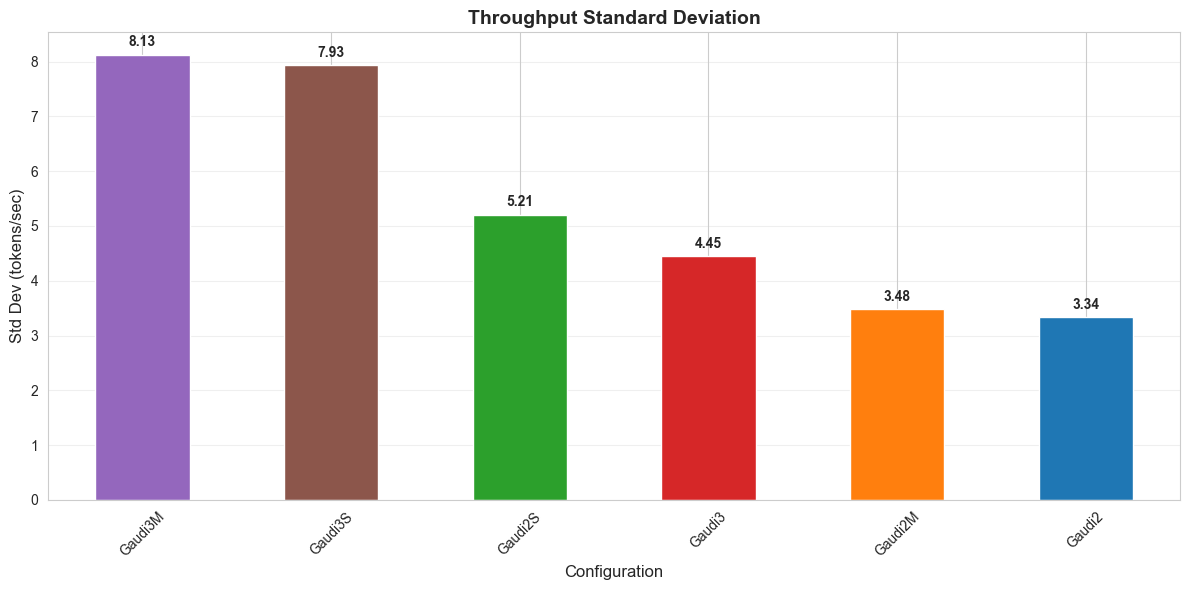

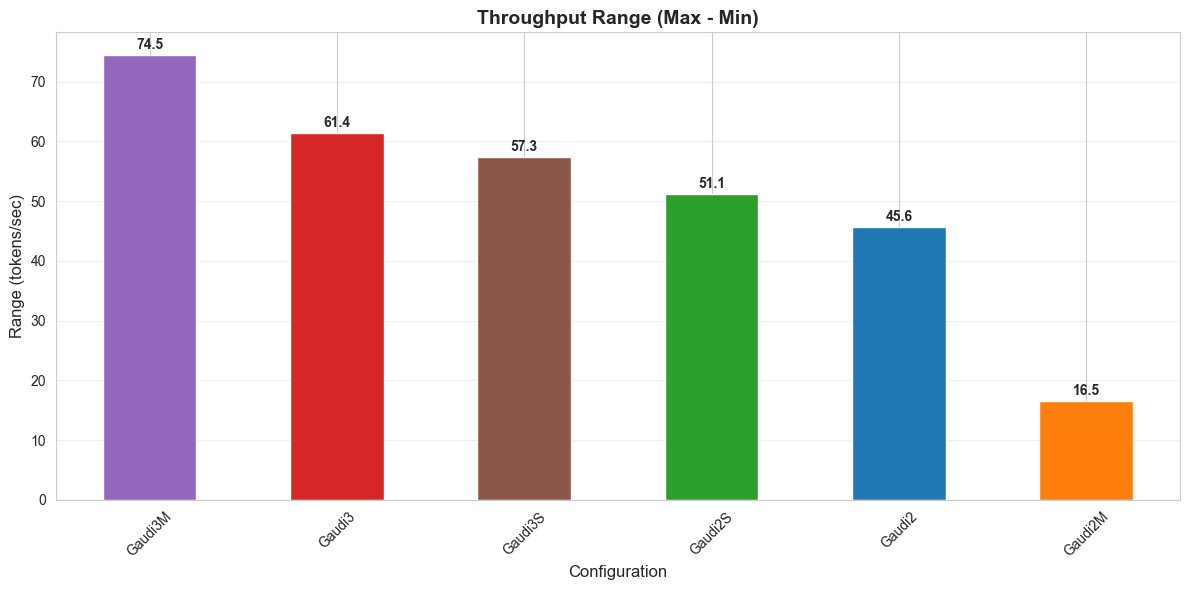

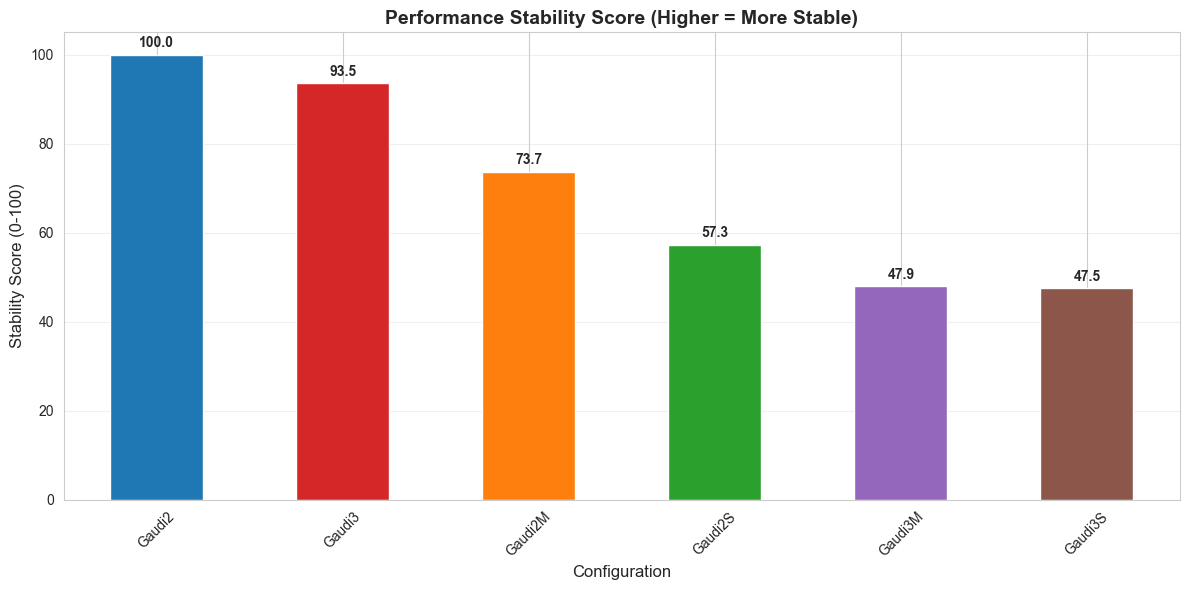


CONSISTENCY ANALYSIS

Most consistent (lowest CV%): Gaudi2 (3.05%)
Least consistent (highest CV%): Gaudi3S (7.52%)

Most stable: Gaudi2 (Score: 100.0/100)
Least stable: Gaudi3S (Score: 47.5/100)


In [259]:
if 'benchmark_df' in locals():
    # Calculate coefficient of variation (CV) for consistency analysis
    consistency_metrics = benchmark_df.groupby('config').agg({
        'throughput': ['mean', 'std', lambda x: (x.std() / x.mean()) * 100],  # CV%
        'ttft': ['mean', 'std', lambda x: (x.std() / x.mean()) * 100]
    })
    
    # Rename columns for clarity
    consistency_metrics.columns = ['_'.join(col).strip() for col in consistency_metrics.columns.values]
    
    # 1. Coefficient of Variation - Throughput
    plt.figure(figsize=(12, 6))
    cv_throughput = benchmark_df.groupby('config')['throughput'].apply(lambda x: (x.std() / x.mean()) * 100).sort_values()
    colors = [config_colors.get(cfg, '#888888') for cfg in cv_throughput.index]
    cv_throughput.plot(kind='barh', color=colors)
    plt.title('Throughput Consistency (Lower CV% = More Consistent)', fontsize=14, fontweight='bold')
    plt.xlabel('Coefficient of Variation (%)', fontsize=12)
    plt.ylabel('Configuration', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    for i, v in enumerate(cv_throughput.values):
        plt.text(v, i, f' {v:.1f}%', va='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 2. Standard Deviation Distribution
    plt.figure(figsize=(12, 6))
    std_data = benchmark_df.groupby('config')['throughput'].std().sort_values(ascending=False)
    colors = [config_colors.get(cfg, '#888888') for cfg in std_data.index]
    std_data.plot(kind='bar', color=colors)
    plt.title('Throughput Standard Deviation', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Std Dev (tokens/sec)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    for i, v in enumerate(std_data.values):
        plt.text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 3. Performance Range (Max - Min)
    plt.figure(figsize=(12, 6))
    perf_range = benchmark_df.groupby('config')['throughput'].apply(lambda x: x.max() - x.min()).sort_values(ascending=False)
    colors = [config_colors.get(cfg, '#888888') for cfg in perf_range.index]
    perf_range.plot(kind='bar', color=colors)
    plt.title('Throughput Range (Max - Min)', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Range (tokens/sec)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    for i, v in enumerate(perf_range.values):
        plt.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 4. Stability Score (inverse of CV, normalized)
    plt.figure(figsize=(12, 6))
    stability_score = 100 / (cv_throughput + 1)  # Higher is better
    stability_score = (stability_score / stability_score.max()) * 100  # Normalize to 0-100
    stability_score = stability_score.sort_values(ascending=False)
    colors = [config_colors.get(cfg, '#888888') for cfg in stability_score.index]
    stability_score.plot(kind='bar', color=colors)
    plt.title('Performance Stability Score (Higher = More Stable)', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Stability Score (0-100)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    for i, v in enumerate(stability_score.values):
        plt.text(i, v + 1, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print consistency insights
    print("\n" + "="*80)
    print("CONSISTENCY ANALYSIS")
    print("="*80)
    print(f"\nMost consistent (lowest CV%): {cv_throughput.idxmin()} ({cv_throughput.min():.2f}%)")
    print(f"Least consistent (highest CV%): {cv_throughput.idxmax()} ({cv_throughput.max():.2f}%)")
    print(f"\nMost stable: {stability_score.idxmax()} (Score: {stability_score.max():.1f}/100)")
    print(f"Least stable: {stability_score.idxmin()} (Score: {stability_score.min():.1f}/100)")

## 13. Latency Percentile Analysis

<Figure size 1200x600 with 0 Axes>

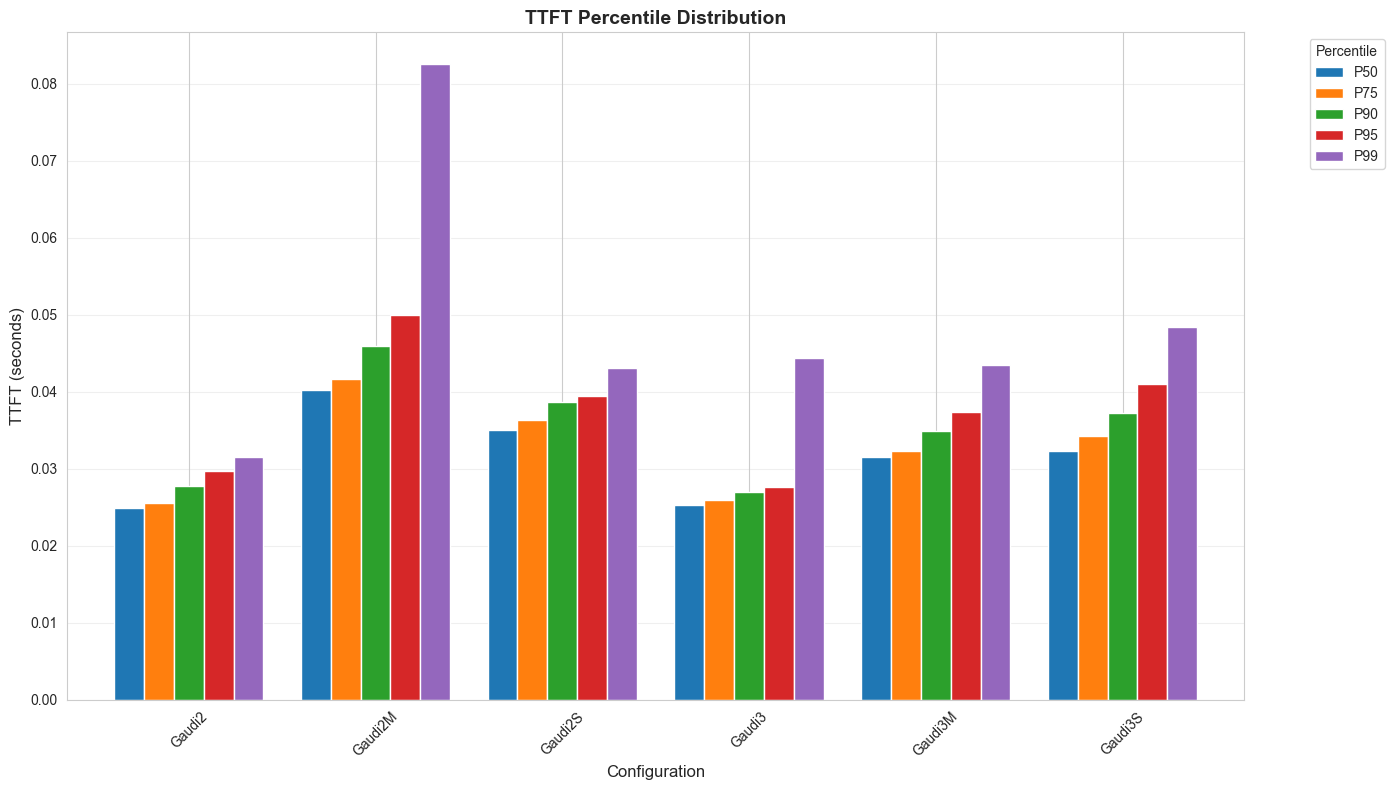

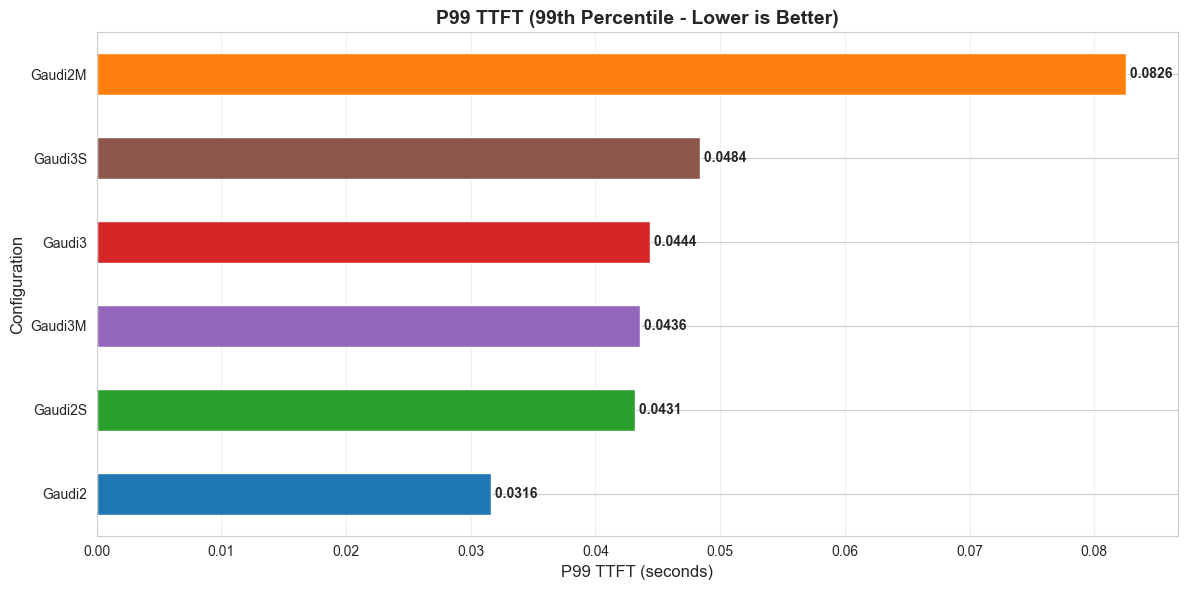

<Figure size 1200x600 with 0 Axes>

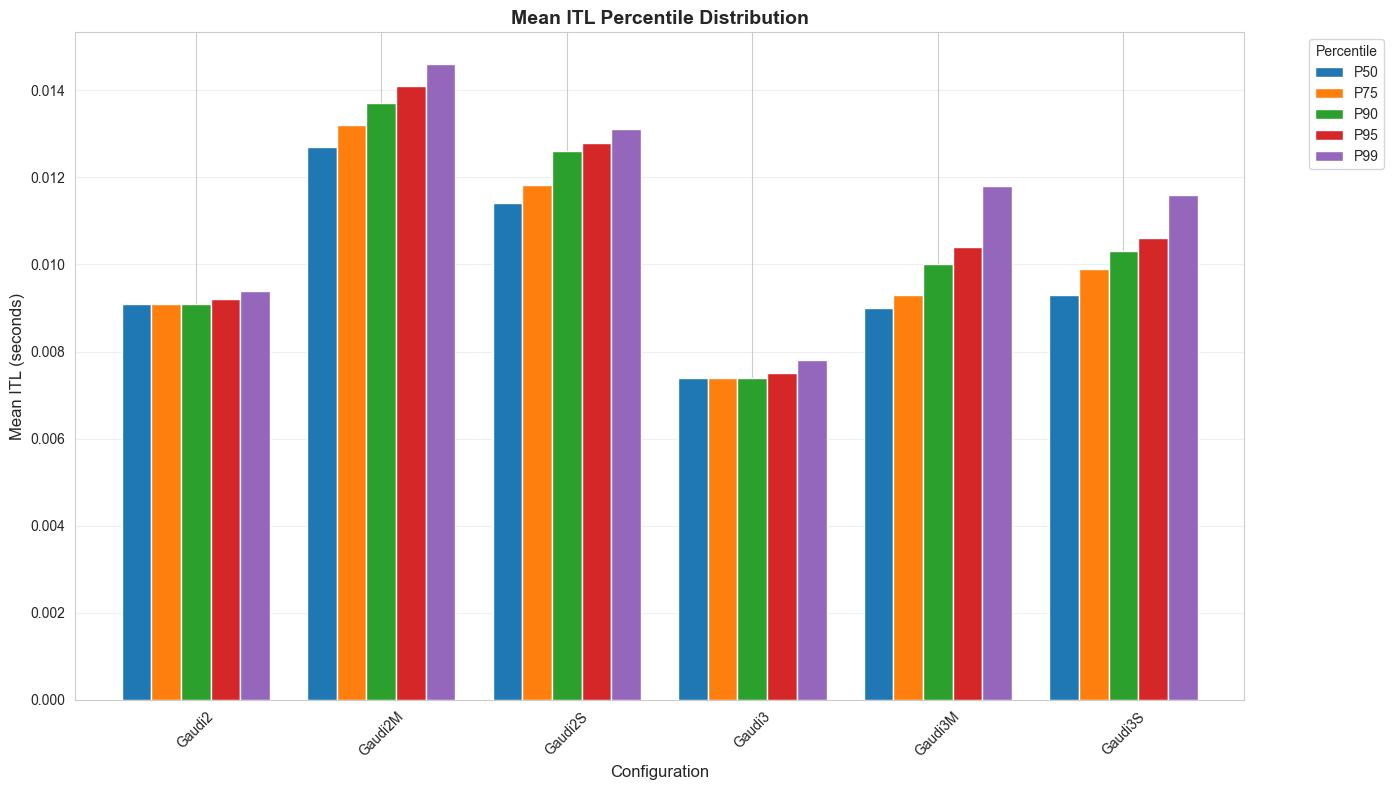

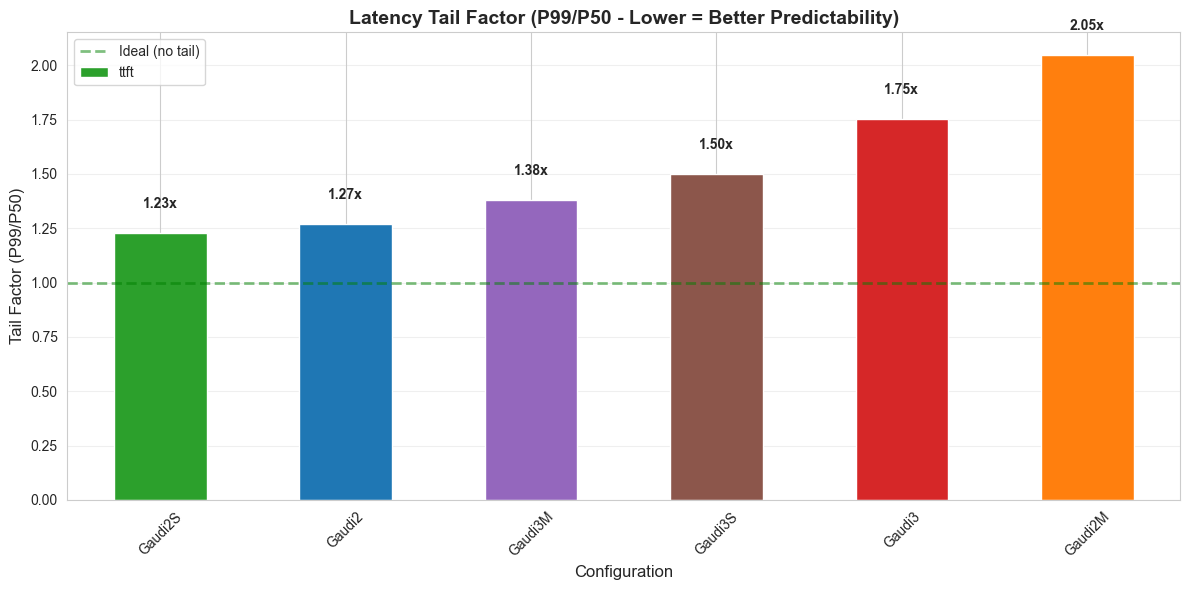


LATENCY PERCENTILE INSIGHTS
Best P99 TTFT: Gaudi2 (0.0316 sec)
Worst P99 TTFT: Gaudi2M (0.0826 sec)

Best tail distribution: Gaudi2S (1.23x)
Worst tail distribution: Gaudi2M (2.05x)


In [260]:
if 'benchmark_df' in locals():
    # Calculate percentiles for TTFT and ITL
    percentiles = [50, 75, 90, 95, 99]
    
    # 1. TTFT Percentiles
    plt.figure(figsize=(12, 6))
    ttft_percentiles = {}
    for config in sorted(benchmark_df['config'].unique()):
        data = benchmark_df[benchmark_df['config'] == config]['ttft']
        ttft_percentiles[config] = [np.percentile(data, p) for p in percentiles]
    
    ttft_df = pd.DataFrame(ttft_percentiles, index=[f'P{p}' for p in percentiles]).T
    ttft_df.plot(kind='bar', width=0.8)
    plt.title('TTFT Percentile Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('TTFT (seconds)', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Percentile', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 2. P99 Latency Comparison (Important for SLA)
    plt.figure(figsize=(12, 6))
    p99_ttft = benchmark_df.groupby('config')['ttft'].quantile(0.99).sort_values()
    colors = [config_colors.get(cfg, '#888888') for cfg in p99_ttft.index]
    p99_ttft.plot(kind='barh', color=colors)
    plt.title('P99 TTFT (99th Percentile - Lower is Better)', fontsize=14, fontweight='bold')
    plt.xlabel('P99 TTFT (seconds)', fontsize=12)
    plt.ylabel('Configuration', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    for i, v in enumerate(p99_ttft.values):
        plt.text(v, i, f' {v:.4f}', va='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 3. ITL Percentiles
    plt.figure(figsize=(12, 6))
    itl_percentiles = {}
    for config in sorted(benchmark_df['config'].unique()):
        data = benchmark_df[benchmark_df['config'] == config]['mean_itl']
        itl_percentiles[config] = [np.percentile(data, p) for p in percentiles]
    
    itl_df = pd.DataFrame(itl_percentiles, index=[f'P{p}' for p in percentiles]).T
    itl_df.plot(kind='bar', width=0.8)
    plt.title('Mean ITL Percentile Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Mean ITL (seconds)', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Percentile', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 4. Latency Tail Distribution (P99/P50 ratio)
    plt.figure(figsize=(12, 6))
    p50_ttft = benchmark_df.groupby('config')['ttft'].quantile(0.50)
    tail_ratio = (p99_ttft / p50_ttft).sort_values()
    colors = [config_colors.get(cfg, '#888888') for cfg in tail_ratio.index]
    tail_ratio.plot(kind='bar', color=colors)
    plt.title('Latency Tail Factor (P99/P50 - Lower = Better Predictability)', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Tail Factor (P99/P50)', fontsize=12)
    plt.xticks(rotation=45)
    plt.axhline(y=1.0, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Ideal (no tail)')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    for i, v in enumerate(tail_ratio.values):
        plt.text(i, v + 0.1, f'{v:.2f}x', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print percentile insights
    print("\n" + "="*80)
    print("LATENCY PERCENTILE INSIGHTS")
    print("="*80)
    print(f"Best P99 TTFT: {p99_ttft.idxmin()} ({p99_ttft.min():.4f} sec)")
    print(f"Worst P99 TTFT: {p99_ttft.idxmax()} ({p99_ttft.max():.4f} sec)")
    print(f"\nBest tail distribution: {tail_ratio.idxmin()} ({tail_ratio.min():.2f}x)")
    print(f"Worst tail distribution: {tail_ratio.idxmax()} ({tail_ratio.max():.2f}x)")

## 14. Token Generation Efficiency Analysis

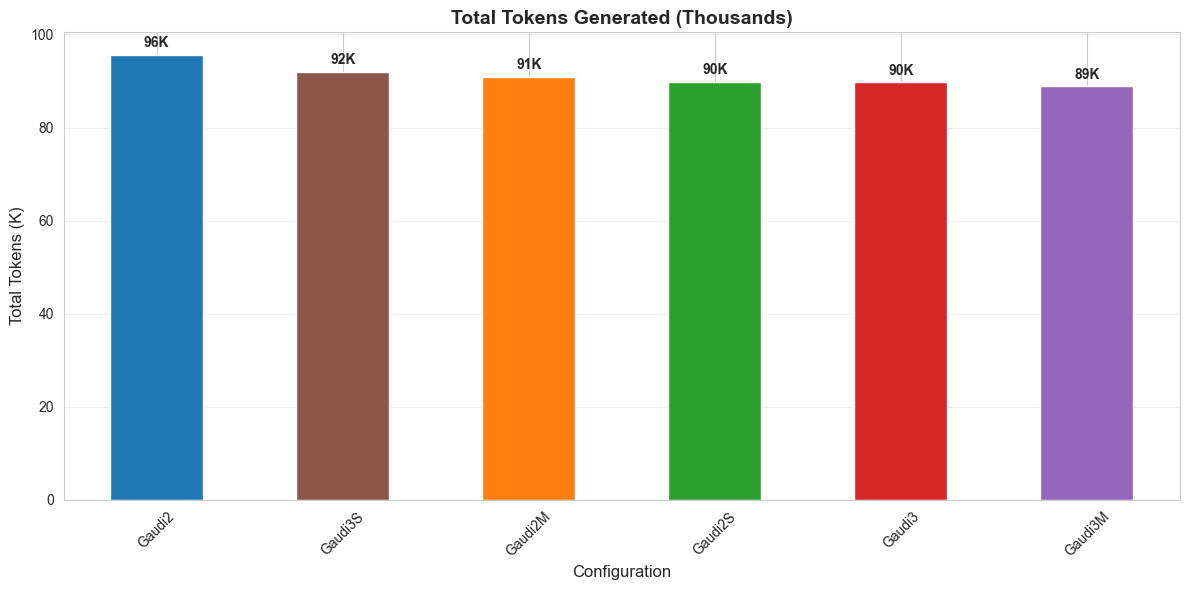

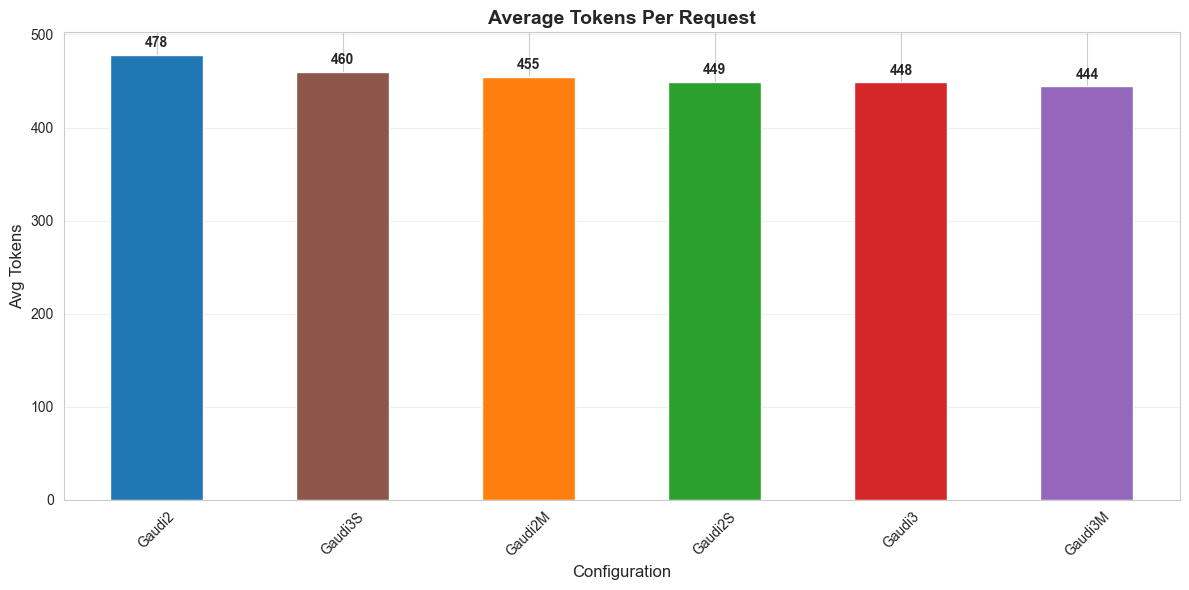

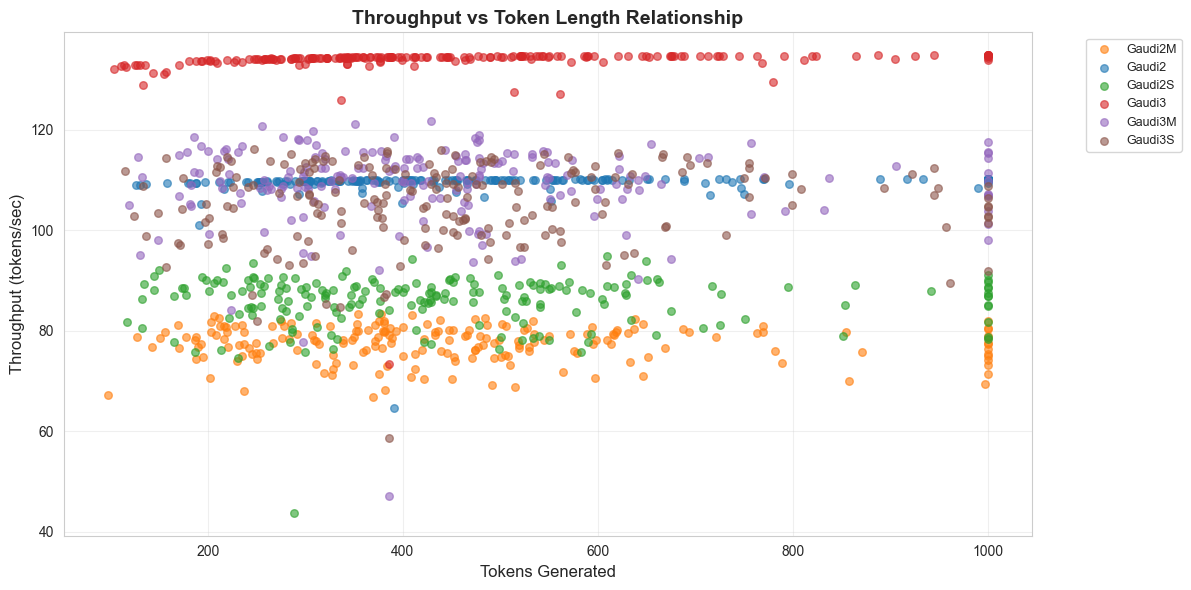

<Figure size 1200x600 with 0 Axes>

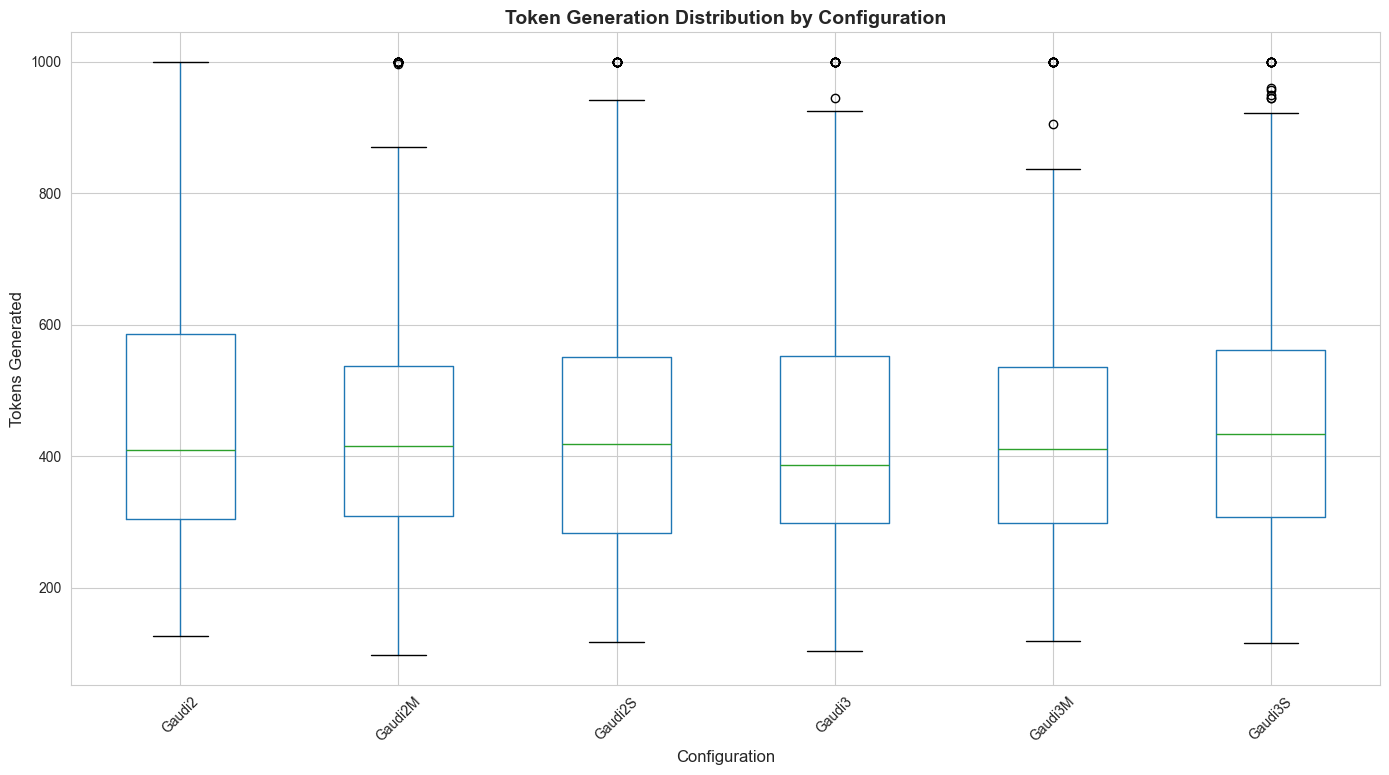


TOKEN GENERATION INSIGHTS
Total tokens across all configs: 546,932
Highest total tokens: Gaudi2 (95,676 tokens)
Highest average per request: Gaudi2 (478 tokens)

Correlation between token count and throughput: 0.009
→ Weak correlation: Token count has minimal impact on throughput


In [261]:
if 'benchmark_df' in locals():
    # 1. Total tokens generated by configuration
    plt.figure(figsize=(12, 6))
    total_tokens = benchmark_df.groupby('config')['tokens_generated'].sum().sort_values(ascending=False) / 1000  # in thousands
    colors = [config_colors.get(cfg, '#888888') for cfg in total_tokens.index]
    total_tokens.plot(kind='bar', color=colors)
    plt.title('Total Tokens Generated (Thousands)', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Total Tokens (K)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    for i, v in enumerate(total_tokens.values):
        plt.text(i, v + 1, f'{v:.0f}K', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 2. Average tokens per request
    plt.figure(figsize=(12, 6))
    avg_tokens = benchmark_df.groupby('config')['tokens_generated'].mean().sort_values(ascending=False)
    colors = [config_colors.get(cfg, '#888888') for cfg in avg_tokens.index]
    avg_tokens.plot(kind='bar', color=colors)
    plt.title('Average Tokens Per Request', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Avg Tokens', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    for i, v in enumerate(avg_tokens.values):
        plt.text(i, v + 5, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 3. Throughput vs Token Length
    plt.figure(figsize=(12, 6))
    for config in benchmark_df['config'].unique():
        data = benchmark_df[benchmark_df['config'] == config]
        plt.scatter(data['tokens_generated'], data['throughput'], 
                   label=config, alpha=0.6, s=30, color=config_colors.get(config, '#888888'))
    plt.title('Throughput vs Token Length Relationship', fontsize=14, fontweight='bold')
    plt.xlabel('Tokens Generated', fontsize=12)
    plt.ylabel('Throughput (tokens/sec)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 4. Token distribution
    plt.figure(figsize=(12, 6))
    benchmark_df.boxplot(column='tokens_generated', by='config')
    plt.title('Token Generation Distribution by Configuration', fontsize=14, fontweight='bold')
    plt.xlabel('Configuration', fontsize=12)
    plt.ylabel('Tokens Generated', fontsize=12)
    plt.xticks(rotation=45)
    plt.suptitle('')  # Remove default title
    plt.tight_layout()
    plt.show()
    
    # Print token generation insights
    print("\n" + "="*80)
    print("TOKEN GENERATION INSIGHTS")
    print("="*80)
    total_all = benchmark_df['tokens_generated'].sum()
    print(f"Total tokens across all configs: {total_all:,.0f}")
    print(f"Highest total tokens: {total_tokens.idxmax()} ({total_tokens.max()*1000:,.0f} tokens)")
    print(f"Highest average per request: {avg_tokens.idxmax()} ({avg_tokens.max():.0f} tokens)")
    
    # Calculate correlation
    corr = benchmark_df['tokens_generated'].corr(benchmark_df['throughput'])
    print(f"\nCorrelation between token count and throughput: {corr:.3f}")
    if abs(corr) < 0.3:
        print("→ Weak correlation: Token count has minimal impact on throughput")
    elif abs(corr) < 0.7:
        print("→ Moderate correlation: Token count has some impact on throughput")
    else:
        print("→ Strong correlation: Token count significantly impacts throughput")

## 15. Configuration Ranking & Scoring

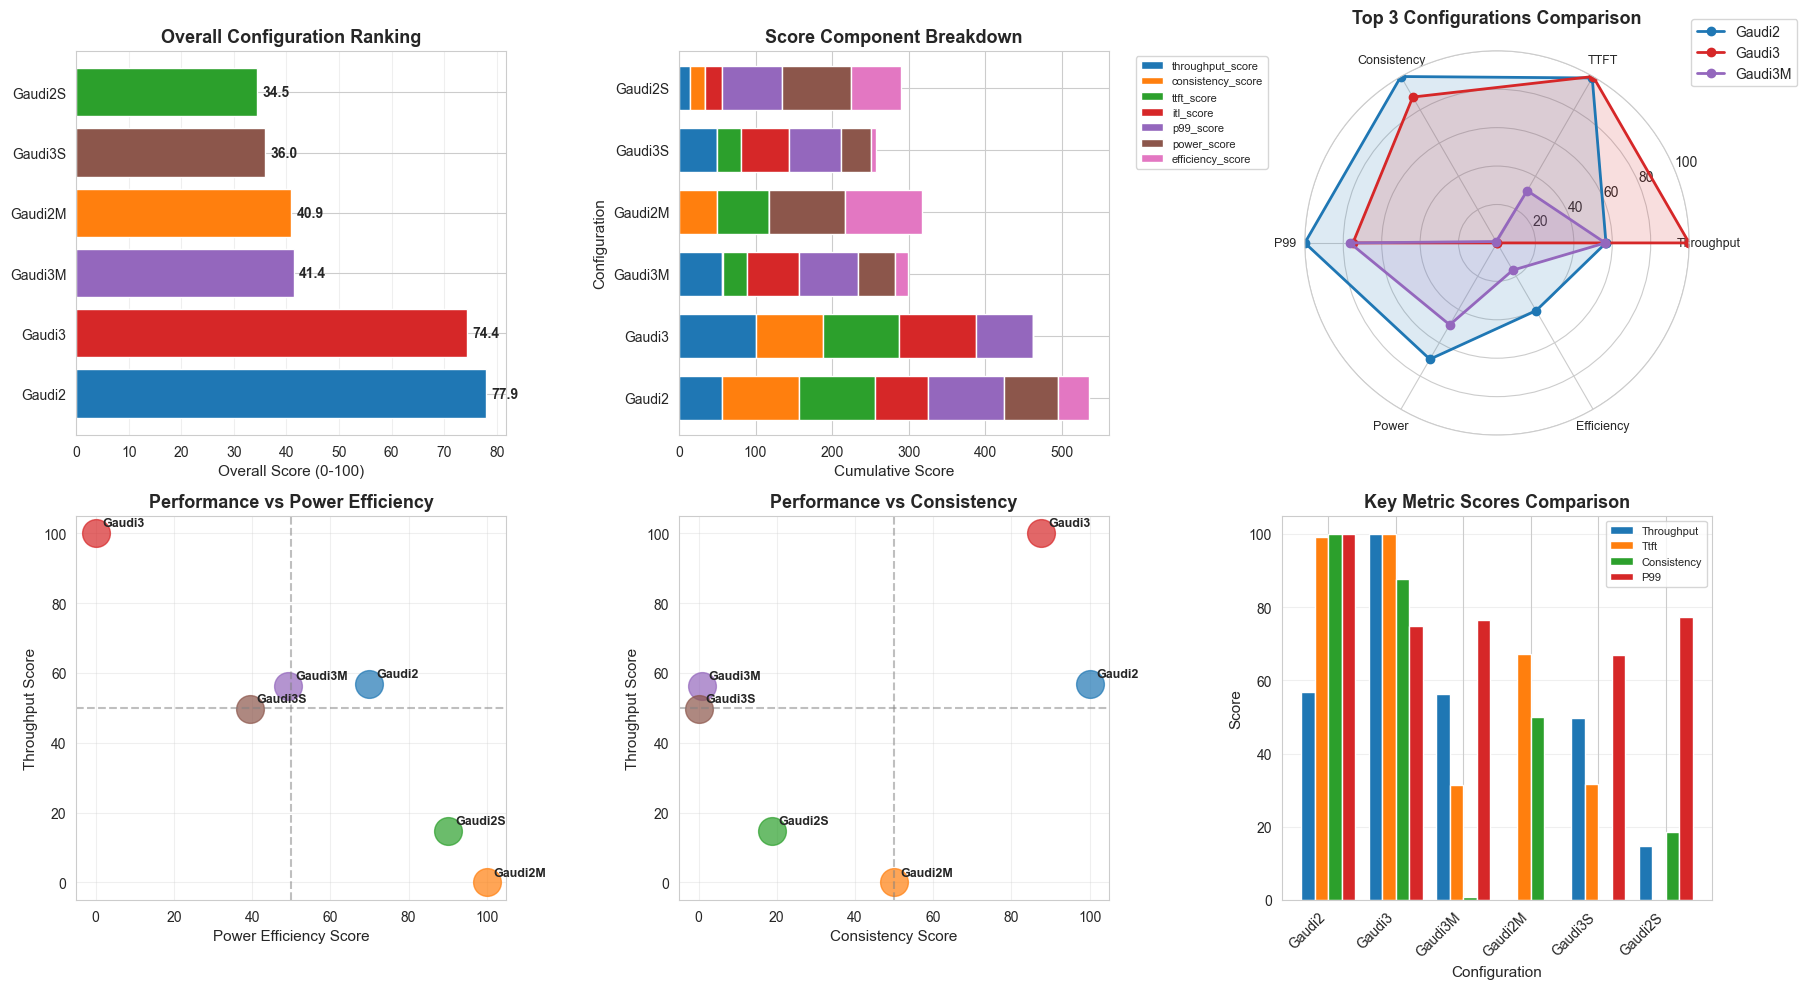


COMPREHENSIVE CONFIGURATION RANKING

Rank   Configuration   Overall Score   Category
--------------------------------------------------------------------------------
1      Gaudi2          77.9            🥇 Best Overall
2      Gaudi3          74.4            🥈 Runner-up
3      Gaudi3M         41.4            🥉 Third Place
4      Gaudi2M         40.9            Competitive
5      Gaudi3S         36.0            Competitive
6      Gaudi2S         34.5            Competitive

CATEGORY WINNERS
🚀 Best Throughput: Gaudi3 (100.0/100)
⚡ Best Responsiveness (TTFT): Gaudi3 (100.0/100)
📊 Most Consistent: Gaudi2 (100.0/100)
🎯 Best P99 Latency: Gaudi2 (100.0/100)
🔋 Best Power Efficiency: Gaudi2M (100.0/100)
💡 Best Overall Efficiency: Gaudi2M (100.0/100)


In [262]:
if 'benchmark_df' in locals() and 'power_df' in locals():
    # Create comprehensive ranking system
    from sklearn.preprocessing import MinMaxScaler
    
    # Calculate key metrics for each configuration
    ranking_data = {}
    
    for config in benchmark_df['config'].unique():
        bm_data = benchmark_df[benchmark_df['config'] == config]
        pw_data = power_df[power_df['config'] == config] if config in power_df['config'].values else None
        
        ranking_data[config] = {
            'mean_throughput': bm_data['throughput'].mean(),
            'mean_ttft': bm_data['ttft'].mean(),
            'mean_itl': bm_data['mean_itl'].mean(),
            'throughput_consistency': 100 / ((bm_data['throughput'].std() / bm_data['throughput'].mean() * 100) + 1),
            'p99_ttft': bm_data['ttft'].quantile(0.99),
            'mean_power': pw_data['power_w'].mean() if pw_data is not None else 0,
        }
    
    ranking_df = pd.DataFrame(ranking_data).T
    
    # Calculate composite scores (normalized 0-100)
    scaler = MinMaxScaler(feature_range=(0, 100))
    
    # For metrics where higher is better
    ranking_df['throughput_score'] = scaler.fit_transform(ranking_df[['mean_throughput']])
    ranking_df['consistency_score'] = scaler.fit_transform(ranking_df[['throughput_consistency']])
    
    # For metrics where lower is better (invert)
    ranking_df['ttft_score'] = 100 - scaler.fit_transform(ranking_df[['mean_ttft']])
    ranking_df['itl_score'] = 100 - scaler.fit_transform(ranking_df[['mean_itl']])
    ranking_df['p99_score'] = 100 - scaler.fit_transform(ranking_df[['p99_ttft']])
    
    if ranking_df['mean_power'].max() > 0:
        ranking_df['power_score'] = 100 - scaler.fit_transform(ranking_df[['mean_power']])
        ranking_df['efficiency_score'] = scaler.fit_transform((ranking_df['mean_throughput'] / ranking_df['mean_power']).values.reshape(-1, 1))
    
    # Calculate weighted overall score
    weights = {
        'throughput_score': 0.30,
        'ttft_score': 0.20,
        'consistency_score': 0.15,
        'p99_score': 0.15,
        'power_score': 0.10,
        'efficiency_score': 0.10
    }
    
    ranking_df['overall_score'] = sum(ranking_df[metric] * weight for metric, weight in weights.items() if metric in ranking_df.columns)
    ranking_df = ranking_df.sort_values('overall_score', ascending=False)
    
    # Visualizations
    fig = plt.figure(figsize=(18, 10))
    
    # 1. Overall Ranking
    ax1 = plt.subplot(2, 3, 1)
    colors = [config_colors.get(cfg, '#888888') for cfg in ranking_df.index]
    ax1.barh(range(len(ranking_df)), ranking_df['overall_score'], color=colors)
    ax1.set_yticks(range(len(ranking_df)))
    ax1.set_yticklabels(ranking_df.index)
    ax1.set_xlabel('Overall Score (0-100)', fontsize=11)
    ax1.set_title('Overall Configuration Ranking', fontsize=13, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    for i, (idx, row) in enumerate(ranking_df.iterrows()):
        ax1.text(row['overall_score'] + 1, i, f"{row['overall_score']:.1f}", va='center', fontweight='bold')
    
    # 2. Score breakdown stacked bar
    ax2 = plt.subplot(2, 3, 2)
    score_cols = [col for col in ranking_df.columns if col.endswith('_score') and col != 'overall_score']
    ranking_df[score_cols].plot(kind='barh', stacked=True, ax=ax2, width=0.7)
    ax2.set_ylabel('Configuration', fontsize=11)
    ax2.set_xlabel('Cumulative Score', fontsize=11)
    ax2.set_title('Score Component Breakdown', fontsize=13, fontweight='bold')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    # 3. Radar chart for top 3 configs
    ax3 = plt.subplot(2, 3, 3, projection='polar')
    top3_configs = ranking_df.head(3).index
    categories = ['Throughput', 'TTFT', 'Consistency', 'P99', 'Power', 'Efficiency']
    score_metrics = ['throughput_score', 'ttft_score', 'consistency_score', 'p99_score', 'power_score', 'efficiency_score']
    
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    
    for config in top3_configs:
        values = [ranking_df.loc[config, metric] for metric in score_metrics if metric in ranking_df.columns]
        values += values[:1]
        ax3.plot(angles[:len(values)], values, 'o-', linewidth=2, label=config, color=config_colors.get(config, '#888888'))
        ax3.fill(angles[:len(values)], values, alpha=0.15, color=config_colors.get(config, '#888888'))
    
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(categories, fontsize=9)
    ax3.set_ylim(0, 100)
    ax3.set_title('Top 3 Configurations Comparison', fontsize=13, fontweight='bold', pad=20)
    ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax3.grid(True)
    
    # 4. Performance vs Efficiency scatter
    ax4 = plt.subplot(2, 3, 4)
    for config in ranking_df.index:
        ax4.scatter(ranking_df.loc[config, 'power_score'], 
                   ranking_df.loc[config, 'throughput_score'],
                   s=400, alpha=0.7, color=config_colors.get(config, '#888888'))
        ax4.annotate(config, 
                    (ranking_df.loc[config, 'power_score'], ranking_df.loc[config, 'throughput_score']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
    ax4.set_xlabel('Power Efficiency Score', fontsize=11)
    ax4.set_ylabel('Throughput Score', fontsize=11)
    ax4.set_title('Performance vs Power Efficiency', fontsize=13, fontweight='bold')
    ax4.grid(alpha=0.3)
    ax4.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
    ax4.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
    
    # 5. Consistency vs Performance
    ax5 = plt.subplot(2, 3, 5)
    for config in ranking_df.index:
        ax5.scatter(ranking_df.loc[config, 'consistency_score'], 
                   ranking_df.loc[config, 'throughput_score'],
                   s=400, alpha=0.7, color=config_colors.get(config, '#888888'))
        ax5.annotate(config, 
                    (ranking_df.loc[config, 'consistency_score'], ranking_df.loc[config, 'throughput_score']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
    ax5.set_xlabel('Consistency Score', fontsize=11)
    ax5.set_ylabel('Throughput Score', fontsize=11)
    ax5.set_title('Performance vs Consistency', fontsize=13, fontweight='bold')
    ax5.grid(alpha=0.3)
    ax5.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
    ax5.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
    
    # 6. Rank distribution
    ax6 = plt.subplot(2, 3, 6)
    rank_data = ranking_df[['throughput_score', 'ttft_score', 'consistency_score', 'p99_score']].head(6)
    x = np.arange(len(rank_data))
    width = 0.2
    
    for i, col in enumerate(['throughput_score', 'ttft_score', 'consistency_score', 'p99_score']):
        ax6.bar(x + i*width, rank_data[col], width, label=col.replace('_score', '').title())
    
    ax6.set_xlabel('Configuration', fontsize=11)
    ax6.set_ylabel('Score', fontsize=11)
    ax6.set_title('Key Metric Scores Comparison', fontsize=13, fontweight='bold')
    ax6.set_xticks(x + width * 1.5)
    ax6.set_xticklabels(rank_data.index, rotation=45, ha='right')
    ax6.legend(fontsize=8)
    ax6.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print ranking summary
    print("\n" + "="*80)
    print("COMPREHENSIVE CONFIGURATION RANKING")
    print("="*80)
    print(f"\n{'Rank':<6} {'Configuration':<15} {'Overall Score':<15} {'Category'}")
    print("-" * 80)
    for rank, (config, row) in enumerate(ranking_df.iterrows(), 1):
        if rank == 1:
            category = "🥇 Best Overall"
        elif rank == 2:
            category = "🥈 Runner-up"
        elif rank == 3:
            category = "🥉 Third Place"
        else:
            category = "Competitive"
        print(f"{rank:<6} {config:<15} {row['overall_score']:<15.1f} {category}")
    
    print("\n" + "="*80)
    print("CATEGORY WINNERS")
    print("="*80)
    print(f"🚀 Best Throughput: {ranking_df['throughput_score'].idxmax()} ({ranking_df['throughput_score'].max():.1f}/100)")
    print(f"⚡ Best Responsiveness (TTFT): {ranking_df['ttft_score'].idxmax()} ({ranking_df['ttft_score'].max():.1f}/100)")
    print(f"📊 Most Consistent: {ranking_df['consistency_score'].idxmax()} ({ranking_df['consistency_score'].max():.1f}/100)")
    print(f"🎯 Best P99 Latency: {ranking_df['p99_score'].idxmax()} ({ranking_df['p99_score'].max():.1f}/100)")
    if 'power_score' in ranking_df.columns:
        print(f"🔋 Best Power Efficiency: {ranking_df['power_score'].idxmax()} ({ranking_df['power_score'].max():.1f}/100)")
        print(f"💡 Best Overall Efficiency: {ranking_df['efficiency_score'].idxmax()} ({ranking_df['efficiency_score'].max():.1f}/100)")

## 16. Power Consumption Patterns & Insights

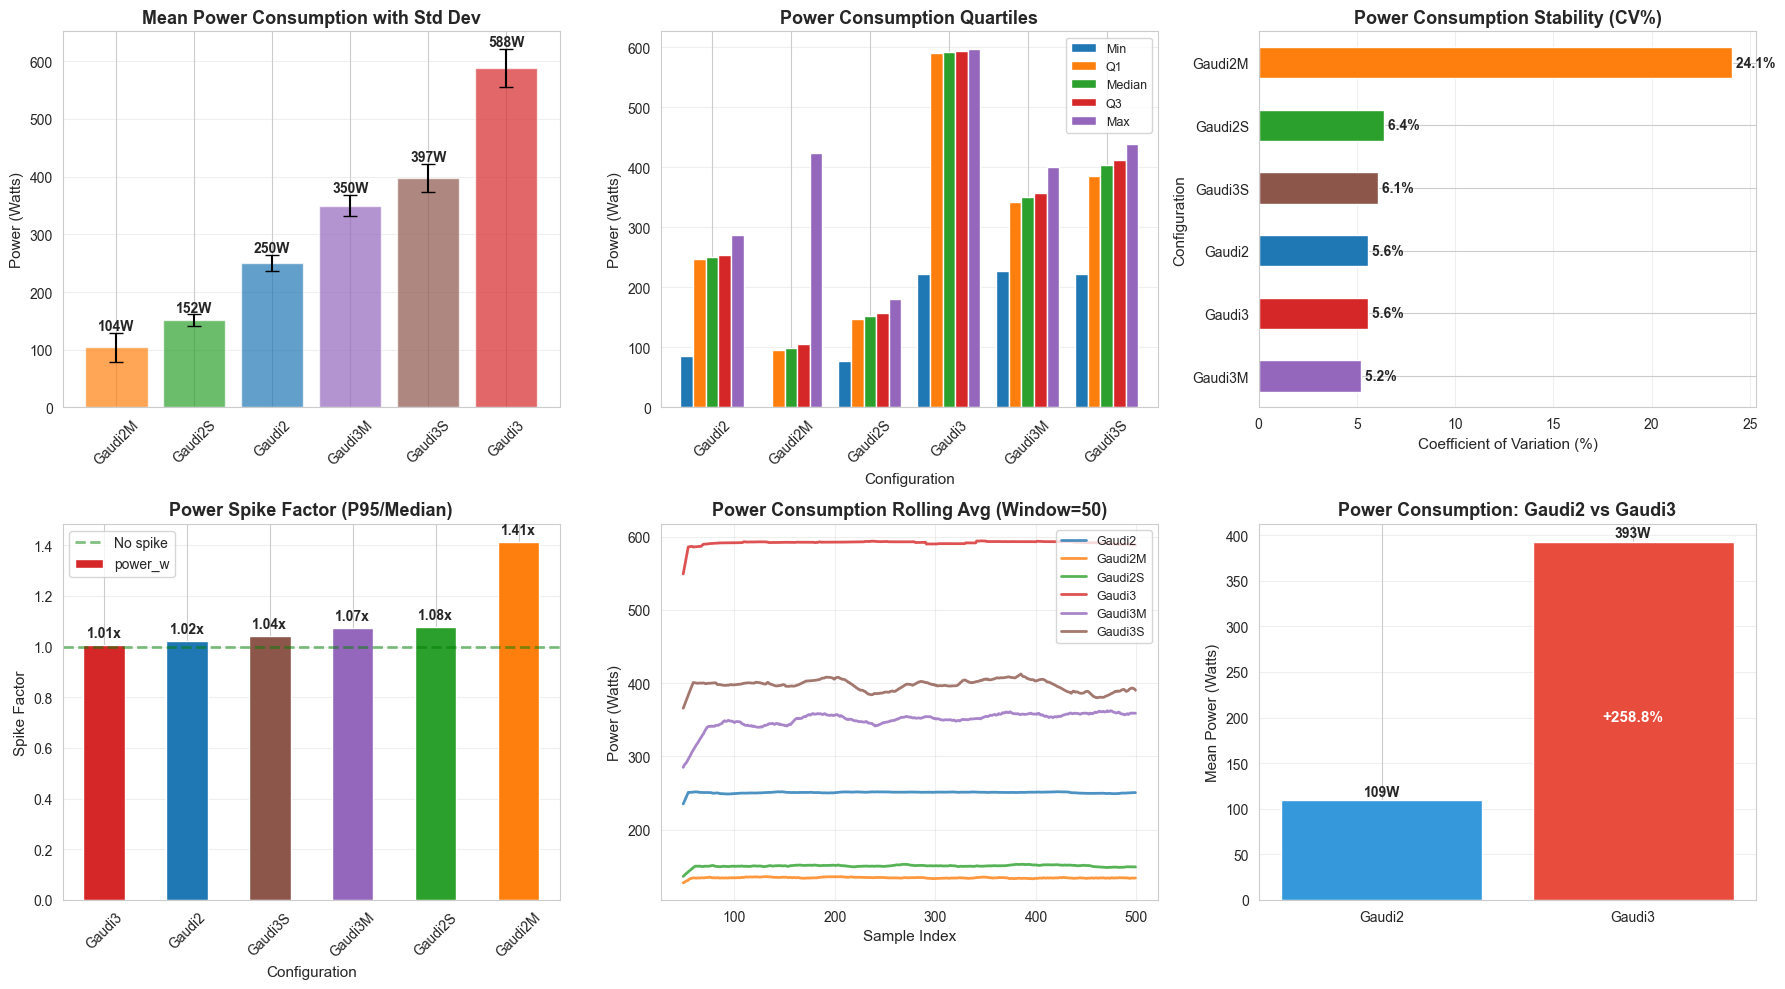


POWER CONSUMPTION INSIGHTS
Most power efficient: Gaudi2M (104W avg)
Highest power consumption: Gaudi3 (588W avg)

Most stable power: Gaudi3M (CV: 5.2%)
Most variable power: Gaudi2M (CV: 24.1%)

Lowest power spikes: Gaudi3 (P95/Median: 1.01x)
Highest power spikes: Gaudi2M (P95/Median: 1.41x)

🔋 Generation comparison: Gaudi3 uses +258.8% power vs Gaudi2


In [263]:
if 'power_df' in locals():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # 1. Power efficiency ratio (comparing generations)
    ax1 = axes[0, 0]
    power_stats = power_df.groupby('config')['power_w'].agg(['mean', 'std']).sort_values('mean')
    colors = [config_colors.get(cfg, '#888888') for cfg in power_stats.index]
    ax1.bar(range(len(power_stats)), power_stats['mean'], yerr=power_stats['std'], 
            color=colors, alpha=0.7, capsize=5)
    ax1.set_xticks(range(len(power_stats)))
    ax1.set_xticklabels(power_stats.index, rotation=45)
    ax1.set_ylabel('Power (Watts)', fontsize=11)
    ax1.set_title('Mean Power Consumption with Std Dev', fontsize=13, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    for i, (idx, row) in enumerate(power_stats.iterrows()):
        ax1.text(i, row['mean'] + row['std'] + 5, f"{row['mean']:.0f}W", ha='center', fontweight='bold')
    
    # 2. Power percentiles
    ax2 = axes[0, 1]
    power_percentiles = {}
    for config in power_df['config'].unique():
        data = power_df[power_df['config'] == config]['power_w']
        power_percentiles[config] = [data.min(), data.quantile(0.25), data.median(), 
                                      data.quantile(0.75), data.max()]
    
    power_perc_df = pd.DataFrame(power_percentiles, 
                                  index=['Min', 'Q1', 'Median', 'Q3', 'Max']).T
    power_perc_df.plot(kind='bar', ax=ax2, width=0.8)
    ax2.set_title('Power Consumption Quartiles', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Configuration', fontsize=11)
    ax2.set_ylabel('Power (Watts)', fontsize=11)
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Power stability (coefficient of variation)
    ax3 = axes[0, 2]
    power_cv = power_df.groupby('config')['power_w'].apply(lambda x: (x.std() / x.mean()) * 100).sort_values()
    colors = [config_colors.get(cfg, '#888888') for cfg in power_cv.index]
    power_cv.plot(kind='barh', ax=ax3, color=colors)
    ax3.set_title('Power Consumption Stability (CV%)', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Coefficient of Variation (%)', fontsize=11)
    ax3.set_ylabel('Configuration', fontsize=11)
    ax3.grid(axis='x', alpha=0.3)
    for i, v in enumerate(power_cv.values):
        ax3.text(v, i, f' {v:.1f}%', va='center', fontweight='bold')
    
    # 4. Power spike analysis (95th percentile / median ratio)
    ax4 = axes[1, 0]
    power_spike = power_df.groupby('config')['power_w'].apply(
        lambda x: x.quantile(0.95) / x.median()).sort_values()
    colors = [config_colors.get(cfg, '#888888') for cfg in power_spike.index]
    power_spike.plot(kind='bar', ax=ax4, color=colors)
    ax4.set_title('Power Spike Factor (P95/Median)', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Configuration', fontsize=11)
    ax4.set_ylabel('Spike Factor', fontsize=11)
    ax4.tick_params(axis='x', rotation=45)
    ax4.axhline(y=1.0, color='green', linestyle='--', linewidth=2, alpha=0.5, label='No spike')
    ax4.grid(axis='y', alpha=0.3)
    ax4.legend()
    for i, v in enumerate(power_spike.values):
        ax4.text(i, v + 0.02, f'{v:.2f}x', ha='center', va='bottom', fontweight='bold')
    
    # 5. Rolling average power consumption
    ax5 = axes[1, 1]
    window = 50
    for config in sorted(power_df['config'].unique()):
        data = power_df[power_df['config'] == config]['power_w'].head(500)
        rolling_avg = data.rolling(window=window).mean()
        ax5.plot(rolling_avg.values, label=config, alpha=0.8, linewidth=2, 
                color=config_colors.get(config, '#888888'))
    ax5.set_title(f'Power Consumption Rolling Avg (Window={window})', fontsize=13, fontweight='bold')
    ax5.set_xlabel('Sample Index', fontsize=11)
    ax5.set_ylabel('Power (Watts)', fontsize=11)
    ax5.legend(fontsize=9)
    ax5.grid(alpha=0.3)
    
    # 6. Gaudi generation comparison
    ax6 = axes[1, 2]
    # Group by generation (Gaudi2 vs Gaudi3)
    power_df['generation'] = power_df['config'].apply(lambda x: 'Gaudi3' if 'Gaudi3' in x else 'Gaudi2')
    gen_comparison = power_df.groupby('generation')['power_w'].mean()
    colors_gen = {'Gaudi2': '#3498db', 'Gaudi3': '#e74c3c'}
    ax6.bar(range(len(gen_comparison)), gen_comparison.values, 
           color=[colors_gen.get(g, '#888888') for g in gen_comparison.index])
    ax6.set_xticks(range(len(gen_comparison)))
    ax6.set_xticklabels(gen_comparison.index)
    ax6.set_ylabel('Mean Power (Watts)', fontsize=11)
    ax6.set_title('Power Consumption: Gaudi2 vs Gaudi3', fontsize=13, fontweight='bold')
    ax6.grid(axis='y', alpha=0.3)
    for i, v in enumerate(gen_comparison.values):
        ax6.text(i, v + 5, f'{v:.0f}W', ha='center', fontweight='bold')
        if i > 0:
            diff = ((v - gen_comparison.values[0]) / gen_comparison.values[0]) * 100
            ax6.text(i, v/2, f'{diff:+.1f}%', ha='center', fontsize=11, fontweight='bold', color='white')
    
    plt.tight_layout()
    plt.show()
    
    # Print power insights
    print("\n" + "="*80)
    print("POWER CONSUMPTION INSIGHTS")
    print("="*80)
    print(f"Most power efficient: {power_stats['mean'].idxmin()} ({power_stats['mean'].min():.0f}W avg)")
    print(f"Highest power consumption: {power_stats['mean'].idxmax()} ({power_stats['mean'].max():.0f}W avg)")
    print(f"\nMost stable power: {power_cv.idxmin()} (CV: {power_cv.min():.1f}%)")
    print(f"Most variable power: {power_cv.idxmax()} (CV: {power_cv.max():.1f}%)")
    print(f"\nLowest power spikes: {power_spike.idxmin()} (P95/Median: {power_spike.min():.2f}x)")
    print(f"Highest power spikes: {power_spike.idxmax()} (P95/Median: {power_spike.max():.2f}x)")
    
    if len(gen_comparison) > 1:
        diff_pct = ((gen_comparison.iloc[1] - gen_comparison.iloc[0]) / gen_comparison.iloc[0]) * 100
        print(f"\n🔋 Generation comparison: Gaudi3 uses {diff_pct:+.1f}% power vs Gaudi2")

## 17. Final Recommendations & Conclusions

In [264]:
if 'benchmark_df' in locals() and 'power_df' in locals():
    print("\n" + "="*100)
    print(" " * 35 + "FINAL RECOMMENDATIONS & CONCLUSIONS")
    print("="*100)
    
    # Gather all key insights
    best_throughput = benchmark_df.groupby('config')['throughput'].mean().idxmax()
    best_ttft = benchmark_df.groupby('config')['ttft'].mean().idxmin()
    best_power = power_df.groupby('config')['power_w'].mean().idxmin()
    
    if 'efficiency_df' in locals():
        best_efficiency = efficiency_df['tokens_per_watt'].idxmax()
    
    if 'ranking_df' in locals():
        best_overall = ranking_df['overall_score'].idxmax()
        most_consistent = ranking_df['consistency_score'].idxmax()
    
    # Use case recommendations
    print("\n📋 USE CASE RECOMMENDATIONS:")
    print("-" * 100)
    
    print("\n1️⃣  HIGH-THROUGHPUT BATCH PROCESSING:")
    print(f"   → Recommended: {best_throughput}")
    throughput_val = benchmark_df[benchmark_df['config'] == best_throughput]['throughput'].mean()
    print(f"   → Performance: {throughput_val:.2f} tokens/sec average")
    print(f"   → Best for: Large-scale inference, batch jobs, offline processing")
    
    print("\n2️⃣  LOW-LATENCY REAL-TIME APPLICATIONS:")
    print(f"   → Recommended: {best_ttft}")
    ttft_val = benchmark_df[benchmark_df['config'] == best_ttft]['ttft'].mean()
    print(f"   → Performance: {ttft_val:.4f} sec TTFT average")
    print(f"   → Best for: Chatbots, interactive AI, streaming responses")
    
    if 'best_efficiency' in locals():
        print("\n3️⃣  COST-OPTIMIZED DEPLOYMENT:")
        print(f"   → Recommended: {best_efficiency}")
        eff_val = efficiency_df[efficiency_df.index == best_efficiency]['tokens_per_watt'].values[0]
        print(f"   → Efficiency: {eff_val:.2f} tokens/watt")
        print(f"   → Best for: Long-running services, budget-conscious deployments")
    
    print("\n4️⃣  POWER-CONSTRAINED ENVIRONMENTS:")
    print(f"   → Recommended: {best_power}")
    power_val = power_df[power_df['config'] == best_power]['power_w'].mean()
    print(f"   → Power consumption: {power_val:.0f}W average")
    print(f"   → Best for: Edge deployment, data centers with power limits")
    
    if 'best_overall' in locals():
        print("\n5️⃣  BALANCED PRODUCTION WORKLOAD:")
        print(f"   → Recommended: {best_overall}")
        overall_score = ranking_df.loc[best_overall, 'overall_score']
        print(f"   → Overall score: {overall_score:.1f}/100")
        print(f"   → Best for: General-purpose deployment, mixed workloads")
    
    if 'most_consistent' in locals() and most_consistent != best_overall:
        print("\n6️⃣  PREDICTABLE SLA REQUIREMENTS:")
        print(f"   → Recommended: {most_consistent}")
        consistency_val = ranking_df.loc[most_consistent, 'consistency_score']
        print(f"   → Consistency score: {consistency_val:.1f}/100")
        print(f"   → Best for: Enterprise SLA commitments, guaranteed performance")
    
    # Multiprocessing insights
    if 'alpaca_combined' in locals():
        print("\n\n⚙️  MULTIPROCESSING INSIGHTS:")
        print("-" * 100)
        avg_8 = alpaca_8_df['throughput'].mean()
        avg_16 = alpaca_16_df['throughput'].mean()
        speedup = avg_16 / avg_8
        print(f"   • 8-proc average throughput: {avg_8:.2f} tokens/sec")
        print(f"   • 16-proc average throughput: {avg_16:.2f} tokens/sec")
        print(f"   • Speedup factor: {speedup:.2f}x")
        
        if speedup > 1.5:
            print(f"   ✅ Recommendation: 16-proc provides significant {speedup:.2f}x speedup - worth the overhead")
        elif speedup > 1.2:
            print(f"   ⚠️  Recommendation: 16-proc provides moderate {speedup:.2f}x speedup - consider workload")
        else:
            print(f"   ❌ Recommendation: 16-proc provides minimal {speedup:.2f}x speedup - stick with 8-proc")
    
    # Key takeaways
    print("\n\n🔑 KEY TAKEAWAYS:")
    print("-" * 100)
    
    throughput_range = benchmark_df.groupby('config')['throughput'].mean()
    perf_diff = ((throughput_range.max() - throughput_range.min()) / throughput_range.min()) * 100
    print(f"   1. Performance varies by {perf_diff:.1f}% across configurations")
    
    if 'power_df' in locals():
        power_range = power_df.groupby('config')['power_w'].mean()
        power_diff = ((power_range.max() - power_range.min()) / power_range.min()) * 100
        print(f"   2. Power consumption varies by {power_diff:.1f}% across configurations")
    
    ttft_range = benchmark_df.groupby('config')['ttft'].mean()
    best_worst_ttft = (ttft_range.max() / ttft_range.min())
    print(f"   3. TTFT varies by {best_worst_ttft:.1f}x between best and worst configurations")
    
    if 'cv_throughput' in locals():
        avg_cv = cv_throughput.mean()
        print(f"   4. Average performance consistency (CV): {avg_cv:.1f}%")
        if avg_cv < 5:
            print(f"      → Excellent: All configurations show very stable performance")
        elif avg_cv < 10:
            print(f"      → Good: Configurations show acceptable stability")
        else:
            print(f"      → Variable: Consider workload characteristics")
    
    print(f"\n   5. Gaudi3 vs Gaudi2 comparison:")
    gaudi3_throughput = benchmark_df[benchmark_df['config'].str.contains('Gaudi3')]['throughput'].mean()
    gaudi2_throughput = benchmark_df[benchmark_df['config'].str.contains('Gaudi2')]['throughput'].mean()
    gen_improvement = ((gaudi3_throughput - gaudi2_throughput) / gaudi2_throughput) * 100
    print(f"      → Performance improvement: {gen_improvement:+.1f}%")
    
    if 'power_df' in locals():
        gaudi3_power = power_df[power_df['config'].str.contains('Gaudi3')]['power_w'].mean()
        gaudi2_power = power_df[power_df['config'].str.contains('Gaudi2')]['power_w'].mean()
        power_change = ((gaudi3_power - gaudi2_power) / gaudi2_power) * 100
        print(f"      → Power change: {power_change:+.1f}%")
        
        if gen_improvement > 0 and power_change < gen_improvement:
            print(f"      ✅ Gaudi3 offers better performance-per-watt ratio")
        elif gen_improvement > 0:
            print(f"      ⚠️  Gaudi3 is faster but uses proportionally more power")
    
    # Migration recommendations
    print("\n\n🚀 MIGRATION/UPGRADE RECOMMENDATIONS:")
    print("-" * 100)
    
    if 'ranking_df' in locals():
        top3 = ranking_df.head(3).index.tolist()
        print(f"   • Top 3 overall configurations: {', '.join(top3)}")
        print(f"   • Consider these for new deployments or upgrades")
        
        if any('Gaudi3' in cfg for cfg in top3):
            print(f"   • ✅ Gaudi3 variants dominate top rankings - recommended for new hardware")
        
        if any('Gaudi2' in cfg for cfg in top3):
            gaudi2_top = [cfg for cfg in top3 if 'Gaudi2' in cfg][0]
            print(f"   • 💰 {gaudi2_top} remains competitive - good for cost-sensitive upgrades")
    
    print("\n\n" + "="*100)
    print(" " * 40 + "END OF ANALYSIS")
    print("="*100)


                                   FINAL RECOMMENDATIONS & CONCLUSIONS

📋 USE CASE RECOMMENDATIONS:
----------------------------------------------------------------------------------------------------

1️⃣  HIGH-THROUGHPUT BATCH PROCESSING:
   → Recommended: Gaudi3
   → Performance: 133.68 tokens/sec average
   → Best for: Large-scale inference, batch jobs, offline processing

2️⃣  LOW-LATENCY REAL-TIME APPLICATIONS:
   → Recommended: Gaudi3
   → Performance: 0.0378 sec TTFT average
   → Best for: Chatbots, interactive AI, streaming responses

3️⃣  COST-OPTIMIZED DEPLOYMENT:
   → Recommended: 1
   → Efficiency: 0.74 tokens/watt
   → Best for: Long-running services, budget-conscious deployments

4️⃣  POWER-CONSTRAINED ENVIRONMENTS:
   → Recommended: Gaudi2M
   → Power consumption: 104W average
   → Best for: Edge deployment, data centers with power limits

5️⃣  BALANCED PRODUCTION WORKLOAD:
   → Recommended: Gaudi2
   → Overall score: 77.9/100
   → Best for: General-purpose deployment,

## 18. Complete Batch Configuration Analysis (Normal vs 8-Batch vs 16-Batch)

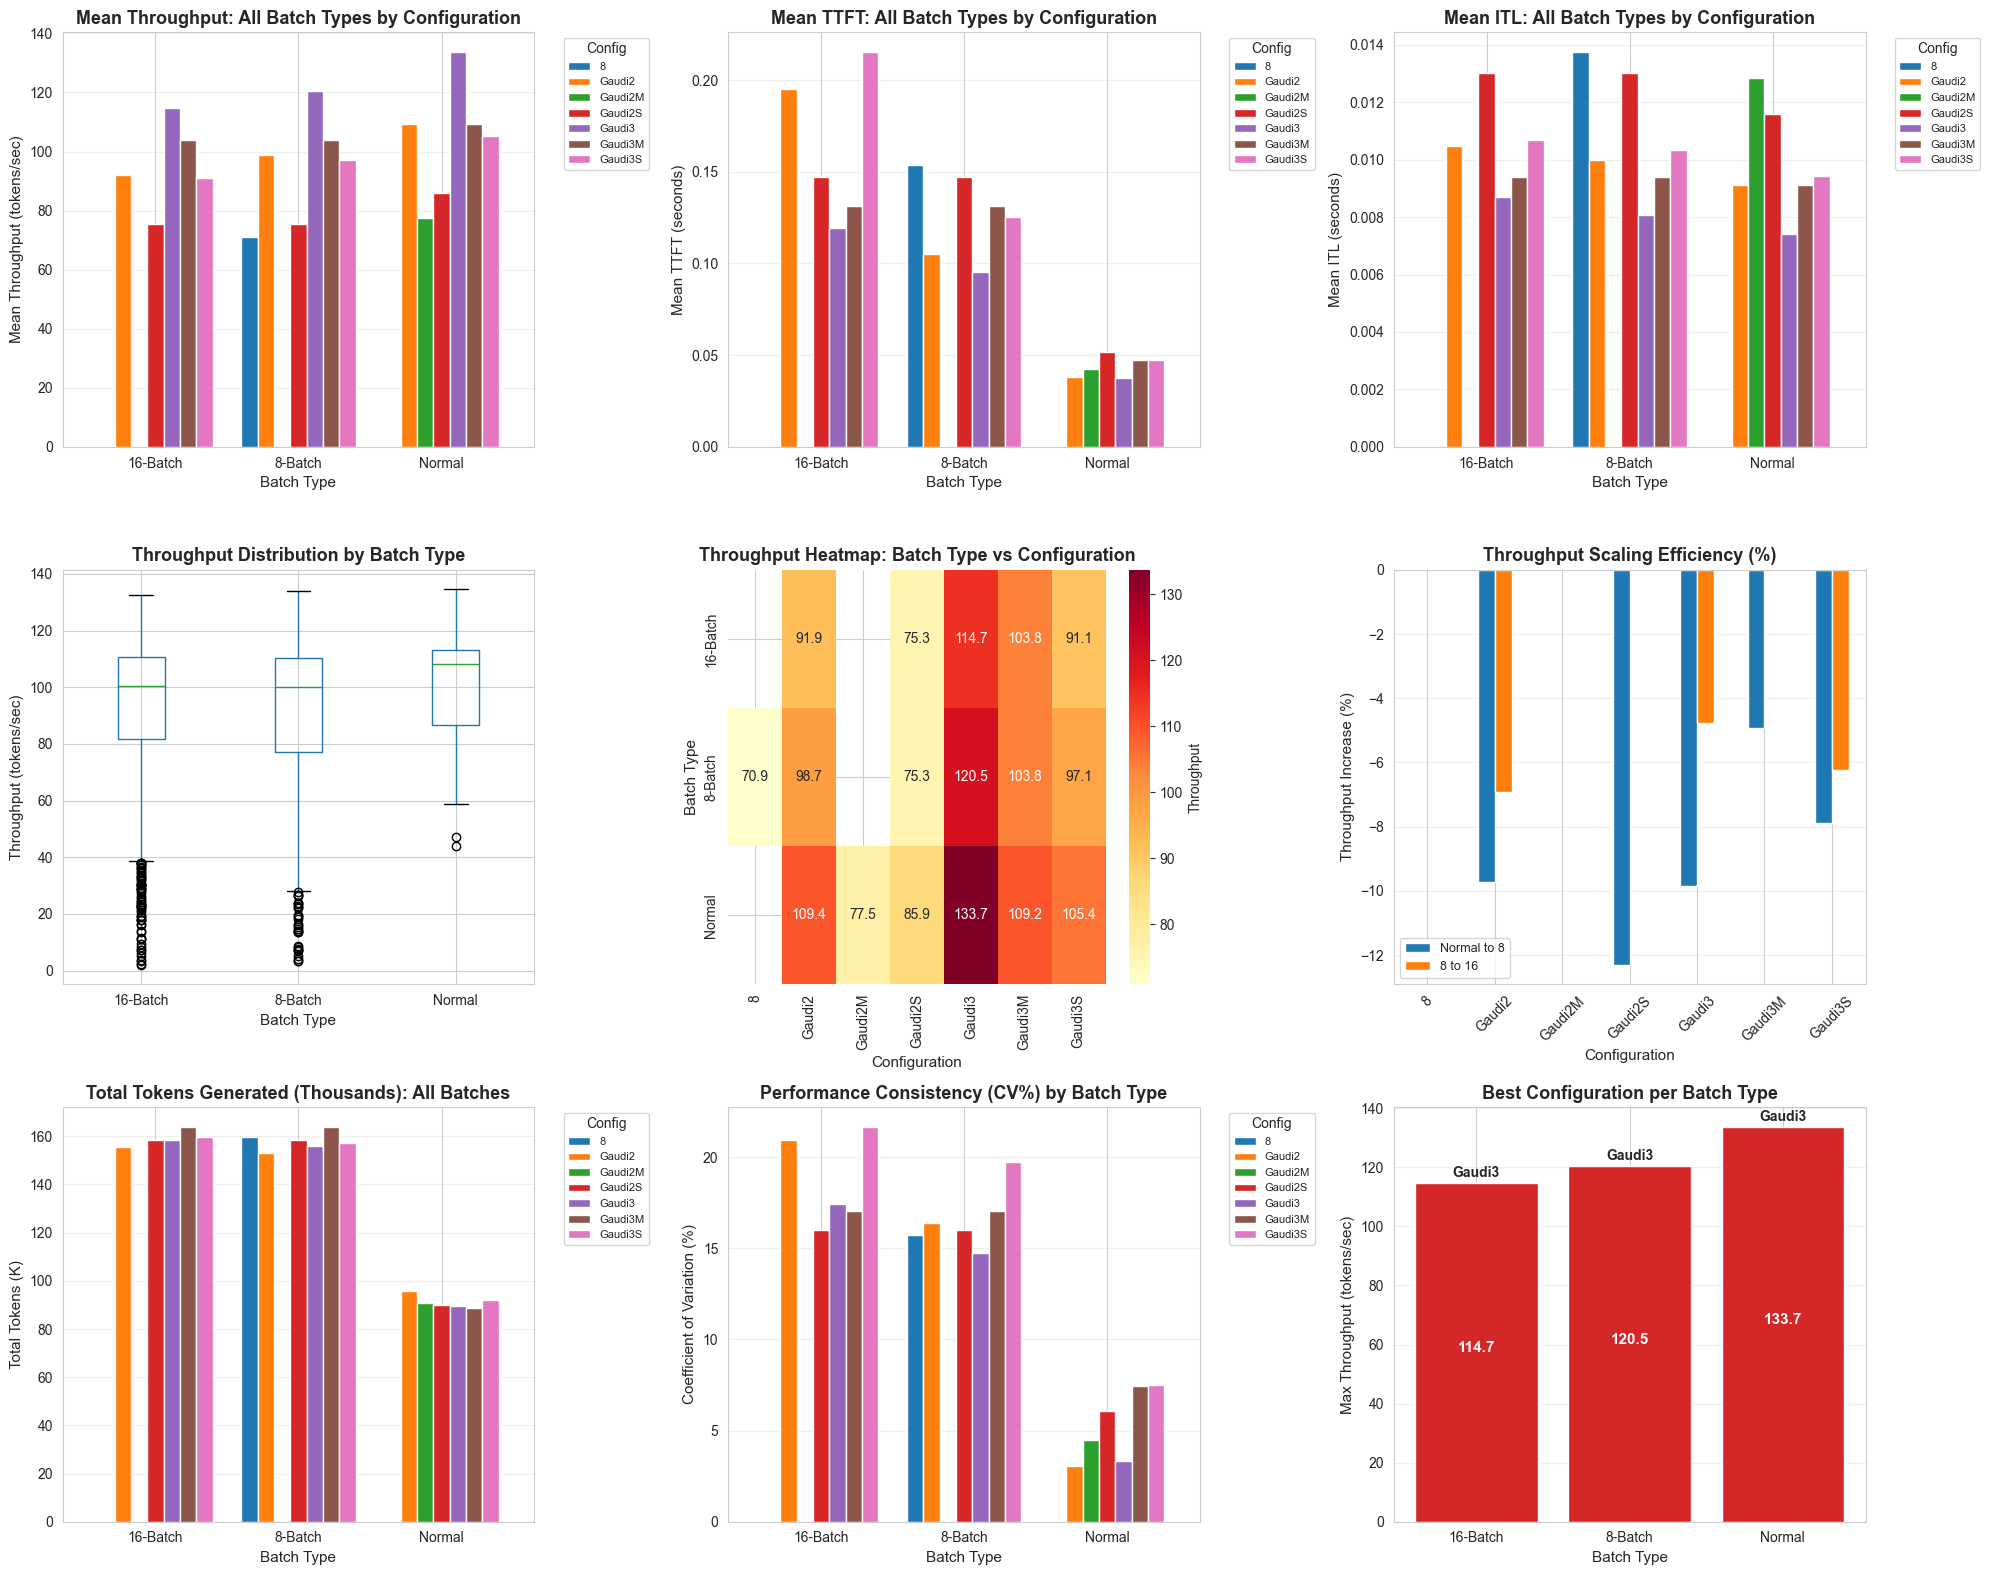


                                   BATCH CONFIGURATION ANALYSIS

📊 NORMAL BATCH:
  • Sample size: 1200 requests
  • Avg throughput: 103.50 tokens/sec
  • Avg TTFT: 0.0440 sec
  • Avg ITL: 0.009919 sec
  • Total tokens: 546,932
  • Best config: Gaudi3

📊 8-BATCH BATCH:
  • Sample size: 3120 requests
  • Avg throughput: 94.39 tokens/sec
  • Avg TTFT: 0.1263 sec
  • Avg ITL: 0.010759 sec
  • Total tokens: 948,554
  • Best config: Gaudi3

📊 16-BATCH BATCH:
  • Sample size: 2600 requests
  • Avg throughput: 95.36 tokens/sec
  • Avg TTFT: 0.1616 sec
  • Avg ITL: 0.010450 sec
  • Total tokens: 796,336
  • Best config: Gaudi3

SCALING ANALYSIS:
8               → Normal to 16-Batch: +nan% (nan → nan tokens/sec)
Gaudi2          → Normal to 16-Batch: -16.0% (109.4 → 91.9 tokens/sec)
Gaudi2M         → Normal to 16-Batch: +nan% (77.5 → nan tokens/sec)
Gaudi2S         → Normal to 16-Batch: -12.3% (85.9 → 75.3 tokens/sec)
Gaudi3          → Normal to 16-Batch: -14.2% (133.7 → 114.7 tokens/sec)
Gaudi3

In [265]:
# Comprehensive analysis across all batch configurations
if 'benchmark_df' in locals() and 'alpaca_8_df' in locals() and 'alpaca_16_df' in locals():
    # Tag each dataset with batch type
    benchmark_df_tagged = benchmark_df.copy()
    benchmark_df_tagged['batch_type'] = 'Normal'
    
    alpaca_8_tagged = alpaca_8_df.copy()
    alpaca_8_tagged['batch_type'] = '8-Batch'
    
    alpaca_16_tagged = alpaca_16_df.copy()
    alpaca_16_tagged['batch_type'] = '16-Batch'
    
    # Combine all datasets
    all_batches_df = pd.concat([benchmark_df_tagged, alpaca_8_tagged, alpaca_16_tagged], ignore_index=True)
    
    fig, axes = plt.subplots(3, 3, figsize=(20, 16))
    
    # 1. Throughput comparison across all batches
    ax1 = axes[0, 0]
    throughput_batch_config = all_batches_df.groupby(['batch_type', 'config'])['throughput'].mean().unstack()
    throughput_batch_config.plot(kind='bar', ax=ax1, width=0.8)
    ax1.set_title('Mean Throughput: All Batch Types by Configuration', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Batch Type', fontsize=11)
    ax1.set_ylabel('Mean Throughput (tokens/sec)', fontsize=11)
    ax1.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax1.tick_params(axis='x', rotation=0)
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. TTFT comparison across all batches
    ax2 = axes[0, 1]
    ttft_batch_config = all_batches_df.groupby(['batch_type', 'config'])['ttft'].mean().unstack()
    ttft_batch_config.plot(kind='bar', ax=ax2, width=0.8)
    ax2.set_title('Mean TTFT: All Batch Types by Configuration', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Batch Type', fontsize=11)
    ax2.set_ylabel('Mean TTFT (seconds)', fontsize=11)
    ax2.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax2.tick_params(axis='x', rotation=0)
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. ITL comparison across all batches
    ax3 = axes[0, 2]
    itl_batch_config = all_batches_df.groupby(['batch_type', 'config'])['mean_itl'].mean().unstack()
    itl_batch_config.plot(kind='bar', ax=ax3, width=0.8)
    ax3.set_title('Mean ITL: All Batch Types by Configuration', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Batch Type', fontsize=11)
    ax3.set_ylabel('Mean ITL (seconds)', fontsize=11)
    ax3.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax3.tick_params(axis='x', rotation=0)
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Box plot: Throughput distribution for each batch type
    ax4 = axes[1, 0]
    all_batches_df.boxplot(column='throughput', by='batch_type', ax=ax4)
    ax4.set_title('Throughput Distribution by Batch Type', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Batch Type', fontsize=11)
    ax4.set_ylabel('Throughput (tokens/sec)', fontsize=11)
    plt.suptitle('')
    
    # 5. Heatmap: Average throughput
    ax5 = axes[1, 1]
    sns.heatmap(throughput_batch_config, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax5, cbar_kws={'label': 'Throughput'})
    ax5.set_title('Throughput Heatmap: Batch Type vs Configuration', fontsize=13, fontweight='bold')
    ax5.set_xlabel('Configuration', fontsize=11)
    ax5.set_ylabel('Batch Type', fontsize=11)
    
    # 6. Scaling efficiency (throughput gain per batch size increase)
    ax6 = axes[1, 2]
    configs = throughput_batch_config.columns
    batch_types = ['Normal', '8-Batch', '16-Batch']
    
    # Calculate scaling efficiency
    scaling_eff = pd.DataFrame(index=configs)
    if 'Normal' in throughput_batch_config.index and '8-Batch' in throughput_batch_config.index:
        scaling_eff['Normal to 8'] = (throughput_batch_config.loc['8-Batch'] / throughput_batch_config.loc['Normal'] - 1) * 100
    if '8-Batch' in throughput_batch_config.index and '16-Batch' in throughput_batch_config.index:
        scaling_eff['8 to 16'] = (throughput_batch_config.loc['16-Batch'] / throughput_batch_config.loc['8-Batch'] - 1) * 100
    
    scaling_eff.plot(kind='bar', ax=ax6)
    ax6.set_title('Throughput Scaling Efficiency (%)', fontsize=13, fontweight='bold')
    ax6.set_xlabel('Configuration', fontsize=11)
    ax6.set_ylabel('Throughput Increase (%)', fontsize=11)
    ax6.tick_params(axis='x', rotation=45)
    ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax6.legend(fontsize=9)
    ax6.grid(axis='y', alpha=0.3)
    
    # 7. Tokens generated comparison
    ax7 = axes[2, 0]
    tokens_batch = all_batches_df.groupby(['batch_type', 'config'])['tokens_generated'].sum().unstack() / 1000
    tokens_batch.plot(kind='bar', ax=ax7, width=0.8)
    ax7.set_title('Total Tokens Generated (Thousands): All Batches', fontsize=13, fontweight='bold')
    ax7.set_xlabel('Batch Type', fontsize=11)
    ax7.set_ylabel('Total Tokens (K)', fontsize=11)
    ax7.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax7.tick_params(axis='x', rotation=0)
    ax7.grid(axis='y', alpha=0.3)
    
    # 8. Performance consistency across batch types
    ax8 = axes[2, 1]
    cv_by_batch = all_batches_df.groupby(['batch_type', 'config'])['throughput'].apply(
        lambda x: (x.std() / x.mean()) * 100).unstack()
    cv_by_batch.plot(kind='bar', ax=ax8, width=0.8)
    ax8.set_title('Performance Consistency (CV%) by Batch Type', fontsize=13, fontweight='bold')
    ax8.set_xlabel('Batch Type', fontsize=11)
    ax8.set_ylabel('Coefficient of Variation (%)', fontsize=11)
    ax8.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax8.tick_params(axis='x', rotation=0)
    ax8.grid(axis='y', alpha=0.3)
    
    # 9. Best configuration per batch type
    ax9 = axes[2, 2]
    best_per_batch = all_batches_df.groupby(['batch_type', 'config'])['throughput'].mean().unstack()
    best_configs = best_per_batch.idxmax(axis=1)
    best_values = best_per_batch.max(axis=1)
    
    colors_best = [config_colors.get(cfg, '#888888') for cfg in best_configs.values]
    ax9.bar(range(len(best_values)), best_values.values, color=colors_best)
    ax9.set_xticks(range(len(best_values)))
    ax9.set_xticklabels(best_values.index)
    ax9.set_title('Best Configuration per Batch Type', fontsize=13, fontweight='bold')
    ax9.set_xlabel('Batch Type', fontsize=11)
    ax9.set_ylabel('Max Throughput (tokens/sec)', fontsize=11)
    ax9.grid(axis='y', alpha=0.3)
    
    for i, (batch, config) in enumerate(best_configs.items()):
        ax9.text(i, best_values.iloc[i] + 2, config, ha='center', fontweight='bold', fontsize=10)
        ax9.text(i, best_values.iloc[i] / 2, f'{best_values.iloc[i]:.1f}', ha='center', 
                fontsize=11, fontweight='bold', color='white')
    
    plt.tight_layout()
    plt.show()
    
    # Print comprehensive batch analysis
    print("\n" + "="*100)
    print(" " * 35 + "BATCH CONFIGURATION ANALYSIS")
    print("="*100)
    
    for batch_type in ['Normal', '8-Batch', '16-Batch']:
        if batch_type in all_batches_df['batch_type'].values:
            batch_data = all_batches_df[all_batches_df['batch_type'] == batch_type]
            print(f"\n📊 {batch_type.upper()} BATCH:")
            print(f"  • Sample size: {len(batch_data)} requests")
            print(f"  • Avg throughput: {batch_data['throughput'].mean():.2f} tokens/sec")
            print(f"  • Avg TTFT: {batch_data['ttft'].mean():.4f} sec")
            print(f"  • Avg ITL: {batch_data['mean_itl'].mean():.6f} sec")
            print(f"  • Total tokens: {batch_data['tokens_generated'].sum():,}")
            print(f"  • Best config: {batch_data.groupby('config')['throughput'].mean().idxmax()}")
    
    print("\n" + "="*100)
    print("SCALING ANALYSIS:")
    print("="*100)
    
    if 'Normal' in throughput_batch_config.index and '16-Batch' in throughput_batch_config.index:
        for config in configs:
            if config in throughput_batch_config.columns:
                normal_val = throughput_batch_config.loc['Normal', config]
                batch16_val = throughput_batch_config.loc['16-Batch', config]
                improvement = ((batch16_val - normal_val) / normal_val) * 100
                print(f"{config:15} → Normal to 16-Batch: {improvement:+.1f}% ({normal_val:.1f} → {batch16_val:.1f} tokens/sec)")

## 19. Extensive Power Analysis Across All Configurations

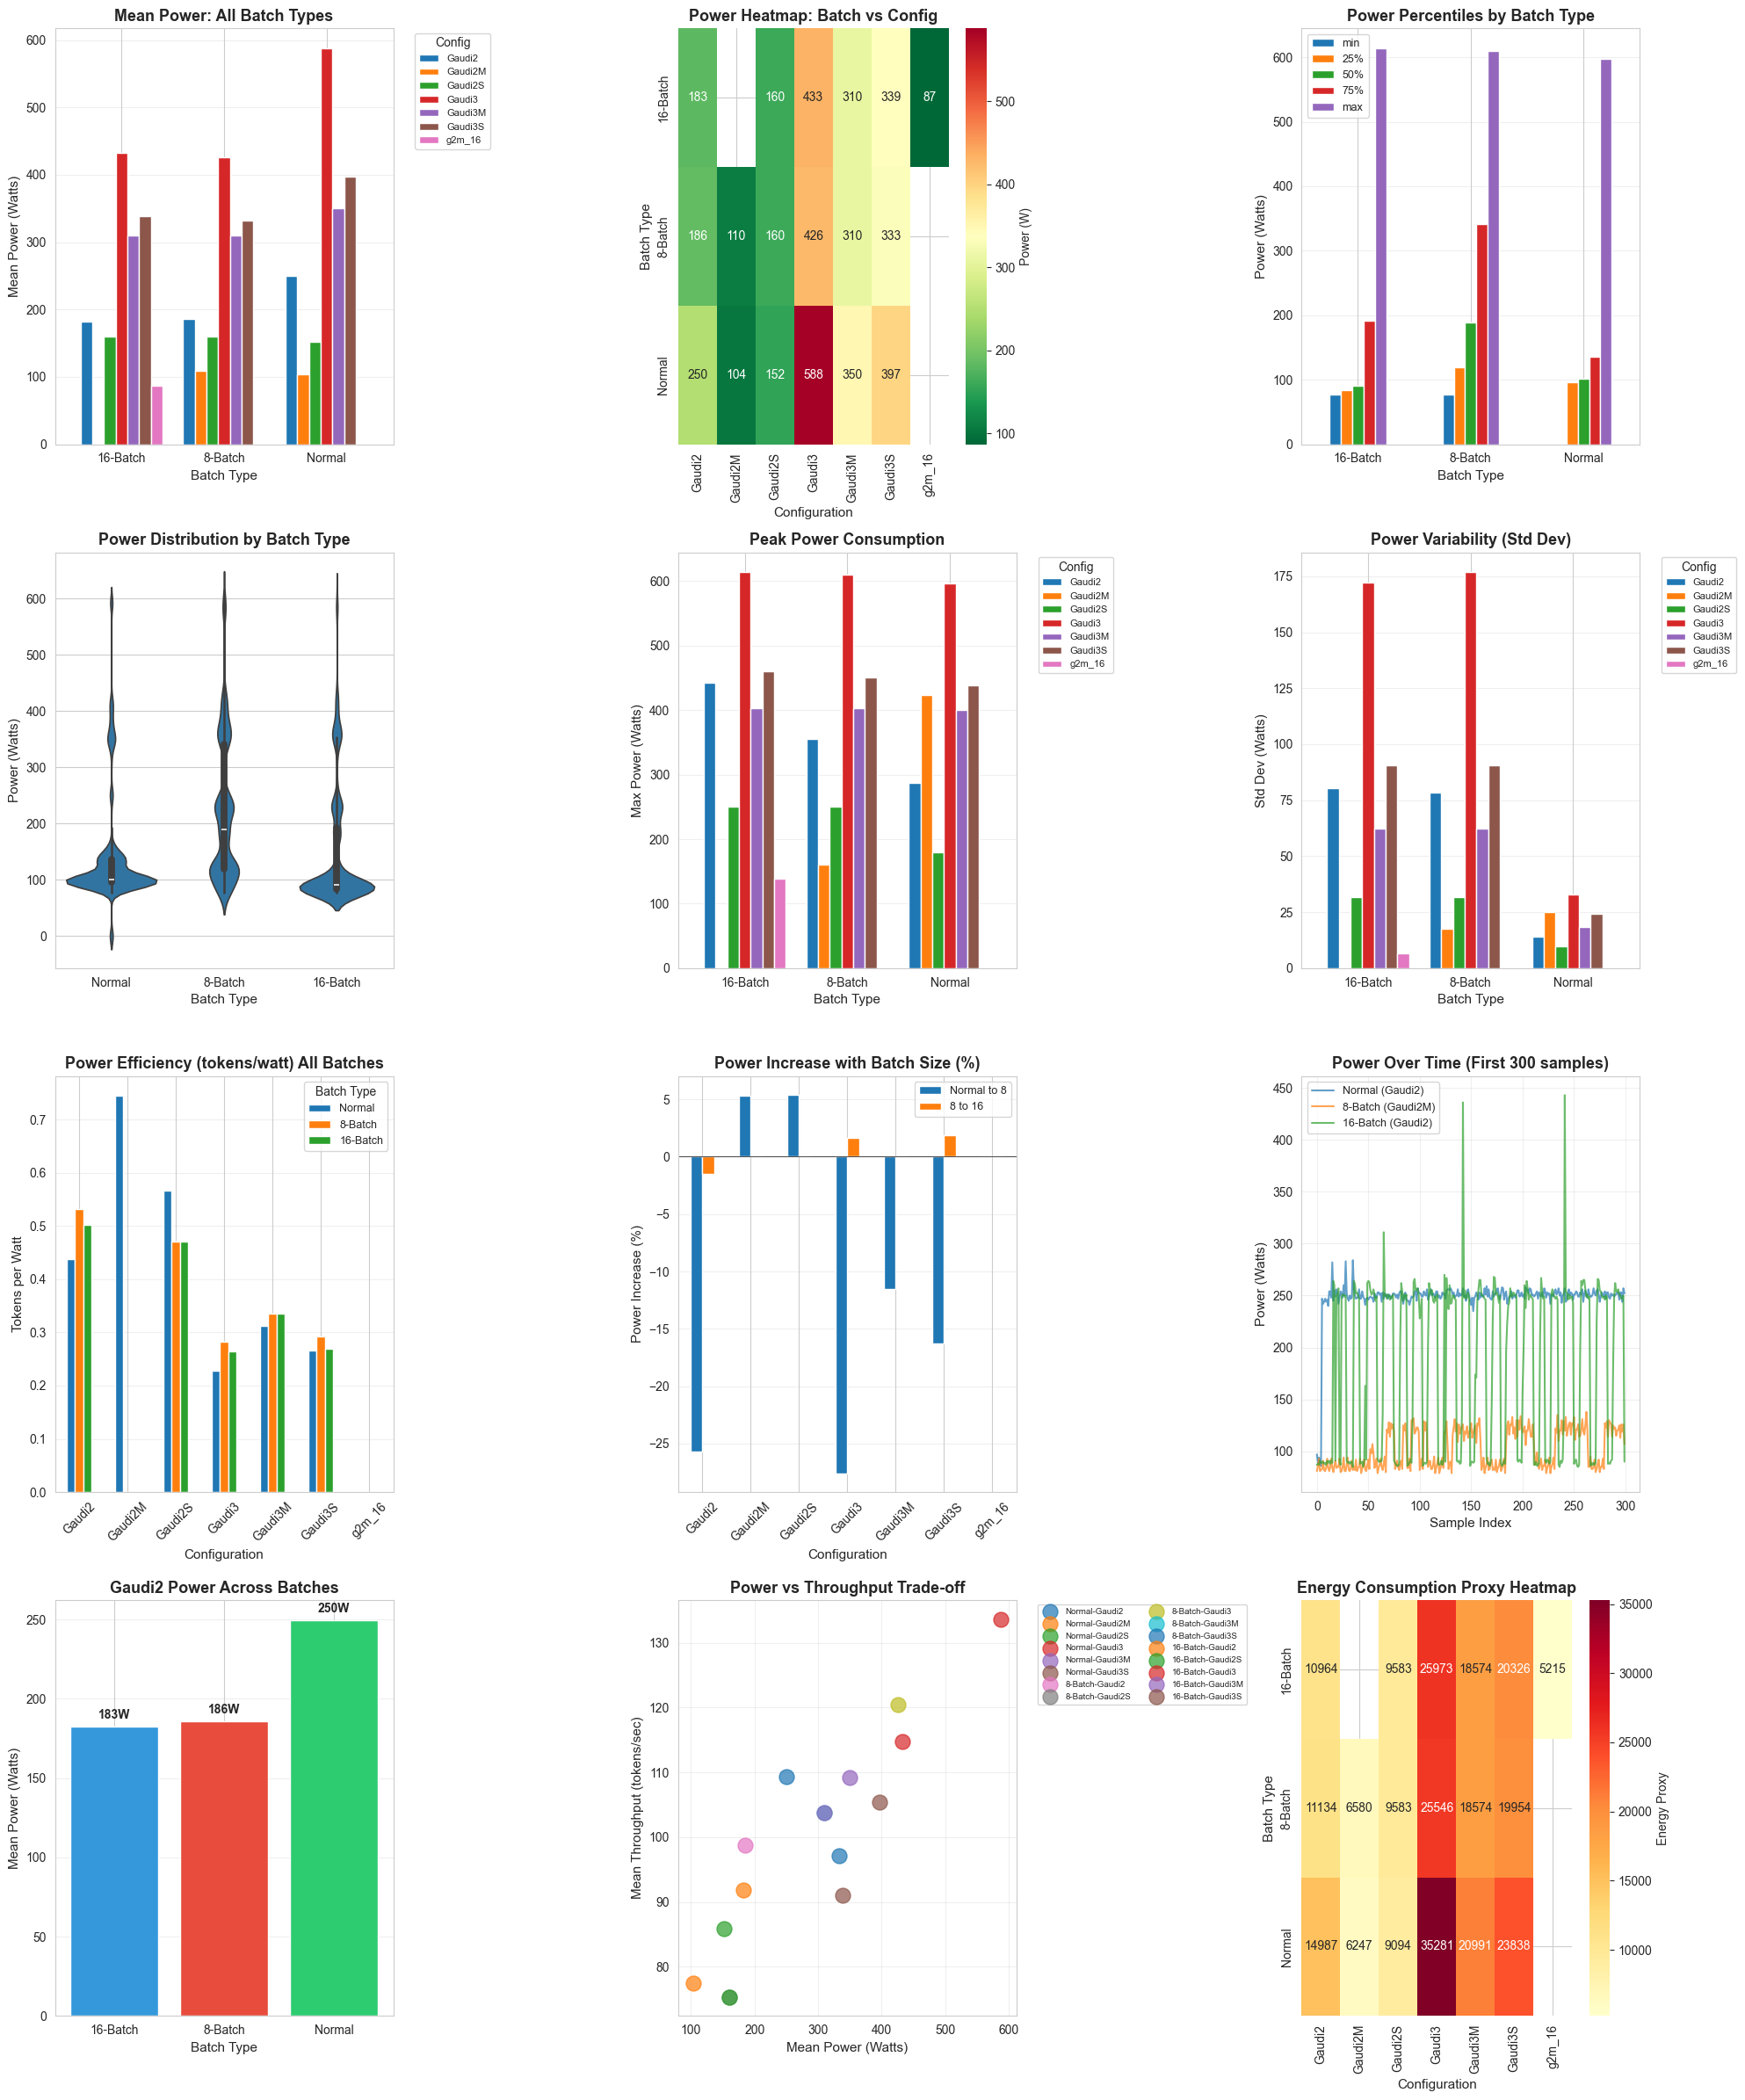


                                   EXTENSIVE POWER ANALYSIS

⚡ NORMAL BATCH POWER METRICS:
  • Mean power: 142.76W
  • Median power: 101.00W
  • Min power: 0.00W
  • Max power: 597.00W
  • Std dev: 100.11W
  • P95: 375.00W
  • P99: 590.00W

  Configuration breakdown:
    Gaudi2          → Mean:  249.8W, Peak:  287.0W
    Gaudi2M         → Mean:  104.1W, Peak:  424.0W
    Gaudi2S         → Mean:  151.6W, Peak:  180.0W
    Gaudi3          → Mean:  588.0W, Peak:  597.0W
    Gaudi3M         → Mean:  349.8W, Peak:  400.0W
    Gaudi3S         → Mean:  397.3W, Peak:  439.0W

⚡ 8-BATCH BATCH POWER METRICS:
  • Mean power: 220.13W
  • Median power: 189.00W
  • Min power: 77.00W
  • Max power: 610.00W
  • Std dev: 124.08W
  • P95: 422.00W
  • P99: 590.00W

  Configuration breakdown:
    Gaudi2          → Mean:  185.6W, Peak:  355.0W
    Gaudi2M         → Mean:  109.7W, Peak:  161.0W
    Gaudi2S         → Mean:  159.7W, Peak:  251.0W
    Gaudi3          → Mean:  425.8W, Peak:  610.0W
    Gaudi3M

In [266]:
# Combine all power data for comprehensive analysis
if 'power_data' in locals() and 'power_8_data' in locals() and 'power_16_data' in locals():
    # Tag power data with batch type
    power_normal_list = []
    for config, df in power_data.items():
        df_copy = df.copy()
        df_copy['batch_type'] = 'Normal'
        power_normal_list.append(df_copy)
    
    power_8_list = []
    for config, df in power_8_data.items():
        df_copy = df.copy()
        df_copy['batch_type'] = '8-Batch'
        power_8_list.append(df_copy)
    
    power_16_list = []
    for config, df in power_16_data.items():
        df_copy = df.copy()
        df_copy['batch_type'] = '16-Batch'
        power_16_list.append(df_copy)
    
    # Combine all power datasets
    all_power_df = pd.concat(power_normal_list + power_8_list + power_16_list, ignore_index=True)
    
    fig = plt.figure(figsize=(20, 24))
    
    # 1. Power consumption by batch type and config
    ax1 = plt.subplot(4, 3, 1)
    power_batch_config = all_power_df.groupby(['batch_type', 'config'])['power_w'].mean().unstack()
    power_batch_config.plot(kind='bar', ax=ax1, width=0.8)
    ax1.set_title('Mean Power: All Batch Types', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Batch Type', fontsize=11)
    ax1.set_ylabel('Mean Power (Watts)', fontsize=11)
    ax1.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax1.tick_params(axis='x', rotation=0)
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. Power heatmap
    ax2 = plt.subplot(4, 3, 2)
    sns.heatmap(power_batch_config, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax2, cbar_kws={'label': 'Power (W)'})
    ax2.set_title('Power Heatmap: Batch vs Config', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Configuration', fontsize=11)
    ax2.set_ylabel('Batch Type', fontsize=11)
    
    # 3. Power percentiles by batch type
    ax3 = plt.subplot(4, 3, 3)
    power_percentiles_batch = all_power_df.groupby('batch_type')['power_w'].describe()[['min', '25%', '50%', '75%', 'max']]
    power_percentiles_batch.plot(kind='bar', ax=ax3)
    ax3.set_title('Power Percentiles by Batch Type', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Batch Type', fontsize=11)
    ax3.set_ylabel('Power (Watts)', fontsize=11)
    ax3.tick_params(axis='x', rotation=0)
    ax3.legend(fontsize=9)
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Power distribution violin plot
    ax4 = plt.subplot(4, 3, 4)
    batch_order = ['Normal', '8-Batch', '16-Batch']
    valid_batches = [b for b in batch_order if b in all_power_df['batch_type'].values]
    sns.violinplot(data=all_power_df[all_power_df['batch_type'].isin(valid_batches)], 
                   x='batch_type', y='power_w', order=valid_batches, ax=ax4)
    ax4.set_title('Power Distribution by Batch Type', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Batch Type', fontsize=11)
    ax4.set_ylabel('Power (Watts)', fontsize=11)
    
    # 5. Max power by configuration
    ax5 = plt.subplot(4, 3, 5)
    max_power = all_power_df.groupby(['batch_type', 'config'])['power_w'].max().unstack()
    max_power.plot(kind='bar', ax=ax5, width=0.8)
    ax5.set_title('Peak Power Consumption', fontsize=13, fontweight='bold')
    ax5.set_xlabel('Batch Type', fontsize=11)
    ax5.set_ylabel('Max Power (Watts)', fontsize=11)
    ax5.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax5.tick_params(axis='x', rotation=0)
    ax5.grid(axis='y', alpha=0.3)
    
    # 6. Power variability (std dev)
    ax6 = plt.subplot(4, 3, 6)
    power_std = all_power_df.groupby(['batch_type', 'config'])['power_w'].std().unstack()
    power_std.plot(kind='bar', ax=ax6, width=0.8)
    ax6.set_title('Power Variability (Std Dev)', fontsize=13, fontweight='bold')
    ax6.set_xlabel('Batch Type', fontsize=11)
    ax6.set_ylabel('Std Dev (Watts)', fontsize=11)
    ax6.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax6.tick_params(axis='x', rotation=0)
    ax6.grid(axis='y', alpha=0.3)
    
    # 7. Power efficiency (tokens per watt) for all batches
    ax7 = plt.subplot(4, 3, 7)
    if 'all_batches_df' in locals():
        # Calculate power efficiency for each batch type
        efficiency_all = pd.DataFrame()
        for batch_type in ['Normal', '8-Batch', '16-Batch']:
            if batch_type in all_batches_df['batch_type'].values and batch_type in power_batch_config.index:
                perf_data = all_batches_df[all_batches_df['batch_type'] == batch_type].groupby('config')['throughput'].mean()
                power_data_batch = power_batch_config.loc[batch_type]
                eff = perf_data / power_data_batch
                efficiency_all[batch_type] = eff
        
        efficiency_all.plot(kind='bar', ax=ax7)
        ax7.set_title('Power Efficiency (tokens/watt) All Batches', fontsize=13, fontweight='bold')
        ax7.set_xlabel('Configuration', fontsize=11)
        ax7.set_ylabel('Tokens per Watt', fontsize=11)
        ax7.tick_params(axis='x', rotation=45)
        ax7.legend(title='Batch Type', fontsize=9)
        ax7.grid(axis='y', alpha=0.3)
    
    # 8. Power increase with batch size
    ax8 = plt.subplot(4, 3, 8)
    if len(power_batch_config) > 1:
        power_increase = pd.DataFrame()
        if 'Normal' in power_batch_config.index and '8-Batch' in power_batch_config.index:
            power_increase['Normal to 8'] = ((power_batch_config.loc['8-Batch'] - power_batch_config.loc['Normal']) / 
                                             power_batch_config.loc['Normal'] * 100)
        if '8-Batch' in power_batch_config.index and '16-Batch' in power_batch_config.index:
            power_increase['8 to 16'] = ((power_batch_config.loc['16-Batch'] - power_batch_config.loc['8-Batch']) / 
                                         power_batch_config.loc['8-Batch'] * 100)
        
        power_increase.plot(kind='bar', ax=ax8)
        ax8.set_title('Power Increase with Batch Size (%)', fontsize=13, fontweight='bold')
        ax8.set_xlabel('Configuration', fontsize=11)
        ax8.set_ylabel('Power Increase (%)', fontsize=11)
        ax8.tick_params(axis='x', rotation=45)
        ax8.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax8.legend(fontsize=9)
        ax8.grid(axis='y', alpha=0.3)
    
    # 9. Time series comparison (first 300 samples)
    ax9 = plt.subplot(4, 3, 9)
    sample_size = 300
    for batch_type in ['Normal', '8-Batch', '16-Batch']:
        if batch_type in all_power_df['batch_type'].values:
            # Get one config for comparison
            config_sample = all_power_df[all_power_df['batch_type'] == batch_type]['config'].iloc[0]
            data = all_power_df[(all_power_df['batch_type'] == batch_type) & 
                               (all_power_df['config'] == config_sample)]['power_w'].head(sample_size)
            ax9.plot(data.values, label=f'{batch_type} ({config_sample})', alpha=0.7, linewidth=1.5)
    
    ax9.set_title(f'Power Over Time (First {sample_size} samples)', fontsize=13, fontweight='bold')
    ax9.set_xlabel('Sample Index', fontsize=11)
    ax9.set_ylabel('Power (Watts)', fontsize=11)
    ax9.legend(fontsize=9)
    ax9.grid(alpha=0.3)
    
    # 10. Configuration-wise power comparison across batches
    ax10 = plt.subplot(4, 3, 10)
    configs_in_all = power_batch_config.columns
    if len(configs_in_all) > 0:
        config_to_plot = configs_in_all[0]  # Plot first config
        if config_to_plot in power_batch_config.columns:
            power_by_batch = power_batch_config[config_to_plot]
            colors_batch = ['#3498db', '#e74c3c', '#2ecc71'][:len(power_by_batch)]
            ax10.bar(range(len(power_by_batch)), power_by_batch.values, color=colors_batch)
            ax10.set_xticks(range(len(power_by_batch)))
            ax10.set_xticklabels(power_by_batch.index)
            ax10.set_title(f'{config_to_plot} Power Across Batches', fontsize=13, fontweight='bold')
            ax10.set_xlabel('Batch Type', fontsize=11)
            ax10.set_ylabel('Mean Power (Watts)', fontsize=11)
            ax10.grid(axis='y', alpha=0.3)
            for i, v in enumerate(power_by_batch.values):
                ax10.text(i, v + 5, f'{v:.0f}W', ha='center', fontweight='bold')
    
    # 11. Power vs Throughput efficiency scatter
    ax11 = plt.subplot(4, 3, 11)
    if 'all_batches_df' in locals():
        for batch_type in ['Normal', '8-Batch', '16-Batch']:
            if batch_type in all_batches_df['batch_type'].values and batch_type in power_batch_config.index:
                throughput_vals = all_batches_df[all_batches_df['batch_type'] == batch_type].groupby('config')['throughput'].mean()
                power_vals = power_batch_config.loc[batch_type]
                
                for config in throughput_vals.index:
                    if config in power_vals.index:
                        ax11.scatter(power_vals[config], throughput_vals[config], 
                                   s=150, alpha=0.7, label=f'{batch_type}-{config}')
        
        ax11.set_title('Power vs Throughput Trade-off', fontsize=13, fontweight='bold')
        ax11.set_xlabel('Mean Power (Watts)', fontsize=11)
        ax11.set_ylabel('Mean Throughput (tokens/sec)', fontsize=11)
        ax11.grid(alpha=0.3)
        ax11.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, ncol=2)
    
    # 12. Energy consumption estimate (Power × Time proxy)
    ax12 = plt.subplot(4, 3, 12)
    energy_proxy = all_power_df.groupby(['batch_type', 'config'])['power_w'].apply(
        lambda x: x.sum() / len(x) * 60).unstack()  # Normalized by sample count
    sns.heatmap(energy_proxy, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax12, 
               cbar_kws={'label': 'Energy Proxy'})
    ax12.set_title('Energy Consumption Proxy Heatmap', fontsize=13, fontweight='bold')
    ax12.set_xlabel('Configuration', fontsize=11)
    ax12.set_ylabel('Batch Type', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Print extensive power analysis
    print("\n" + "="*100)
    print(" " * 35 + "EXTENSIVE POWER ANALYSIS")
    print("="*100)
    
    for batch_type in ['Normal', '8-Batch', '16-Batch']:
        if batch_type in all_power_df['batch_type'].values:
            batch_power = all_power_df[all_power_df['batch_type'] == batch_type]
            print(f"\n⚡ {batch_type.upper()} BATCH POWER METRICS:")
            print(f"  • Mean power: {batch_power['power_w'].mean():.2f}W")
            print(f"  • Median power: {batch_power['power_w'].median():.2f}W")
            print(f"  • Min power: {batch_power['power_w'].min():.2f}W")
            print(f"  • Max power: {batch_power['power_w'].max():.2f}W")
            print(f"  • Std dev: {batch_power['power_w'].std():.2f}W")
            print(f"  • P95: {batch_power['power_w'].quantile(0.95):.2f}W")
            print(f"  • P99: {batch_power['power_w'].quantile(0.99):.2f}W")
            
            # Per-config breakdown
            print(f"\n  Configuration breakdown:")
            for config in sorted(batch_power['config'].unique()):
                config_power = batch_power[batch_power['config'] == config]['power_w']
                print(f"    {config:15} → Mean: {config_power.mean():6.1f}W, Peak: {config_power.max():6.1f}W")
    
    print("\n" + "="*100)
    print("POWER SCALING INSIGHTS:")
    print("="*100)
    
    if 'Normal' in power_batch_config.index and '16-Batch' in power_batch_config.index:
        for config in power_batch_config.columns:
            normal_power = power_batch_config.loc['Normal', config]
            batch16_power = power_batch_config.loc['16-Batch', config]
            power_diff = ((batch16_power - normal_power) / normal_power) * 100
            print(f"{config:15} → Power increase Normal to 16-Batch: {power_diff:+.1f}% ({normal_power:.0f}W → {batch16_power:.0f}W)")
    
    if 'efficiency_all' in locals():
        print("\n" + "="*100)
        print("POWER EFFICIENCY RANKING (Tokens per Watt):")
        print("="*100)
        for batch_type in efficiency_all.columns:
            print(f"\n{batch_type}:")
            sorted_eff = efficiency_all[batch_type].sort_values(ascending=False)
            for i, (config, eff) in enumerate(sorted_eff.items(), 1):
                if not pd.isna(eff):
                    print(f"  {i}. {config:15} → {eff:.3f} tokens/watt")

## 20. Detailed Per-Configuration Analysis


                                        8 DETAILED ANALYSIS

📊 PERFORMANCE METRICS:
----------------------------------------------------------------------------------------------------

  8-Batch:
    • Requests: 520
    • Throughput: 70.89 ± 11.16 tokens/sec
    • TTFT: 0.1536 ± 0.5943 sec
    • Mean ITL: 0.013750 sec
    • Total tokens: 159,895
    • Min throughput: 3.21 tokens/sec
    • Max throughput: 83.04 tokens/sec

⚡ POWER METRICS:
----------------------------------------------------------------------------------------------------

💡 EFFICIENCY METRICS:
----------------------------------------------------------------------------------------------------

                                        Gaudi2 DETAILED ANALYSIS

📊 PERFORMANCE METRICS:
----------------------------------------------------------------------------------------------------

  Normal:
    • Requests: 200
    • Throughput: 109.37 ± 3.34 tokens/sec
    • TTFT: 0.0379 ± 0.1765 sec
    • Mean ITL: 0.009106 sec
    

<Figure size 1200x800 with 0 Axes>

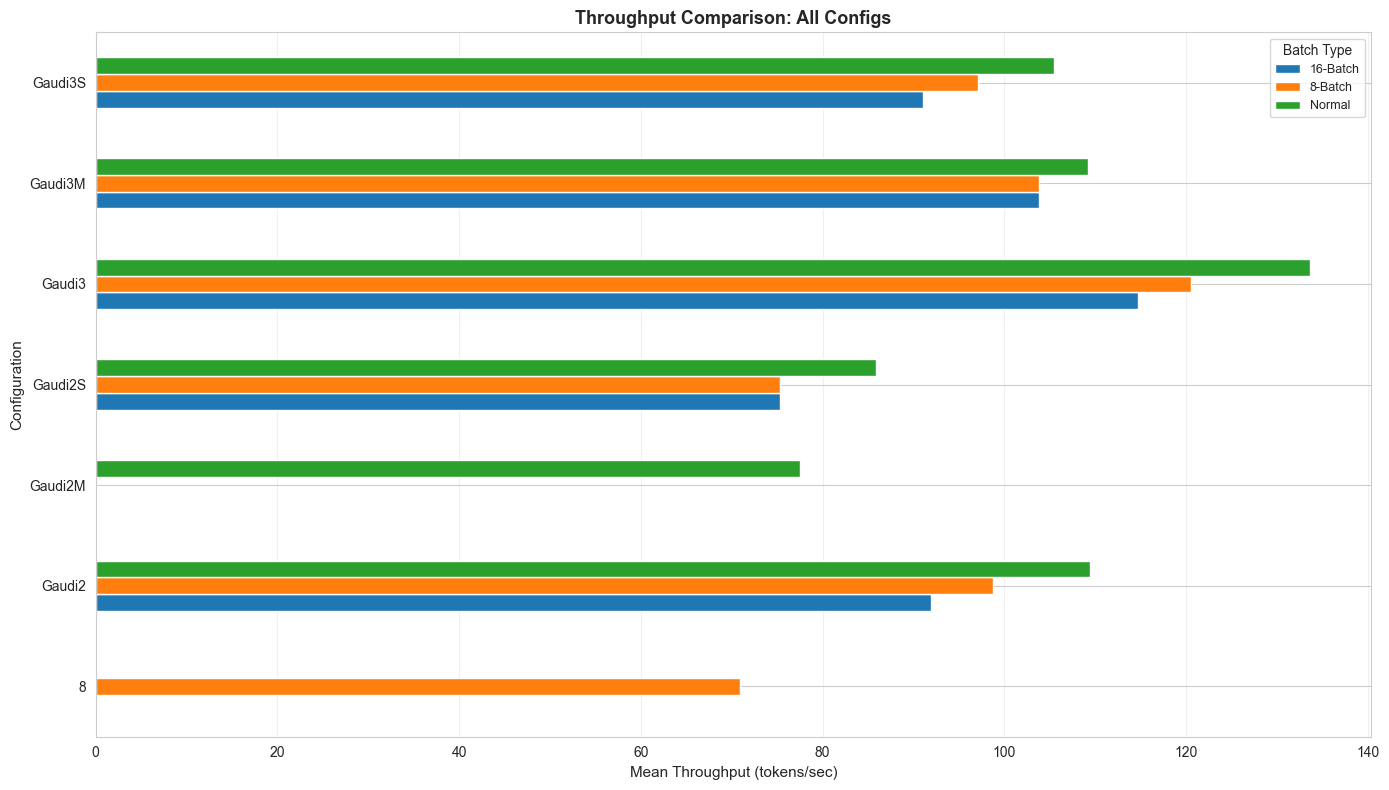

<Figure size 1200x800 with 0 Axes>

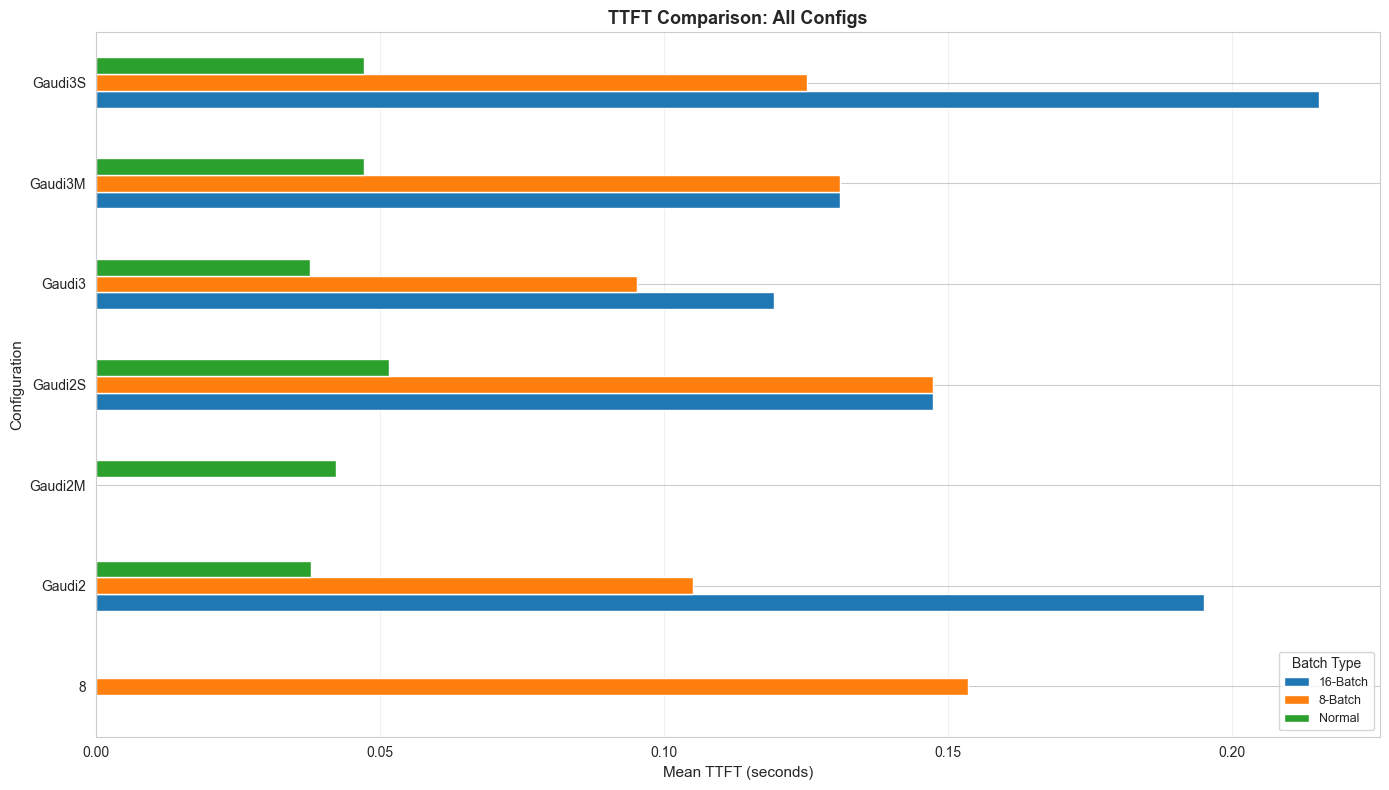

<Figure size 1200x800 with 0 Axes>

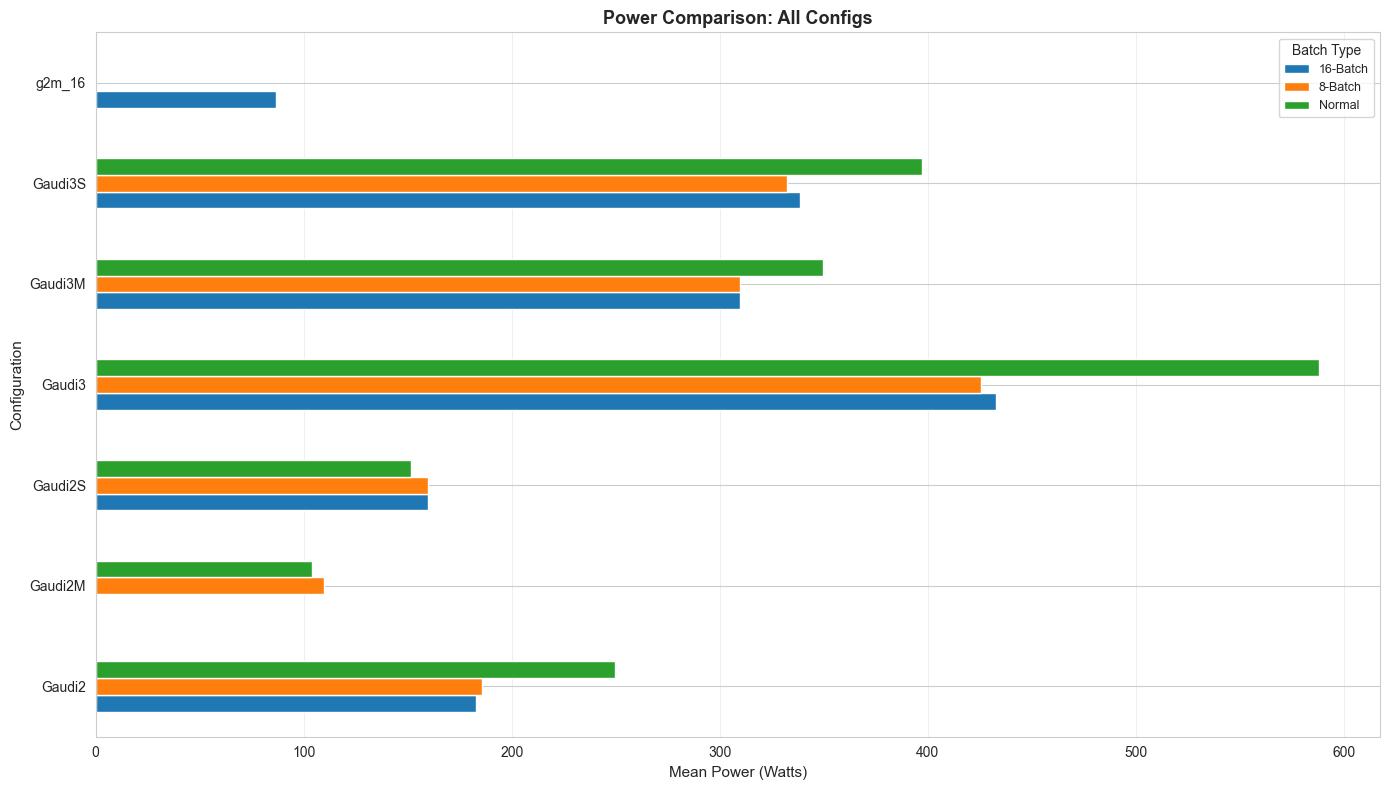

<Figure size 1200x800 with 0 Axes>

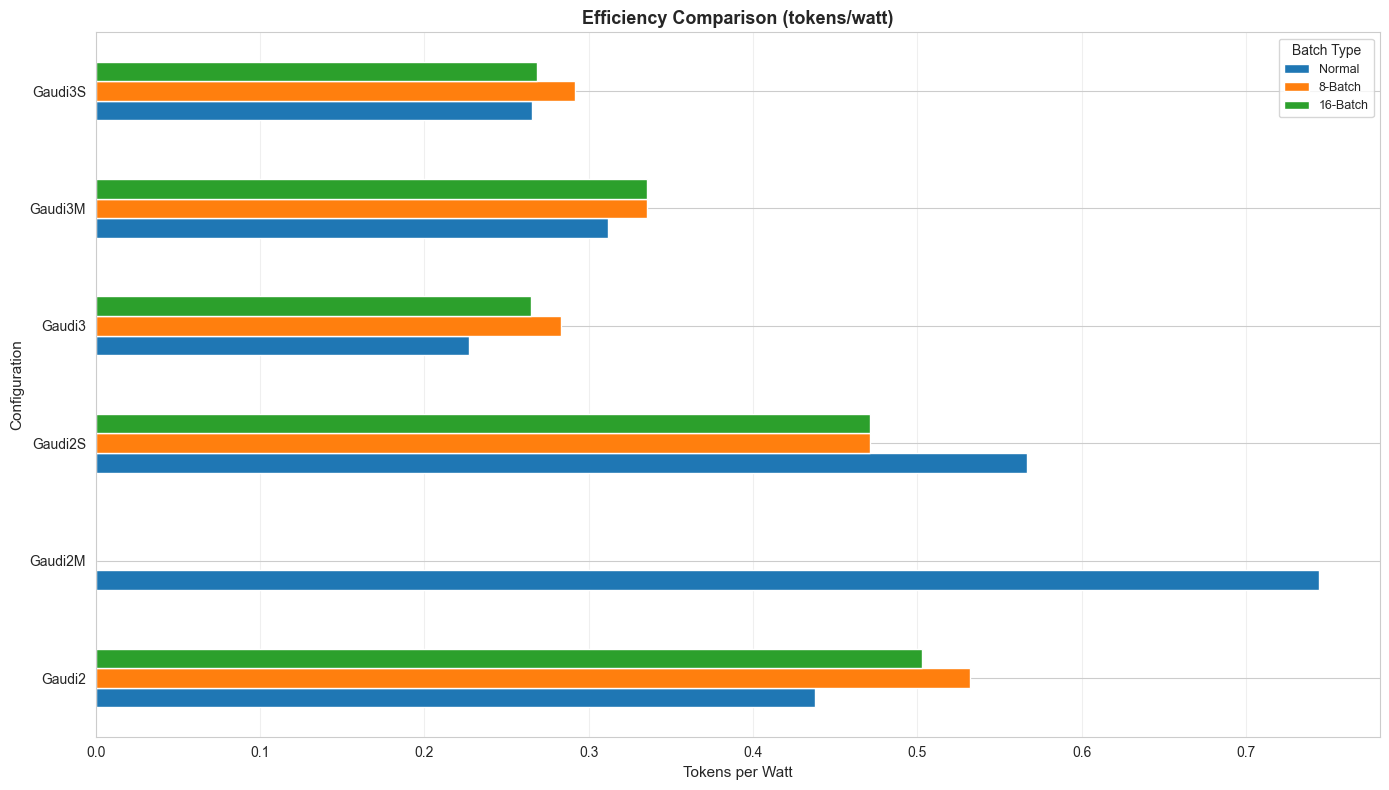

<Figure size 1200x800 with 0 Axes>

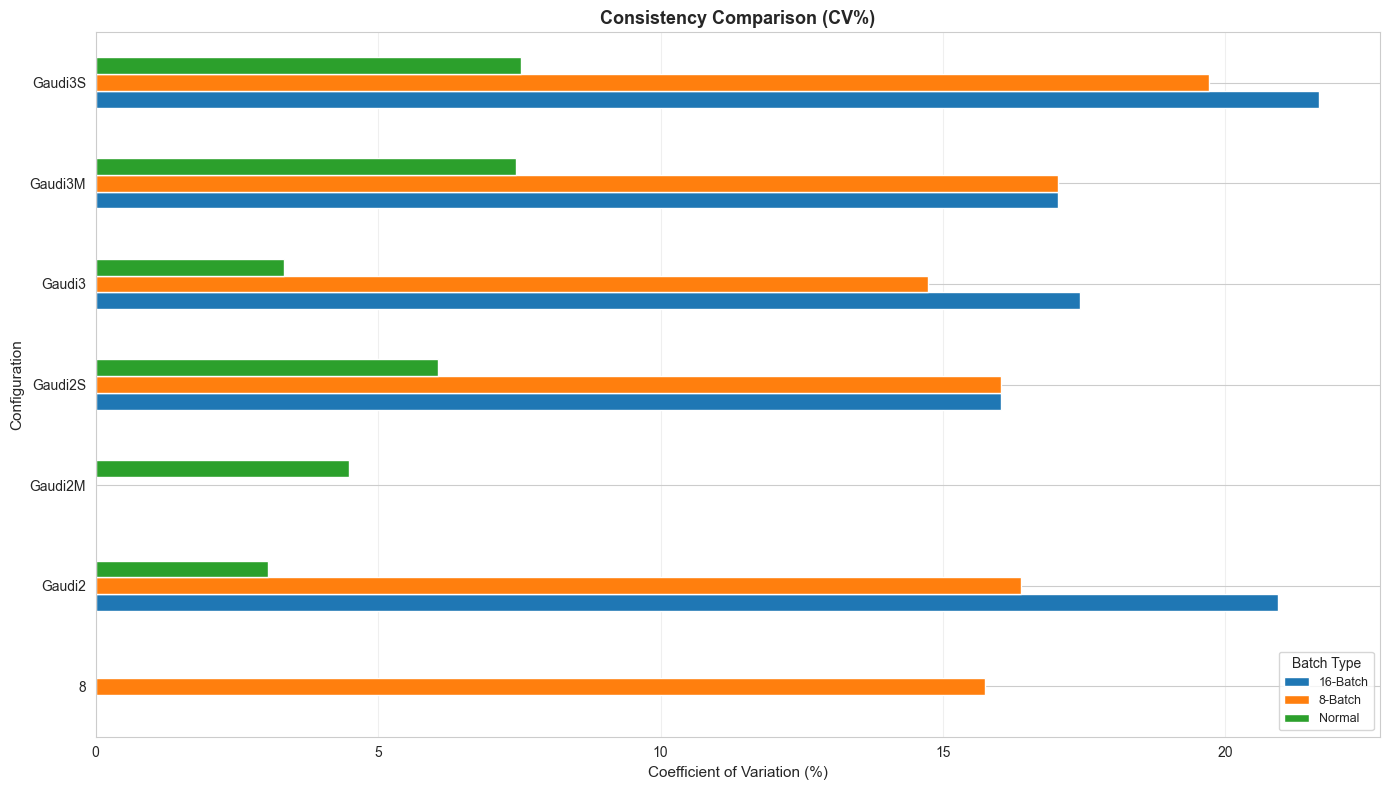

<Figure size 1200x800 with 0 Axes>

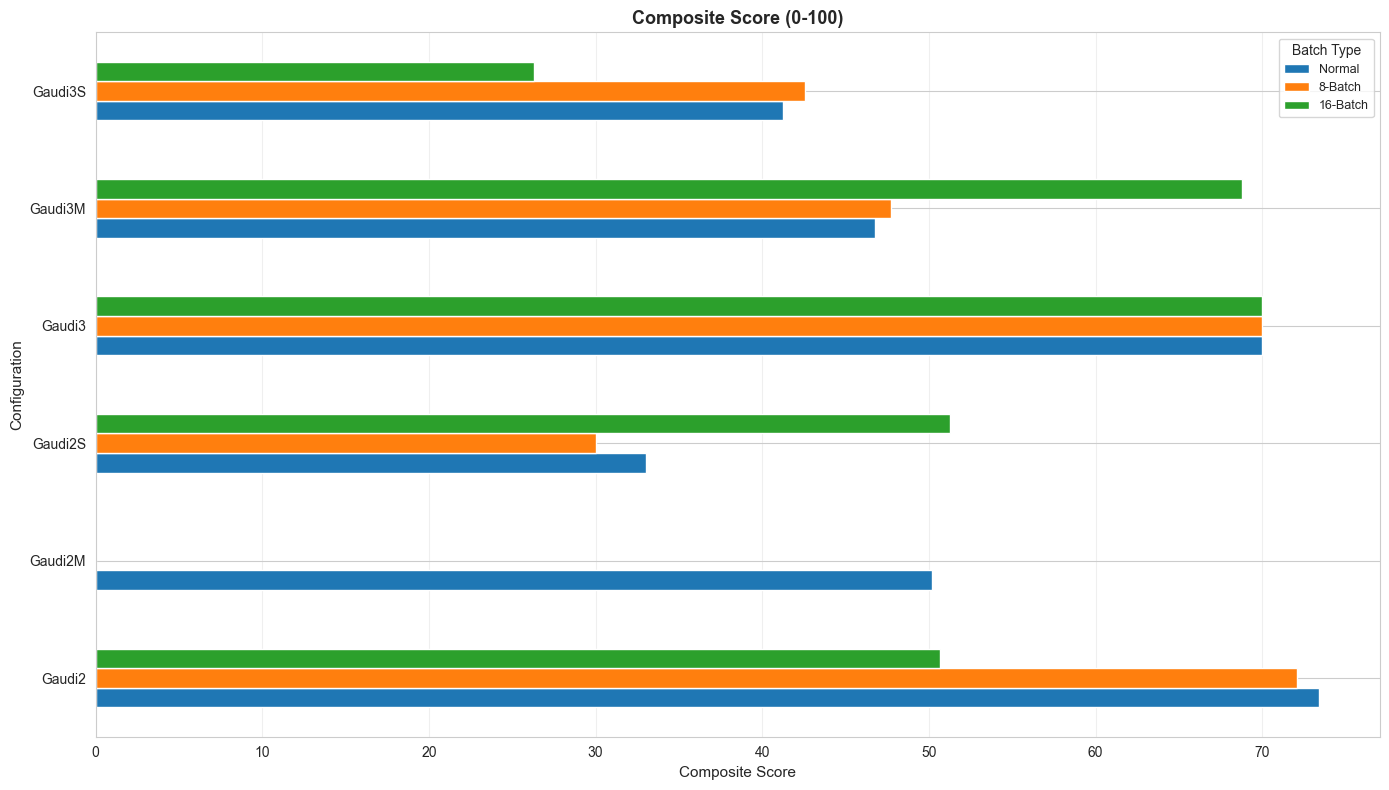


                                   CONFIGURATION COMPARISON COMPLETE


In [268]:
# Individual configuration deep dive
if 'all_batches_df' in locals() and 'all_power_df' in locals():
    configs = sorted(all_batches_df['config'].unique())
    
    # Create detailed report for each configuration
    for config in configs:
        print("\n" + "="*100)
        print(f" " * 40 + f"{config} DETAILED ANALYSIS")
        print("="*100)
        
        # Performance metrics across batch types
        config_data = all_batches_df[all_batches_df['config'] == config]
        config_power = all_power_df[all_power_df['config'] == config]
        
        print(f"\n📊 PERFORMANCE METRICS:")
        print("-" * 100)
        
        for batch_type in ['Normal', '8-Batch', '16-Batch']:
            if batch_type in config_data['batch_type'].values:
                batch_data = config_data[config_data['batch_type'] == batch_type]
                print(f"\n  {batch_type}:")
                print(f"    • Requests: {len(batch_data)}")
                print(f"    • Throughput: {batch_data['throughput'].mean():.2f} ± {batch_data['throughput'].std():.2f} tokens/sec")
                print(f"    • TTFT: {batch_data['ttft'].mean():.4f} ± {batch_data['ttft'].std():.4f} sec")
                print(f"    • Mean ITL: {batch_data['mean_itl'].mean():.6f} sec")
                print(f"    • Total tokens: {batch_data['tokens_generated'].sum():,}")
                print(f"    • Min throughput: {batch_data['throughput'].min():.2f} tokens/sec")
                print(f"    • Max throughput: {batch_data['throughput'].max():.2f} tokens/sec")
        
        print(f"\n⚡ POWER METRICS:")
        print("-" * 100)
        
        for batch_type in ['Normal', '8-Batch', '16-Batch']:
            if batch_type in config_power['batch_type'].values:
                power_data = config_power[config_power['batch_type'] == batch_type]['power_w']
                print(f"\n  {batch_type}:")
                print(f"    • Mean power: {power_data.mean():.2f}W")
                print(f"    • Peak power: {power_data.max():.2f}W")
                print(f"    • Min power: {power_data.min():.2f}W")
                print(f"    • Power std dev: {power_data.std():.2f}W")
                print(f"    • P95 power: {power_data.quantile(0.95):.2f}W")
        
        print(f"\n💡 EFFICIENCY METRICS:")
        print("-" * 100)
        
        for batch_type in ['Normal', '8-Batch', '16-Batch']:
            if (batch_type in config_data['batch_type'].values and 
                batch_type in config_power['batch_type'].values):
                perf = config_data[config_data['batch_type'] == batch_type]['throughput'].mean()
                power = config_power[config_power['batch_type'] == batch_type]['power_w'].mean()
                efficiency = perf / power
                print(f"  {batch_type:15} → {efficiency:.3f} tokens/watt ({perf:.2f} tokens/sec ÷ {power:.0f}W)")
    
    # Create visual comparison for all configs
    # 1. Throughput comparison across all configs and batches
    plt.figure(figsize=(12, 8))
    throughput_all = all_batches_df.pivot_table(values='throughput', index='config', 
                                                 columns='batch_type', aggfunc='mean')
    throughput_all.plot(kind='barh')
    plt.title('Throughput Comparison: All Configs', fontsize=13, fontweight='bold')
    plt.xlabel('Mean Throughput (tokens/sec)', fontsize=11)
    plt.ylabel('Configuration', fontsize=11)
    plt.legend(title='Batch Type', fontsize=9)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 2. TTFT comparison
    plt.figure(figsize=(12, 8))
    ttft_all = all_batches_df.pivot_table(values='ttft', index='config', 
                                          columns='batch_type', aggfunc='mean')
    ttft_all.plot(kind='barh')
    plt.title('TTFT Comparison: All Configs', fontsize=13, fontweight='bold')
    plt.xlabel('Mean TTFT (seconds)', fontsize=11)
    plt.ylabel('Configuration', fontsize=11)
    plt.legend(title='Batch Type', fontsize=9)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 3. Power comparison
    plt.figure(figsize=(12, 8))
    power_all = all_power_df.pivot_table(values='power_w', index='config', 
                                         columns='batch_type', aggfunc='mean')
    power_all.plot(kind='barh')
    plt.title('Power Comparison: All Configs', fontsize=13, fontweight='bold')
    plt.xlabel('Mean Power (Watts)', fontsize=11)
    plt.ylabel('Configuration', fontsize=11)
    plt.legend(title='Batch Type', fontsize=9)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 4. Efficiency comparison
    plt.figure(figsize=(12, 8))
    efficiency_comparison = pd.DataFrame()
    for batch_type in ['Normal', '8-Batch', '16-Batch']:
        if batch_type in all_batches_df['batch_type'].values:
            perf = all_batches_df[all_batches_df['batch_type'] == batch_type].groupby('config')['throughput'].mean()
            pow_val = all_power_df[all_power_df['batch_type'] == batch_type].groupby('config')['power_w'].mean()
            eff = perf / pow_val
            efficiency_comparison[batch_type] = eff
    
    efficiency_comparison.plot(kind='barh')
    plt.title('Efficiency Comparison (tokens/watt)', fontsize=13, fontweight='bold')
    plt.xlabel('Tokens per Watt', fontsize=11)
    plt.ylabel('Configuration', fontsize=11)
    plt.legend(title='Batch Type', fontsize=9)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 5. Consistency (CV%) comparison
    plt.figure(figsize=(12, 8))
    cv_comparison = all_batches_df.groupby(['config', 'batch_type'])['throughput'].apply(
        lambda x: (x.std() / x.mean()) * 100).unstack()
    cv_comparison.plot(kind='barh')
    plt.title('Consistency Comparison (CV%)', fontsize=13, fontweight='bold')
    plt.xlabel('Coefficient of Variation (%)', fontsize=11)
    plt.ylabel('Configuration', fontsize=11)
    plt.legend(title='Batch Type', fontsize=9)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 6. Overall score (composite metric)
    plt.figure(figsize=(12, 8))
    # Normalize and compute composite score
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    
    composite_scores = pd.DataFrame()
    for batch_type in ['Normal', '8-Batch', '16-Batch']:
        if batch_type in all_batches_df['batch_type'].values:
            batch_perf_data = all_batches_df[all_batches_df['batch_type'] == batch_type].groupby('config').agg({
                'throughput': 'mean',
                'ttft': 'mean'
            })
            batch_power_data = all_power_df[all_power_df['batch_type'] == batch_type].groupby('config')['power_w'].mean()
            
            # Align indices - only use configs that exist in both datasets
            common_configs = batch_perf_data.index.intersection(batch_power_data.index)
            if len(common_configs) > 0:
                batch_perf_aligned = batch_perf_data.loc[common_configs]
                batch_power_aligned = batch_power_data.loc[common_configs]
                
                # Calculate normalized scores
                throughput_norm = scaler.fit_transform(batch_perf_aligned['throughput'].values.reshape(-1, 1)).flatten()
                ttft_norm = 1 - scaler.fit_transform(batch_perf_aligned['ttft'].values.reshape(-1, 1)).flatten()
                power_norm = 1 - scaler.fit_transform(batch_power_aligned.values.reshape(-1, 1)).flatten()
                
                # Weighted composite (40% throughput, 30% latency, 30% power)
                composite = 0.4 * throughput_norm + 0.3 * ttft_norm + 0.3 * power_norm
                composite_scores[batch_type] = pd.Series(composite * 100, index=common_configs)
    
    if not composite_scores.empty:
        composite_scores.plot(kind='barh')
        plt.title('Composite Score (0-100)', fontsize=13, fontweight='bold')
        plt.xlabel('Composite Score', fontsize=11)
        plt.ylabel('Configuration', fontsize=11)
        plt.legend(title='Batch Type', fontsize=9)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No composite scores to plot")
    
    print("\n" + "="*100)
    print(" " * 35 + "CONFIGURATION COMPARISON COMPLETE")
    print("="*100)

## 21. Advanced Statistical Analysis & Correlations

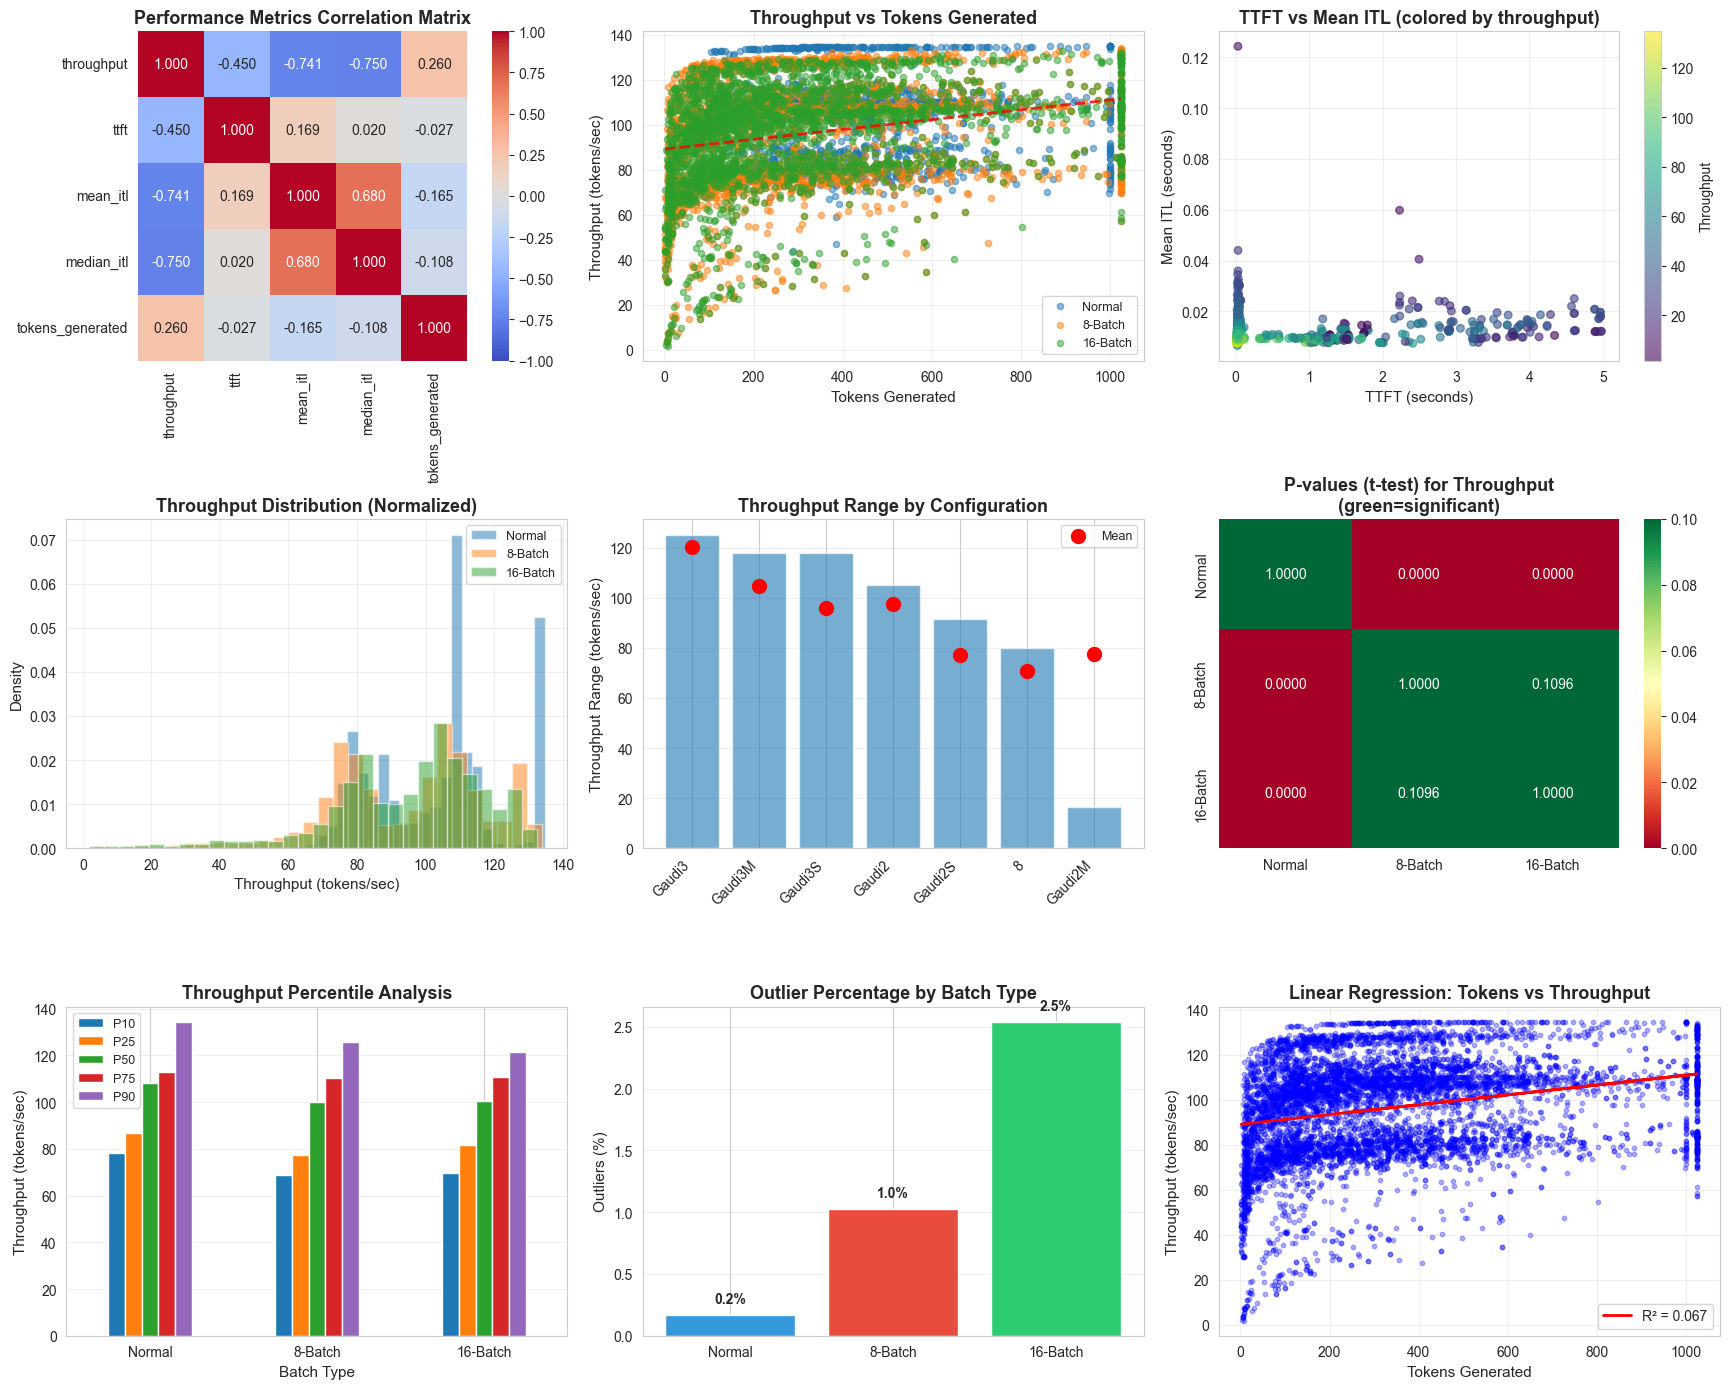


                                   STATISTICAL INSIGHTS

📊 CORRELATION ANALYSIS:
----------------------------------------------------------------------------------------------------
Strong correlations (|r| > 0.7):
  • throughput ↔ mean_itl: r = -0.741
  • throughput ↔ median_itl: r = -0.750

📈 REGRESSION ANALYSIS:
----------------------------------------------------------------------------------------------------
  • Tokens → Throughput: R² = 0.067
  • Coefficient: 0.021846
  • Intercept: 89.096
  ❌ Weak relationship: Token count poorly predicts throughput

🎯 OUTLIER ANALYSIS:
----------------------------------------------------------------------------------------------------
  • Normal          → 0.17% outliers
  • 8-Batch         → 1.03% outliers
  • 16-Batch        → 2.54% outliers

📉 VARIABILITY ANALYSIS:
----------------------------------------------------------------------------------------------------
  • Normal          → CV: 18.37%, Range: 90.99 tokens/sec
  • 8-Batch       

In [269]:
if 'all_batches_df' in locals():
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    
    # 1. Correlation matrix for performance metrics
    ax1 = axes[0, 0]
    corr_metrics = all_batches_df[['throughput', 'ttft', 'mean_itl', 'median_itl', 'tokens_generated']].corr()
    sns.heatmap(corr_metrics, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax1, 
               vmin=-1, vmax=1, square=True)
    ax1.set_title('Performance Metrics Correlation Matrix', fontsize=13, fontweight='bold')
    
    # 2. Throughput vs Tokens Generated scatter
    ax2 = axes[0, 1]
    for batch_type in ['Normal', '8-Batch', '16-Batch']:
        if batch_type in all_batches_df['batch_type'].values:
            data = all_batches_df[all_batches_df['batch_type'] == batch_type]
            ax2.scatter(data['tokens_generated'], data['throughput'], 
                       alpha=0.5, s=20, label=batch_type)
    ax2.set_title('Throughput vs Tokens Generated', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Tokens Generated', fontsize=11)
    ax2.set_ylabel('Throughput (tokens/sec)', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)
    
    # Add trend line
    z = np.polyfit(all_batches_df['tokens_generated'], all_batches_df['throughput'], 1)
    p = np.poly1d(z)
    ax2.plot(sorted(all_batches_df['tokens_generated']), 
            p(sorted(all_batches_df['tokens_generated'])), 
            "r--", alpha=0.8, linewidth=2, label='Trend')
    
    # 3. TTFT vs ITL relationship
    ax3 = axes[0, 2]
    ax3.scatter(all_batches_df['ttft'], all_batches_df['mean_itl'], 
               c=all_batches_df['throughput'], cmap='viridis', alpha=0.6, s=30)
    ax3.set_title('TTFT vs Mean ITL (colored by throughput)', fontsize=13, fontweight='bold')
    ax3.set_xlabel('TTFT (seconds)', fontsize=11)
    ax3.set_ylabel('Mean ITL (seconds)', fontsize=11)
    cbar = plt.colorbar(ax3.collections[0], ax=ax3)
    cbar.set_label('Throughput', fontsize=10)
    ax3.grid(alpha=0.3)
    
    # 4. Distribution comparison: Normal vs Q-Q plot
    ax4 = axes[1, 0]
    from scipy import stats
    for batch_type in ['Normal', '8-Batch', '16-Batch']:
        if batch_type in all_batches_df['batch_type'].values:
            data = all_batches_df[all_batches_df['batch_type'] == batch_type]['throughput']
            ax4.hist(data, bins=30, alpha=0.5, label=batch_type, density=True)
    ax4.set_title('Throughput Distribution (Normalized)', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Throughput (tokens/sec)', fontsize=11)
    ax4.set_ylabel('Density', fontsize=11)
    ax4.legend(fontsize=9)
    ax4.grid(alpha=0.3)
    
    # 5. Performance spread by configuration
    ax5 = axes[1, 1]
    config_spread = all_batches_df.groupby('config')['throughput'].agg(['min', 'max', 'mean'])
    config_spread['range'] = config_spread['max'] - config_spread['min']
    config_spread = config_spread.sort_values('range', ascending=False)
    
    x_pos = np.arange(len(config_spread))
    ax5.bar(x_pos, config_spread['range'], alpha=0.6)
    ax5.scatter(x_pos, config_spread['mean'], color='red', s=100, zorder=5, label='Mean')
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(config_spread.index, rotation=45, ha='right')
    ax5.set_title('Throughput Range by Configuration', fontsize=13, fontweight='bold')
    ax5.set_ylabel('Throughput Range (tokens/sec)', fontsize=11)
    ax5.legend(fontsize=9)
    ax5.grid(axis='y', alpha=0.3)
    
    # 6. Statistical significance tests (t-test between batch types)
    ax6 = axes[1, 2]
    from scipy.stats import ttest_ind
    
    pvalues_matrix = pd.DataFrame(index=['Normal', '8-Batch', '16-Batch'], 
                                  columns=['Normal', '8-Batch', '16-Batch'])
    
    for batch1 in ['Normal', '8-Batch', '16-Batch']:
        for batch2 in ['Normal', '8-Batch', '16-Batch']:
            if batch1 in all_batches_df['batch_type'].values and batch2 in all_batches_df['batch_type'].values:
                data1 = all_batches_df[all_batches_df['batch_type'] == batch1]['throughput']
                data2 = all_batches_df[all_batches_df['batch_type'] == batch2]['throughput']
                if len(data1) > 0 and len(data2) > 0:
                    _, pval = ttest_ind(data1, data2)
                    pvalues_matrix.loc[batch1, batch2] = pval
    
    pvalues_matrix = pvalues_matrix.astype(float)
    sns.heatmap(pvalues_matrix, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax6, 
               vmin=0, vmax=0.1, center=0.05)
    ax6.set_title('P-values (t-test) for Throughput\n(green=significant)', fontsize=13, fontweight='bold')
    
    # 7. Percentile analysis
    ax7 = axes[2, 0]
    percentiles = [10, 25, 50, 75, 90]
    perc_data = {}
    
    for batch_type in ['Normal', '8-Batch', '16-Batch']:
        if batch_type in all_batches_df['batch_type'].values:
            data = all_batches_df[all_batches_df['batch_type'] == batch_type]['throughput']
            perc_data[batch_type] = [np.percentile(data, p) for p in percentiles]
    
    perc_df = pd.DataFrame(perc_data, index=[f'P{p}' for p in percentiles])
    perc_df.T.plot(kind='bar', ax=ax7)
    ax7.set_title('Throughput Percentile Analysis', fontsize=13, fontweight='bold')
    ax7.set_xlabel('Batch Type', fontsize=11)
    ax7.set_ylabel('Throughput (tokens/sec)', fontsize=11)
    ax7.tick_params(axis='x', rotation=0)
    ax7.legend(fontsize=9)
    ax7.grid(axis='y', alpha=0.3)
    
    # 8. Outlier analysis using IQR
    ax8 = axes[2, 1]
    outlier_counts = {}
    
    for batch_type in ['Normal', '8-Batch', '16-Batch']:
        if batch_type in all_batches_df['batch_type'].values:
            data = all_batches_df[all_batches_df['batch_type'] == batch_type]['throughput']
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).sum()
            outlier_counts[batch_type] = (outliers / len(data)) * 100
    
    ax8.bar(outlier_counts.keys(), outlier_counts.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
    ax8.set_title('Outlier Percentage by Batch Type', fontsize=13, fontweight='bold')
    ax8.set_ylabel('Outliers (%)', fontsize=11)
    ax8.grid(axis='y', alpha=0.3)
    for i, (batch, pct) in enumerate(outlier_counts.items()):
        ax8.text(i, pct + 0.1, f'{pct:.1f}%', ha='center', fontweight='bold')
    
    # 9. Regression analysis: Tokens vs Throughput
    ax9 = axes[2, 2]
    from sklearn.linear_model import LinearRegression
    
    # Fit linear regression
    X = all_batches_df['tokens_generated'].values.reshape(-1, 1)
    y = all_batches_df['throughput'].values
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    r_squared = model.score(X, y)
    
    ax9.scatter(all_batches_df['tokens_generated'], all_batches_df['throughput'], 
               alpha=0.3, s=10, color='blue')
    ax9.plot(all_batches_df['tokens_generated'], y_pred, color='red', linewidth=2, 
            label=f'R² = {r_squared:.3f}')
    ax9.set_title('Linear Regression: Tokens vs Throughput', fontsize=13, fontweight='bold')
    ax9.set_xlabel('Tokens Generated', fontsize=11)
    ax9.set_ylabel('Throughput (tokens/sec)', fontsize=11)
    ax9.legend(fontsize=10)
    ax9.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistical insights
    print("\n" + "="*100)
    print(" " * 35 + "STATISTICAL INSIGHTS")
    print("="*100)
    
    print("\n📊 CORRELATION ANALYSIS:")
    print("-" * 100)
    print("Strong correlations (|r| > 0.7):")
    strong_corr = corr_metrics[abs(corr_metrics) > 0.7]
    for i in range(len(strong_corr)):
        for j in range(i+1, len(strong_corr.columns)):
            if abs(strong_corr.iloc[i, j]) > 0.7:
                print(f"  • {strong_corr.index[i]} ↔ {strong_corr.columns[j]}: r = {strong_corr.iloc[i, j]:.3f}")
    
    print("\n📈 REGRESSION ANALYSIS:")
    print("-" * 100)
    print(f"  • Tokens → Throughput: R² = {r_squared:.3f}")
    print(f"  • Coefficient: {model.coef_[0]:.6f}")
    print(f"  • Intercept: {model.intercept_:.3f}")
    if r_squared > 0.5:
        print(f"  ✅ Strong relationship: Token count is a good predictor of throughput")
    elif r_squared > 0.3:
        print(f"  ⚠️  Moderate relationship: Token count partially predicts throughput")
    else:
        print(f"  ❌ Weak relationship: Token count poorly predicts throughput")
    
    print("\n🎯 OUTLIER ANALYSIS:")
    print("-" * 100)
    for batch, pct in outlier_counts.items():
        print(f"  • {batch:15} → {pct:.2f}% outliers")
    
    print("\n📉 VARIABILITY ANALYSIS:")
    print("-" * 100)
    for batch_type in ['Normal', '8-Batch', '16-Batch']:
        if batch_type in all_batches_df['batch_type'].values:
            data = all_batches_df[all_batches_df['batch_type'] == batch_type]['throughput']
            cv = (data.std() / data.mean()) * 100
            print(f"  • {batch_type:15} → CV: {cv:.2f}%, Range: {data.max() - data.min():.2f} tokens/sec")

## 22. Cost-Benefit Analysis & ROI Projections

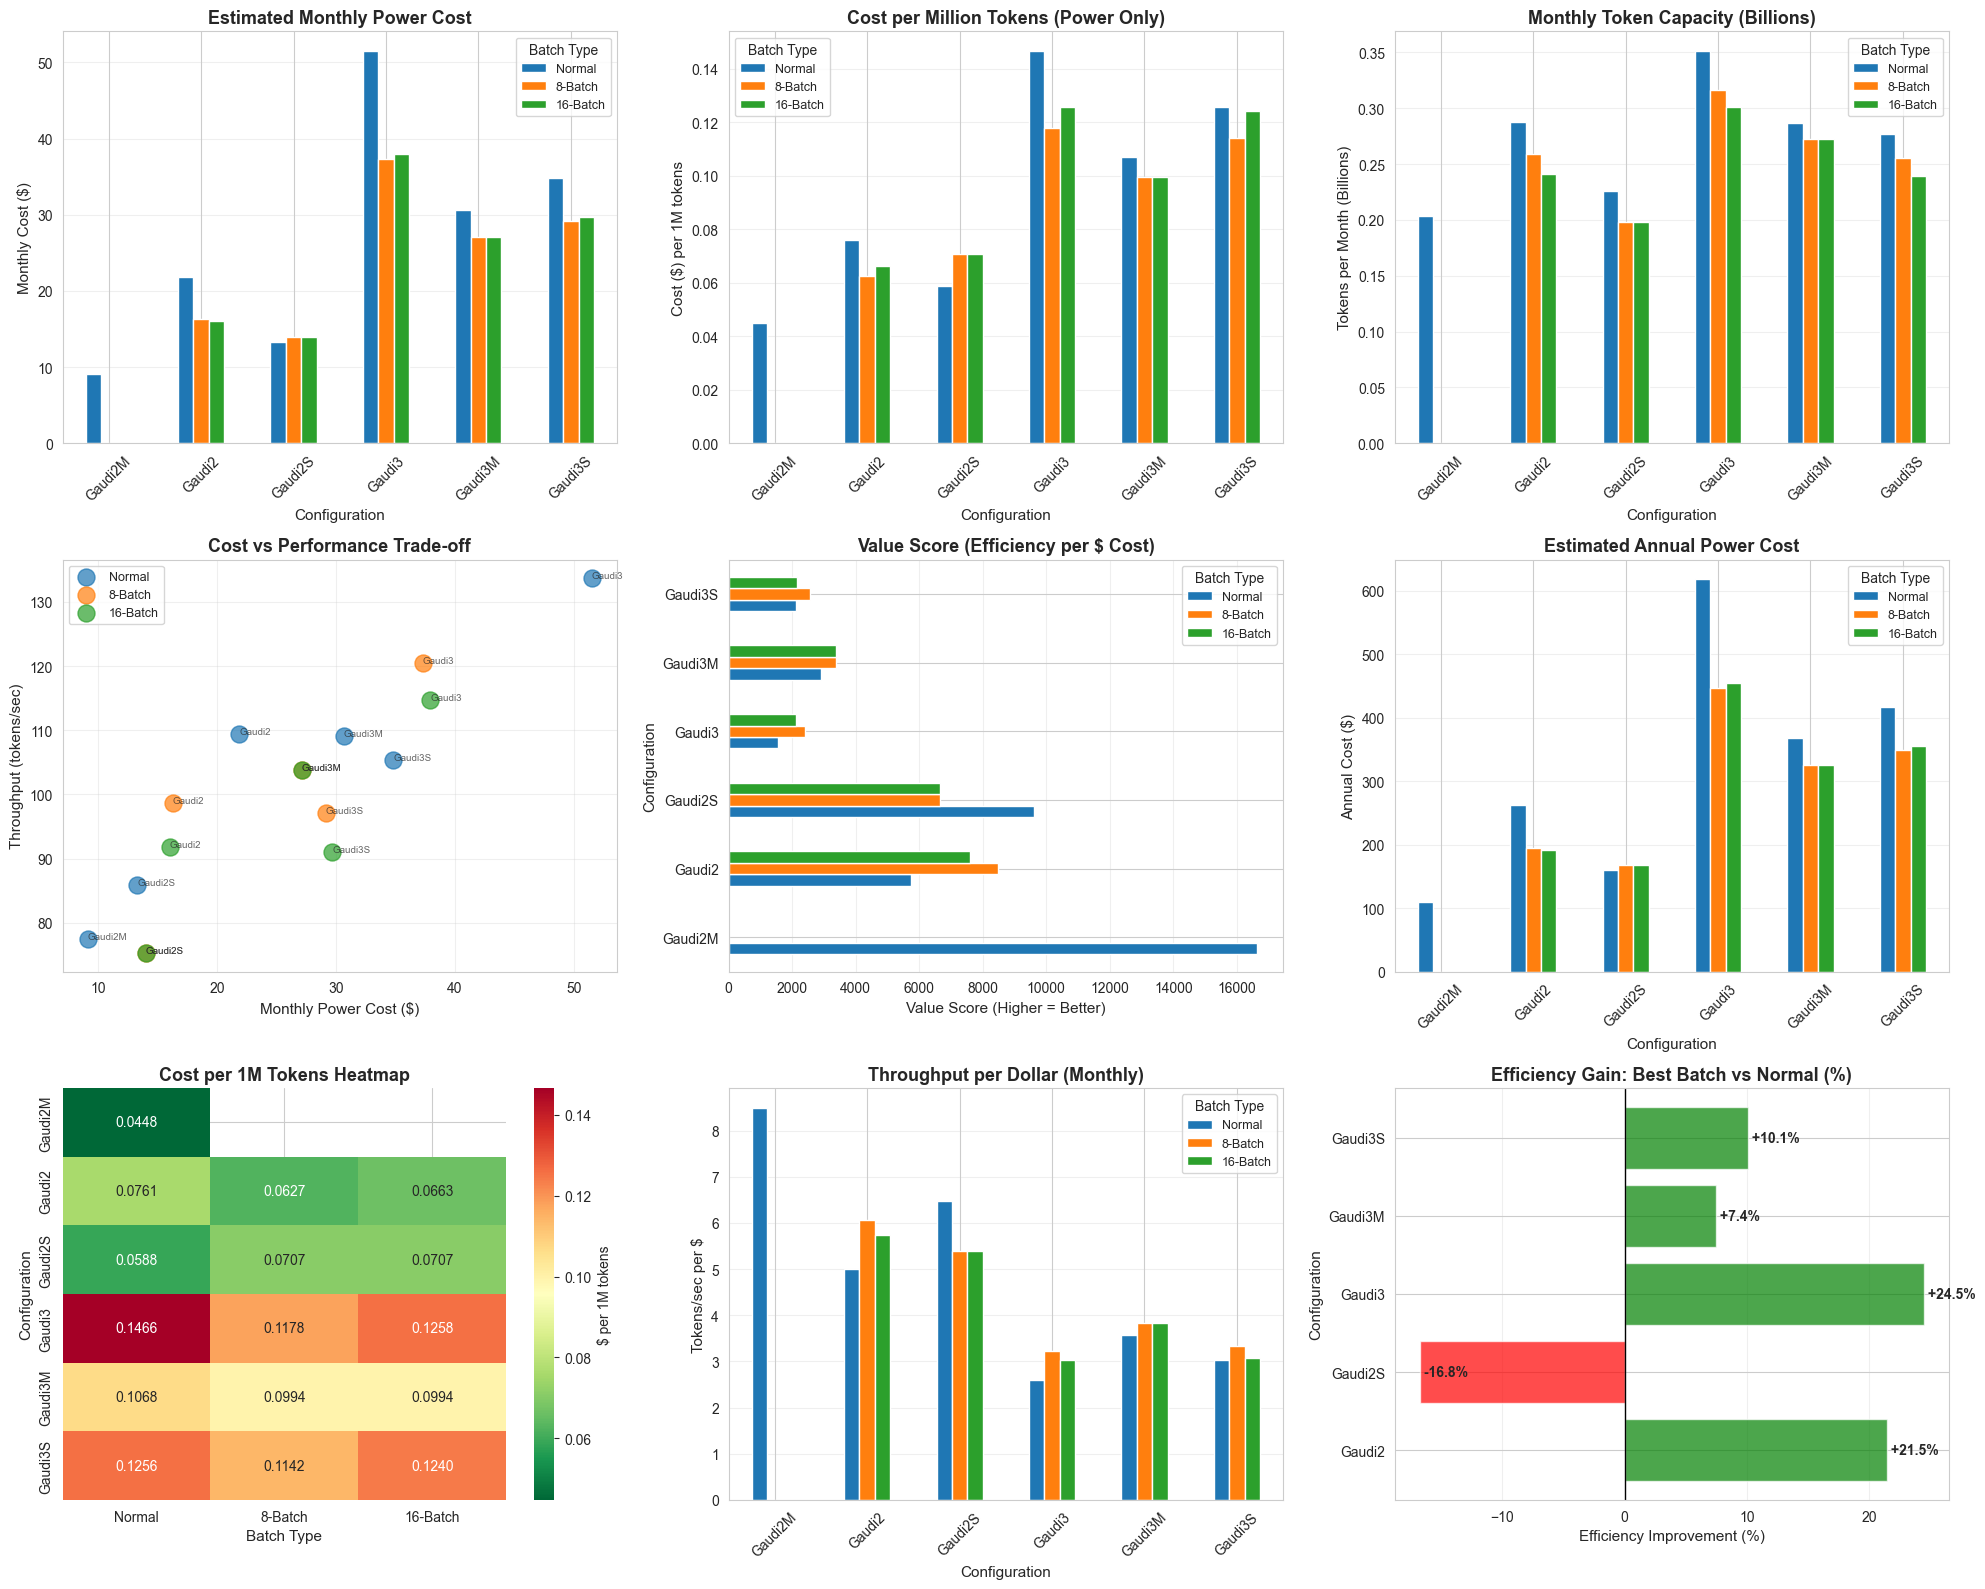


                                   COST-BENEFIT ANALYSIS

Assumptions:
  • Power cost: $0.12 per kWh
  • Operating hours: 730 hours/month

                                               Gaudi2                                               

  Normal:
    • Throughput: 109.37 tokens/sec
    • Power: 249.8W
    • Monthly power cost: $21.88
    • Annual power cost: $262.57
    • Tokens/month: 0.29 billion
    • Cost per 1M tokens: $0.0761
    • Efficiency: 0.438 tokens/watt

  8-Batch:
    • Throughput: 98.72 tokens/sec
    • Power: 185.6W
    • Monthly power cost: $16.26
    • Annual power cost: $195.07
    • Tokens/month: 0.26 billion
    • Cost per 1M tokens: $0.0627
    • Efficiency: 0.532 tokens/watt

  16-Batch:
    • Throughput: 91.88 tokens/sec
    • Power: 182.7W
    • Monthly power cost: $16.01
    • Annual power cost: $192.08
    • Tokens/month: 0.24 billion
    • Cost per 1M tokens: $0.0663
    • Efficiency: 0.503 tokens/watt

                                              Gau

In [270]:
if 'all_batches_df' in locals() and 'all_power_df' in locals():
    # Cost assumptions (adjust as needed)
    POWER_COST_PER_KWH = 0.12  # $/kWh
    HOURS_PER_MONTH = 730  # Average hours in a month
    
    # Calculate metrics
    cost_analysis = {}
    
    for config in all_batches_df['config'].unique():
        cost_analysis[config] = {}
        
        for batch_type in ['Normal', '8-Batch', '16-Batch']:
            if (batch_type in all_batches_df['batch_type'].values and 
                batch_type in all_power_df['batch_type'].values):
                
                # Performance metrics
                perf_data = all_batches_df[(all_batches_df['config'] == config) & 
                                          (all_batches_df['batch_type'] == batch_type)]
                power_data = all_power_df[(all_power_df['config'] == config) & 
                                         (all_power_df['batch_type'] == batch_type)]
                
                if len(perf_data) > 0 and len(power_data) > 0:
                    avg_throughput = perf_data['throughput'].mean()
                    avg_power = power_data['power_w'].mean()
                    
                    # Cost calculations
                    power_kwh = avg_power / 1000
                    monthly_power_cost = power_kwh * HOURS_PER_MONTH * POWER_COST_PER_KWH
                    tokens_per_month = avg_throughput * 3600 * HOURS_PER_MONTH  # tokens/month
                    cost_per_million_tokens = (monthly_power_cost / tokens_per_month) * 1_000_000
                    
                    cost_analysis[config][batch_type] = {
                        'throughput': avg_throughput,
                        'power_w': avg_power,
                        'monthly_cost': monthly_power_cost,
                        'tokens_per_month': tokens_per_month,
                        'cost_per_1M_tokens': cost_per_million_tokens,
                        'efficiency': avg_throughput / avg_power
                    }
    
    # Create visualizations
    fig, axes = plt.subplots(3, 3, figsize=(20, 16))
    
    # 1. Monthly power cost comparison
    ax1 = axes[0, 0]
    monthly_costs = pd.DataFrame({
        config: {batch: data['monthly_cost'] for batch, data in batches.items()}
        for config, batches in cost_analysis.items() if batches
    }).T
    monthly_costs.plot(kind='bar', ax=ax1)
    ax1.set_title('Estimated Monthly Power Cost', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Configuration', fontsize=11)
    ax1.set_ylabel('Monthly Cost ($)', fontsize=11)
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(title='Batch Type', fontsize=9)
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. Cost per million tokens
    ax2 = axes[0, 1]
    cost_per_1m = pd.DataFrame({
        config: {batch: data['cost_per_1M_tokens'] for batch, data in batches.items()}
        for config, batches in cost_analysis.items() if batches
    }).T
    cost_per_1m.plot(kind='bar', ax=ax2)
    ax2.set_title('Cost per Million Tokens (Power Only)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Configuration', fontsize=11)
    ax2.set_ylabel('Cost ($) per 1M tokens', fontsize=11)
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(title='Batch Type', fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Tokens per month (throughput capacity)
    ax3 = axes[0, 2]
    tokens_monthly = pd.DataFrame({
        config: {batch: data['tokens_per_month'] / 1e9 for batch, data in batches.items()}  # in billions
        for config, batches in cost_analysis.items() if batches
    }).T
    tokens_monthly.plot(kind='bar', ax=ax3)
    ax3.set_title('Monthly Token Capacity (Billions)', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Configuration', fontsize=11)
    ax3.set_ylabel('Tokens per Month (Billions)', fontsize=11)
    ax3.tick_params(axis='x', rotation=45)
    ax3.legend(title='Batch Type', fontsize=9)
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. ROI comparison (throughput vs cost)
    ax4 = axes[1, 0]
    for batch_type in ['Normal', '8-Batch', '16-Batch']:
        x_vals = []
        y_vals = []
        labels = []
        
        for config, batches in cost_analysis.items():
            if batch_type in batches:
                x_vals.append(batches[batch_type]['monthly_cost'])
                y_vals.append(batches[batch_type]['throughput'])
                labels.append(config)
        
        if x_vals:
            ax4.scatter(x_vals, y_vals, s=150, alpha=0.7, label=batch_type)
            for i, label in enumerate(labels):
                ax4.annotate(label, (x_vals[i], y_vals[i]), fontsize=7, alpha=0.7)
    
    ax4.set_title('Cost vs Performance Trade-off', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Monthly Power Cost ($)', fontsize=11)
    ax4.set_ylabel('Throughput (tokens/sec)', fontsize=11)
    ax4.legend(fontsize=9)
    ax4.grid(alpha=0.3)
    
    # 5. Best value (efficiency / cost)
    ax5 = axes[1, 1]
    value_scores = pd.DataFrame({
        config: {batch: (data['efficiency'] / data['cost_per_1M_tokens']) * 1000 
                for batch, data in batches.items()}
        for config, batches in cost_analysis.items() if batches
    }).T
    value_scores.plot(kind='barh', ax=ax5)
    ax5.set_title('Value Score (Efficiency per $ Cost)', fontsize=13, fontweight='bold')
    ax5.set_xlabel('Value Score (Higher = Better)', fontsize=11)
    ax5.set_ylabel('Configuration', fontsize=11)
    ax5.legend(title='Batch Type', fontsize=9)
    ax5.grid(axis='x', alpha=0.3)
    
    # 6. Annual cost projection
    ax6 = axes[1, 2]
    annual_costs = monthly_costs * 12
    annual_costs.plot(kind='bar', ax=ax6, stacked=False)
    ax6.set_title('Estimated Annual Power Cost', fontsize=13, fontweight='bold')
    ax6.set_xlabel('Configuration', fontsize=11)
    ax6.set_ylabel('Annual Cost ($)', fontsize=11)
    ax6.tick_params(axis='x', rotation=45)
    ax6.legend(title='Batch Type', fontsize=9)
    ax6.grid(axis='y', alpha=0.3)
    
    # 7. Cost breakdown heatmap
    ax7 = axes[2, 0]
    sns.heatmap(cost_per_1m, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=ax7, 
               cbar_kws={'label': '$ per 1M tokens'})
    ax7.set_title('Cost per 1M Tokens Heatmap', fontsize=13, fontweight='bold')
    ax7.set_xlabel('Batch Type', fontsize=11)
    ax7.set_ylabel('Configuration', fontsize=11)
    
    # 8. Throughput per dollar spent
    ax8 = axes[2, 1]
    throughput_per_dollar = pd.DataFrame({
        config: {batch: data['throughput'] / data['monthly_cost'] 
                for batch, data in batches.items()}
        for config, batches in cost_analysis.items() if batches
    }).T
    throughput_per_dollar.plot(kind='bar', ax=ax8)
    ax8.set_title('Throughput per Dollar (Monthly)', fontsize=13, fontweight='bold')
    ax8.set_xlabel('Configuration', fontsize=11)
    ax8.set_ylabel('Tokens/sec per $', fontsize=11)
    ax8.tick_params(axis='x', rotation=45)
    ax8.legend(title='Batch Type', fontsize=9)
    ax8.grid(axis='y', alpha=0.3)
    
    # 9. Comparison: Normal vs best batch size ROI
    ax9 = axes[2, 2]
    roi_comparison = {}
    
    for config, batches in cost_analysis.items():
        if 'Normal' in batches:
            normal_efficiency = batches['Normal']['efficiency']
            best_batch = max([b for b in batches if b != 'Normal'], 
                           key=lambda x: batches[x]['efficiency'], default=None)
            if best_batch:
                improvement = ((batches[best_batch]['efficiency'] - normal_efficiency) / 
                             normal_efficiency) * 100
                roi_comparison[config] = improvement
    
    if roi_comparison:
        configs = list(roi_comparison.keys())
        improvements = list(roi_comparison.values())
        colors = ['green' if x > 0 else 'red' for x in improvements]
        
        ax9.barh(configs, improvements, color=colors, alpha=0.7)
        ax9.set_title('Efficiency Gain: Best Batch vs Normal (%)', fontsize=13, fontweight='bold')
        ax9.set_xlabel('Efficiency Improvement (%)', fontsize=11)
        ax9.set_ylabel('Configuration', fontsize=11)
        ax9.axvline(x=0, color='black', linestyle='-', linewidth=1)
        ax9.grid(axis='x', alpha=0.3)
        
        for i, v in enumerate(improvements):
            ax9.text(v, i, f' {v:+.1f}%', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print cost analysis summary
    print("\n" + "="*100)
    print(" " * 35 + "COST-BENEFIT ANALYSIS")
    print("="*100)
    print(f"\nAssumptions:")
    print(f"  • Power cost: ${POWER_COST_PER_KWH:.2f} per kWh")
    print(f"  • Operating hours: {HOURS_PER_MONTH} hours/month")
    
    for config in sorted(cost_analysis.keys()):
        if cost_analysis[config]:
            print(f"\n{'='*100}")
            print(f"{config:^100}")
            print(f"{'='*100}")
            
            for batch_type in ['Normal', '8-Batch', '16-Batch']:
                if batch_type in cost_analysis[config]:
                    data = cost_analysis[config][batch_type]
                    print(f"\n  {batch_type}:")
                    print(f"    • Throughput: {data['throughput']:.2f} tokens/sec")
                    print(f"    • Power: {data['power_w']:.1f}W")
                    print(f"    • Monthly power cost: ${data['monthly_cost']:.2f}")
                    print(f"    • Annual power cost: ${data['monthly_cost'] * 12:.2f}")
                    print(f"    • Tokens/month: {data['tokens_per_month']/1e9:.2f} billion")
                    print(f"    • Cost per 1M tokens: ${data['cost_per_1M_tokens']:.4f}")
                    print(f"    • Efficiency: {data['efficiency']:.3f} tokens/watt")
    
    print(f"\n{'='*100}")
    print("RECOMMENDATIONS:")
    print(f"{'='*100}")
    
    # Find best configurations for different criteria
    best_cost_per_token = None
    best_cost_value = float('inf')
    
    best_monthly_throughput = None
    best_throughput_value = 0
    
    best_efficiency = None
    best_eff_value = 0
    
    for config, batches in cost_analysis.items():
        for batch_type, data in batches.items():
            if data['cost_per_1M_tokens'] < best_cost_value:
                best_cost_value = data['cost_per_1M_tokens']
                best_cost_per_token = f"{config} ({batch_type})"
            
            if data['tokens_per_month'] > best_throughput_value:
                best_throughput_value = data['tokens_per_month']
                best_monthly_throughput = f"{config} ({batch_type})"
            
            if data['efficiency'] > best_eff_value:
                best_eff_value = data['efficiency']
                best_efficiency = f"{config} ({batch_type})"
    
    print(f"\n💰 Best cost per token: {best_cost_per_token} (${best_cost_value:.4f} per 1M tokens)")
    print(f"🚀 Highest throughput: {best_monthly_throughput} ({best_throughput_value/1e9:.2f}B tokens/month)")
    print(f"⚡ Best efficiency: {best_efficiency} ({best_eff_value:.3f} tokens/watt)")